# Environment Setting

In [1597]:
#Baic Setting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from tqdm import tqdm
warnings.filterwarnings('ignore')

#Error Detection
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

#Dummy Variable Analysis
from sklearn.linear_model import LinearRegression
import seaborn as sns
import statsmodels.api as sm

#STL Decoposition
from statsmodels.tsa.seasonal import STL, seasonal_decompose

#ARIMA Model
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima.utils import ndiffs
from pmdarima import auto_arima
import pmdarima as pmd
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

#GARCH Model
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
from scipy.optimize import differential_evolution, NonlinearConstraint

#White Noise
from statsmodels.stats.diagnostic import acorr_ljungbox

#Rolling Forecasting
from datetime import timedelta

#VAR Model
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.api import VAR
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler

# Import Data

file:
/Users/lokheilee/Desktop/TSA/Gilead_Sciences_monthly.csv

/Users/lokheilee/Desktop/TSA/Illumina_Inc_monthly.csv

/Users/lokheilee/Desktop/TSA/Innoviva_Inc_monthly.csv

In [ ]:
CSV_file = '/Users/lokheilee/Desktop/TSA/Innoviva_Inc_monthly.csv'

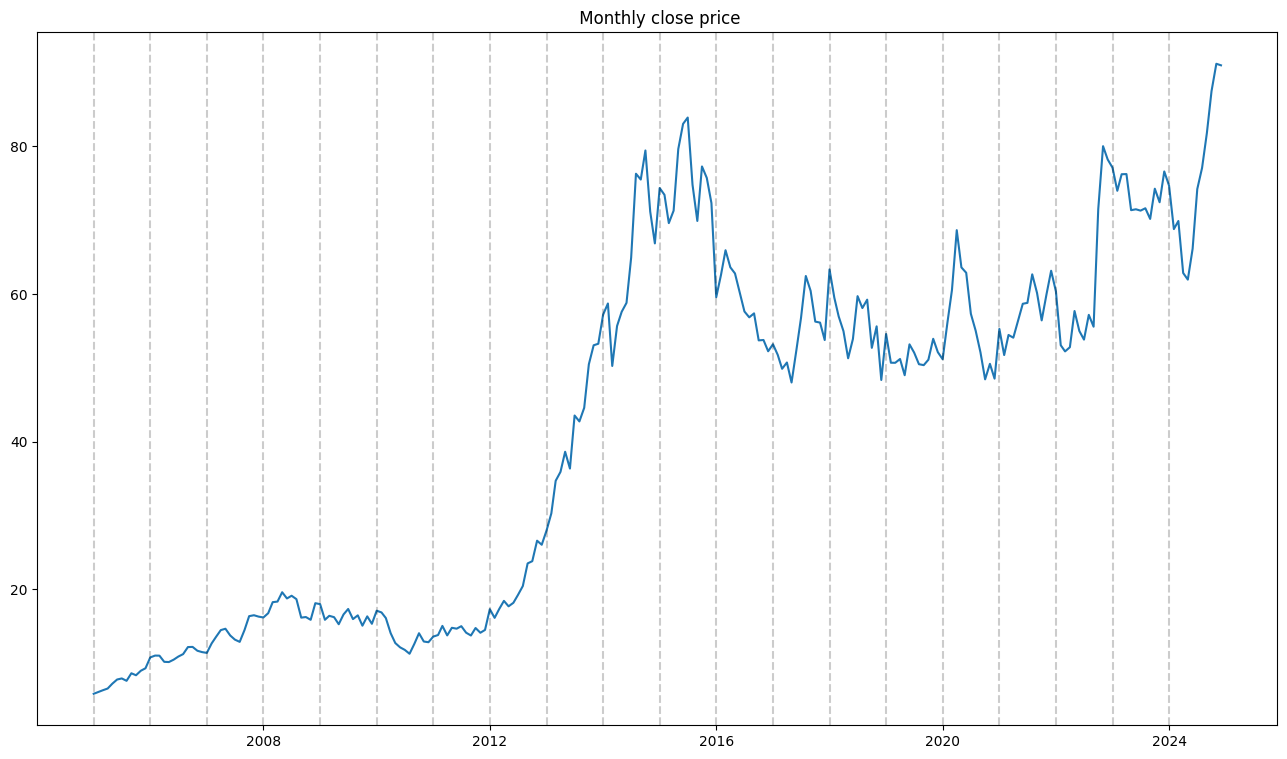

In [1599]:
def parser(s):
    return datetime.strptime(s, '%Y-%m-%d')

raw_df = pd.read_csv(CSV_file, parse_dates=[0], index_col=0, date_parser=parser)

#plot the data
plt.figure(figsize=(16, 9))
plt.plot(raw_df['Close'])
plt.title(' Monthly close price')
for year in range(2005, 2025):
    plt.axvline(datetime(year,1,1), color='k', linestyle='--', alpha=0.2)


# Train-Test Split

In [1600]:
#Split the data
train_end = datetime(2023, 12, 31)
test_end = datetime(2024, 12, 31)

# Assuming you want to predict 'Close' column
train_data = raw_df['Close'][:train_end]
test_data = raw_df['Close'][train_end + timedelta(days=1):test_end]
print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')

Train data shape: (228,)
Test data shape: (12,)


# DVR Model

## DVR Model

In [1601]:
# Data preparation
dummy_df = pd.read_csv(CSV_file)
dummy_df['Date'] = pd.to_datetime(dummy_df['Date'])
dummy_df = dummy_df.sort_values('Date')
dummy_df['Time_Period'] = range(1, len(dummy_df) + 1)
dummy_df['Close'] = pd.to_numeric(dummy_df['Close'], errors='coerce')
dummy_df = dummy_df.dropna()

# Create monthly dummy variables - ensure they're numeric
dummy_df['Month'] = dummy_df['Date'].dt.month
dummy_months = pd.get_dummies(dummy_df['Month'], prefix='Month').astype(float)

# Combine features and ensure numeric types
X = pd.concat([dummy_df[['Time_Period']].astype(float), dummy_months.iloc[:, :-1]], axis=1)
y = dummy_df['Close'].astype(float)

# Add constant term
X = sm.add_constant(X)

# Train/test split
train_mask = dummy_df['Date'] <= '2023-12-31'
test_mask = (dummy_df['Date'] > '2023-12-31') & (dummy_df['Date'] <= '2024-12-31')

# Convert to numpy arrays explicitly
X_train = X[train_mask].values.astype(float)
X_test = X[test_mask].values.astype(float)
y_train = y[train_mask].values.astype(float)
y_test = y[test_mask].values.astype(float)

# Model fitting
try:
    model = sm.OLS(y_train, X_train).fit()
except Exception as e:
    print("Error in model fitting:", e)
    # Debugging info
    print("X_train dtype:", X_train.dtype)
    print("y_train dtype:", y_train.dtype)
    print("NaN in X_train:", np.isnan(X_train).sum())
    print("NaN in y_train:", np.isnan(y_train).sum())
    raise

print(model.summary())

# Print the equation
print("\nRegression Equation:")
print("Close = ", end="")
print(f"{model.params[0]:.4f}", end="")
print(f" + {model.params[1]:.4f}*Time_Period", end="")
for i in range(2, len(model.params)):
    print(f" + {model.params[i]:.4f}*Month_{i-1}", end="")
print()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     48.44
Date:                Tue, 01 Apr 2025   Prob (F-statistic):           2.17e-54
Time:                        23:36:37   Log-Likelihood:                -895.94
No. Observations:                 228   AIC:                             1818.
Df Residuals:                     215   BIC:                             1862.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6550      3.288      1.416      0.1

In [1602]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     48.44
Date:                Tue, 01 Apr 2025   Prob (F-statistic):           2.17e-54
Time:                        23:36:37   Log-Likelihood:                -895.94
No. Observations:                 228   AIC:                             1818.
Df Residuals:                     215   BIC:                             1862.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6550      3.288      1.416      0.158      -1.826      11.136
x1             0.3074      0.013     24.065      0.000       0.282       0.333
x2             1.0115      4.116      0.246      0.806      -7.101       9.124
x3             0.0141      4.116      0.003      0.997      -8.098       8.126
x4            -0.0674      4.115     -0.016      0.987      -8.179       8.044
x5             0.2408      4.115      0.059      0.953      -7.870       8.352
x6            -0.0208      4.115     -0.005      0.996      -8.131       8.089
x7             0.2052      4.114      0.050      0.960      -7.904       8.315
x8             0.7462      4.114      0.181      0.856      -7.363       8.855
x9             0.7576      4.114      0.184      0.854      -7.351       8.866
x10            0.0710      4.114      0.017      0.986      -8.038       8.180
x11            0.7793      4.114      0.189      0.850      -7.329       8.888
x12            1.1468      4.114      0.279      0.781      -6.962       9.255
==============================================================================
Omnibus:                       48.619   Durbin-Watson:                   0.070
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               75.103
Skew:                           1.222   Prob(JB):                     4.92e-17
Kurtosis:                       4.391   Cond. No.                     1.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## DVR Model Forecasting

Train MAPE: 27.19%
Test MAPE: 10.68%
Whole Data MAPE: 26.37%


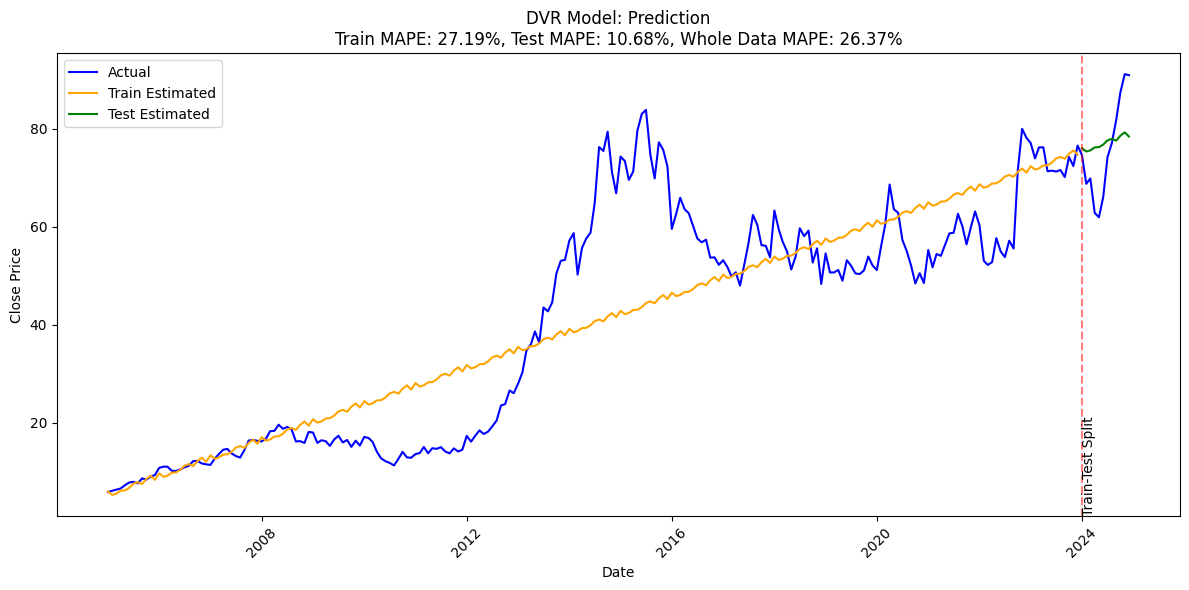

In [1603]:
# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
all_pred = model.predict(X.values.astype(float))
dva_residuals = y - all_pred

# MAPE calculations
train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100
whole_mape = mean_absolute_percentage_error(y, all_pred) * 100

dva_train_mape = train_mape
dva_test_mape = test_mape
dva_whole_mape = whole_mape

print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Whole Data MAPE: {whole_mape:.2f}%")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dummy_df['Date'], y, label='Actual', color='blue')
plt.plot(dummy_df['Date'][train_mask], train_pred, label='Train Estimated', color='orange')
plt.plot(dummy_df['Date'][test_mask], test_pred, label='Test Estimated', color='green')
# Add vertical line to separate train and test
plt.axvline(x=datetime(2023, 12, 31), color='red', linestyle='--', alpha=0.5)
plt.text(datetime(2023, 12, 31), plt.ylim()[0], 'Train-Test Split', rotation=90, verticalalignment='bottom')
plt.title(
    f'DVR Model: Prediction\n'
    f'Train MAPE: {train_mape:.2f}%, '
    f'Test MAPE: {test_mape:.2f}%, '
    f'Whole Data MAPE: {whole_mape:.2f}%'
)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## DVR model Residual Analysis

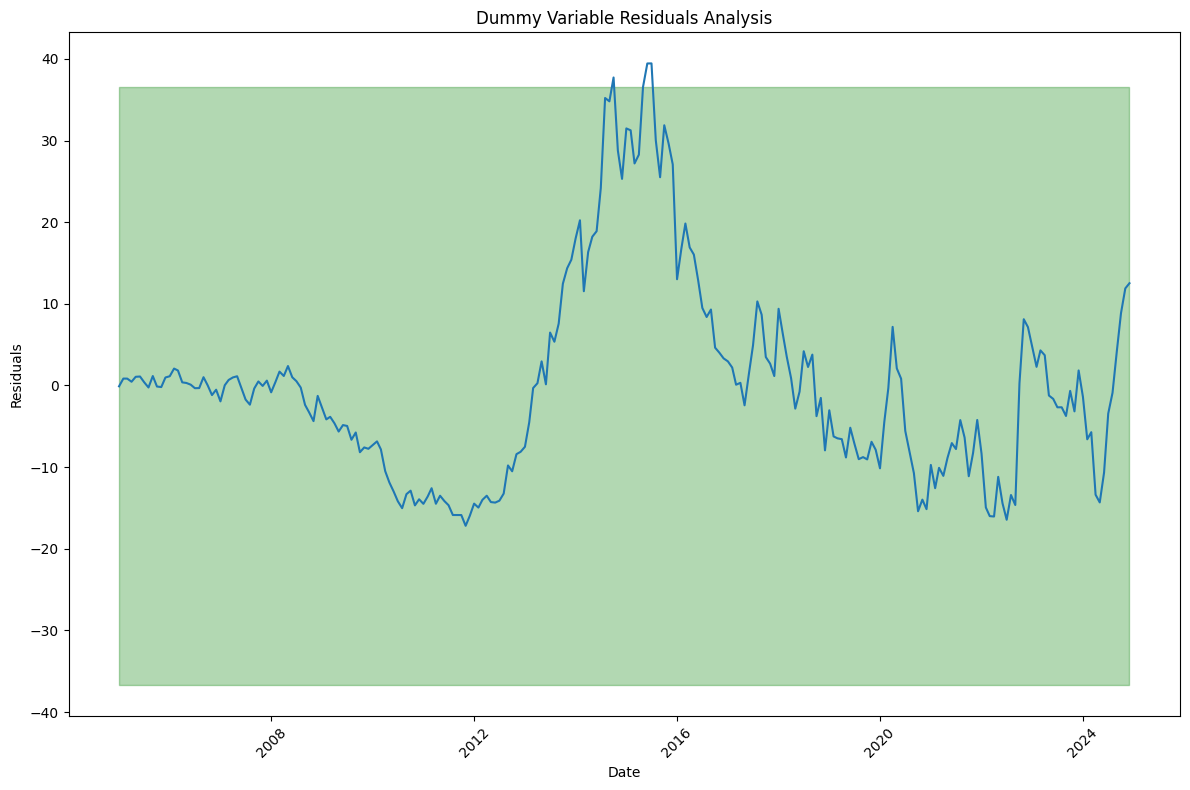

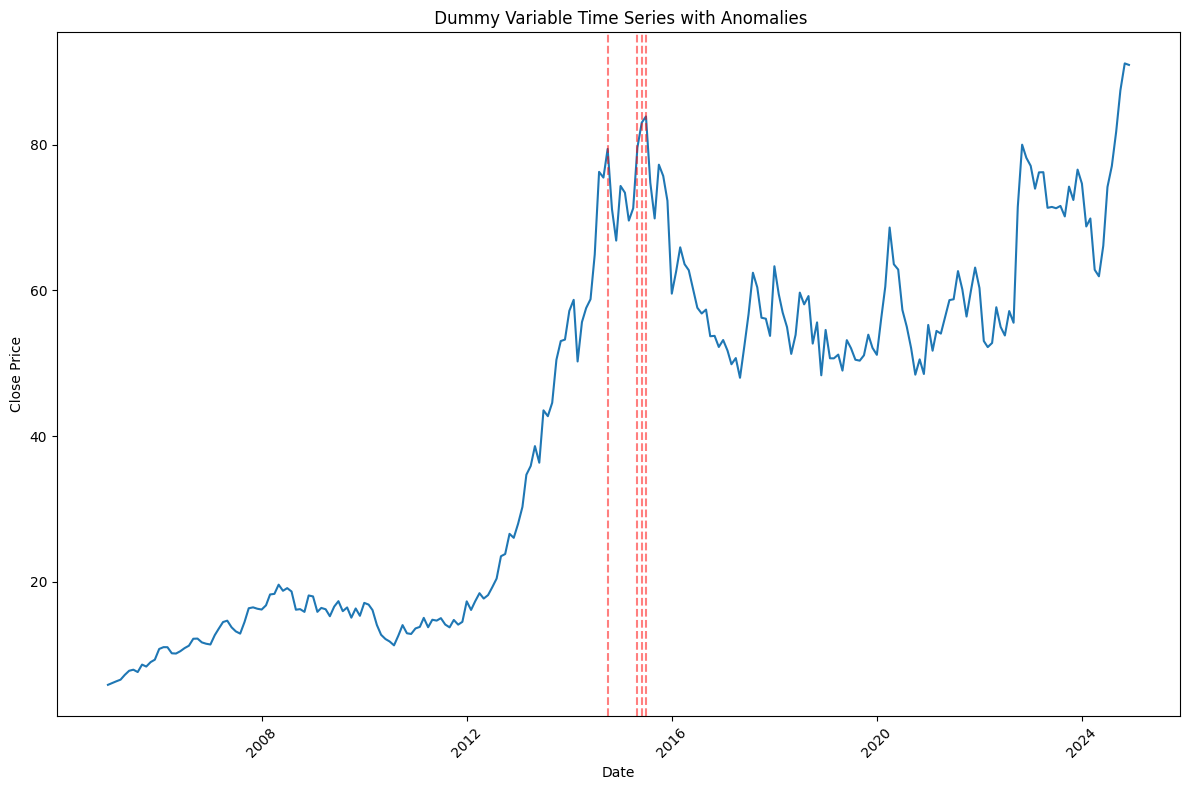


Dates of Anomalies:
['2014-10-01', '2015-05-01', '2015-06-01', '2015-07-01']


In [1604]:
#Anormal Detection
# Residual Analysis
res = pd.DataFrame({
    'date': dummy_df['Date'],
    'resid': dva_residuals
})
res.set_index('date', inplace=True)

# Calculate statistics
res.resid_mean = res.resid.mean()
res.resid_std = res.resid.std()
lower_bound = res.resid_mean - 3 * res.resid_std
upper_bound = res.resid_mean + 3 * res.resid_std

# Plot the residuals with dates
plt.figure(figsize=(12, 8))
plt.plot(res.index, res.resid)
plt.fill_between(res.index, lower_bound, upper_bound, color='green', alpha=0.3)
plt.title('Dummy Variable Residuals Analysis')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Anomaly Detection
anomalies = res.resid[(res.resid < lower_bound) | (res.resid > upper_bound)]
plt.figure(figsize=(12, 8))
plt.plot(dummy_df['Date'], dummy_df['Close'])
for date in anomalies.index:
    plt.axvline(date, color='r', linestyle='--', alpha=0.5)
plt.title(' Dummy Variable Time Series with Anomalies')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nDates of Anomalies:')
print(anomalies.index.strftime('%Y-%m-%d').tolist())

In [1605]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(dva_residuals)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 203.0049
LM test p-value: 3.8108686171209457e-38

ARCH LM Test Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests there is ARCH effect present in the residuals.


In [1606]:
#Write Noice
white_noise_dva = acorr_ljungbox(dva_residuals, lags = [12], return_df=True)
white_noise_dva

# Print the p-value from the Ljung-Box test
print(f"Ljung-Box test p-value: {white_noise_dva['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_dva['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")



Ljung-Box test p-value: 0.0

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


## DVR GARCH Model

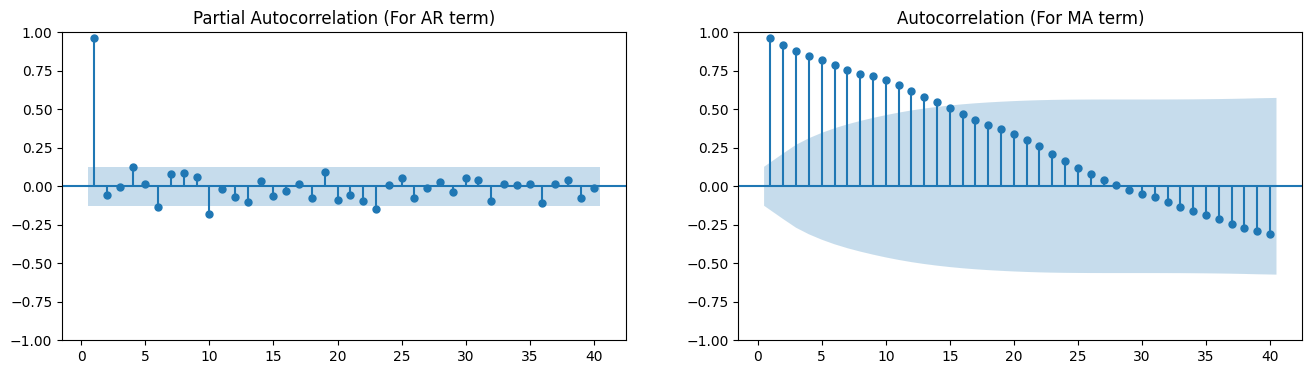

Iteration:      1,   Func. Count:      5,   Neg. LLF: 861.533228311712
Iteration:      2,   Func. Count:     10,   Neg. LLF: 955.9703668653508
Iteration:      3,   Func. Count:     15,   Neg. LLF: 842.0419041770754
Iteration:      4,   Func. Count:     19,   Neg. LLF: 837.5911884916759
Iteration:      5,   Func. Count:     23,   Neg. LLF: 6516.317462924941
Iteration:      6,   Func. Count:     28,   Neg. LLF: 40425.70218491497
Iteration:      7,   Func. Count:     33,   Neg. LLF: 14917.354367541553
Iteration:      8,   Func. Count:     38,   Neg. LLF: 34467.70072857063
Iteration:      9,   Func. Count:     43,   Neg. LLF: 2771.7617334569472
Iteration:     10,   Func. Count:     48,   Neg. LLF: 2329.0254039065685
Iteration:     11,   Func. Count:     53,   Neg. LLF: 2565.118641938374
Iteration:     12,   Func. Count:     58,   Neg. LLF: 44454.87869654551
Iteration:     13,   Func. Count:     63,   Neg. LLF: 17311.742197635933
Iteration:     14,   Func. Count:     68,   Neg. LLF: 21177.8

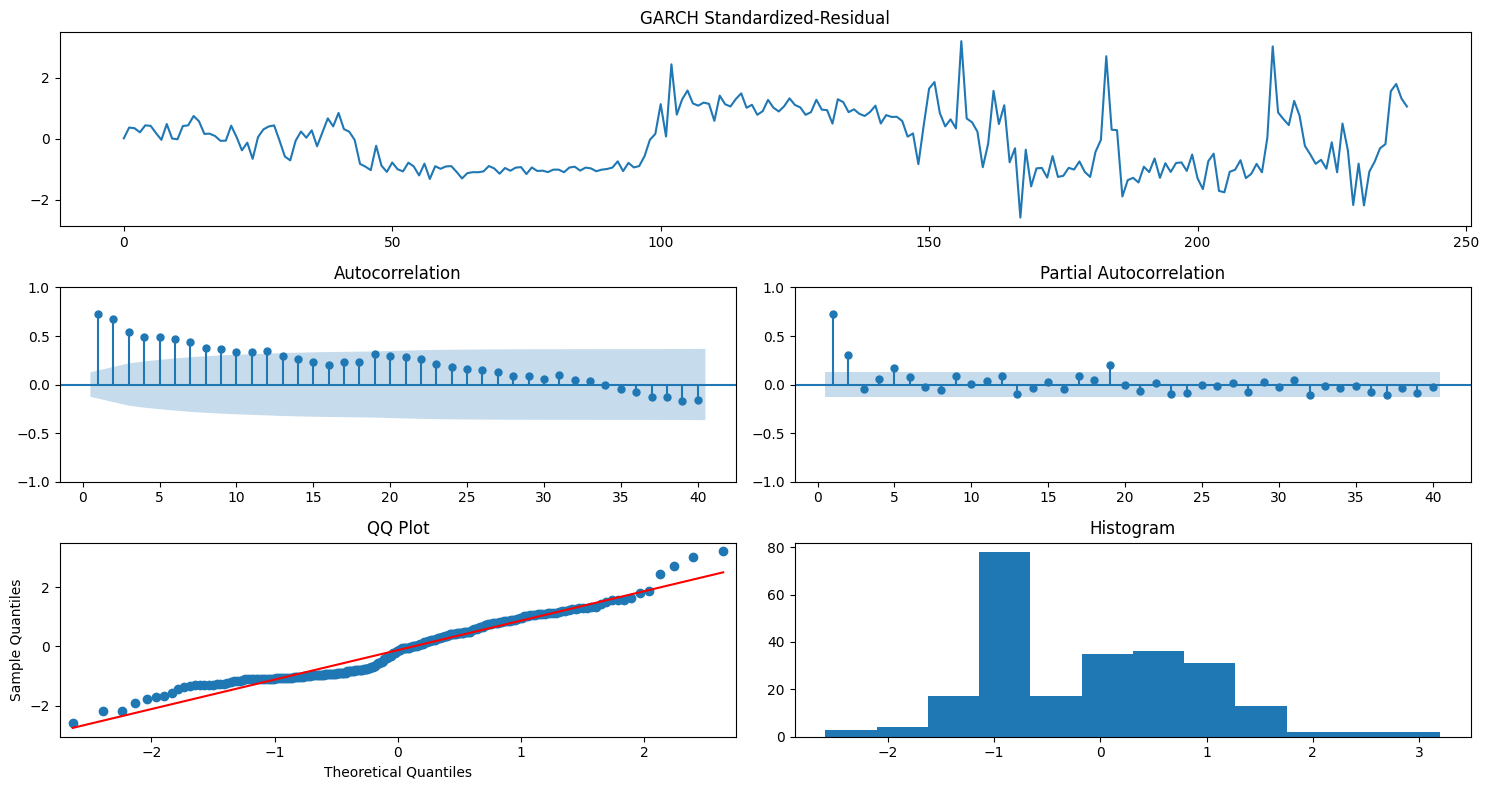

In [ ]:
#GARCH Model
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(dva_residuals, lags=40, zero=False, ax=ax2, title='Autocorrelation (For MA term)')
plot_pacf(dva_residuals, lags=40, zero=False, ax=ax1, title = 'Partial Autocorrelation (For AR term)')
plt.show()

dva_garch = arch_model(dva_residuals, vol = 'GARCH', p = 1, q = 1)
dva_garch_fit = dva_garch.fit()
print(dva_garch_fit.summary())

garch_std_resid = pd.Series(dva_garch_fit.resid / dva_garch_fit.conditional_volatility)
fig = plt.figure(figsize = (15, 8))

# Residual
garch_std_resid.plot(ax = fig.add_subplot(3,1,1), title = 'GARCH Standardized-Residual', legend = False)

# ACF/PACF
sgt.plot_acf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,3))
sgt.plot_pacf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,4))

# QQ-Plot & Norm-Dist
sm.qqplot(garch_std_resid, line='s', ax=fig.add_subplot(3,2,5)) 
plt.title("QQ Plot")
fig.add_subplot(3,2,6).hist(garch_std_resid, bins = 12)
plt.title("Histogram")

plt.tight_layout()
plt.show()

In [1608]:
dva_garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -807.184
Distribution:                  Normal   AIC:                           1620.37
Method:            Maximum Likelihood   BIC:                           1630.81
                                        No. Observations:                  240
Date:                Tue, Apr 01 2025   Df Residuals:                      239
Time:                        23:36:39   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.1479      0.711     -0.208      0.835 [ -1.541,  1.246]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          7.2930      2.205      3.308  9.405e-04 [  2.972, 11.614]
alpha[1]       0.9425  6.314e-02     14.927  2.206e-50 [  0.819,  1.066]
========================================================================

Covariance estimator: robust
"""

In [1609]:
# Detect GARCH model order
p = len([param for param in dva_garch_fit.params.index if 'alpha' in param])
q = len([param for param in dva_garch_fit.params.index if 'beta' in param])

print(f"Detected GARCH({p},{q}) model")

# Print all parameters
print("\nModel Parameters:")
for param_name, value in dva_garch_fit.params.items():
    print(f"{param_name}: {value:.6f}")

# Construct equation based on model order
equation = f"σ²(t) = {dva_garch_fit.params['omega']:.6f}"

# Add ARCH terms (alpha)
for i in range(1, p+1):
    alpha = dva_garch_fit.params[f'alpha[{i}]']
    equation += f" + {alpha:.6f}*ε²(t-{i})"

# Add GARCH terms (beta)
for i in range(1, q+1):
    beta = dva_garch_fit.params[f'beta[{i}]']
    equation += f" + {beta:.6f}*σ²(t-{i})"

print("\nGARCH Equation:")
print(equation)

print("\nwhere:")
print("σ²(t)   = conditional variance at time t")
print("ε²(t-i) = squared error term at lag i")
print("σ²(t-i) = conditional variance at lag i")

Detected GARCH(1,0) model

Model Parameters:
mu: -0.147924
omega: 7.292961
alpha[1]: 0.942520

GARCH Equation:
σ²(t) = 7.292961 + 0.942520*ε²(t-1)

where:
σ²(t)   = conditional variance at time t
ε²(t-i) = squared error term at lag i
σ²(t-i) = conditional variance at lag i


In [1610]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(garch_std_resid)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 11.4522
LM test p-value: 0.3233891942952742

ARCH LM Test Interpretation:
Since p-value > 0.05, we fail to reject the null hypothesis.
This suggests there is no ARCH effect in the residuals.



Method Comparison Results:
                Method  Point Weight  Upper Weight  Lower Weight      MAPE
Differential Evolution      0.331005      0.099796      0.569199 20.366780
         Random Search      0.474289      0.028553      0.497158 20.367277
           Grid Search      0.300000      0.100000      0.600000 20.608081

Best Combination:
Method: Differential Evolution
Weights: Point=0.331, Upper=0.100, Lower=0.569
MAPE: 20.37%


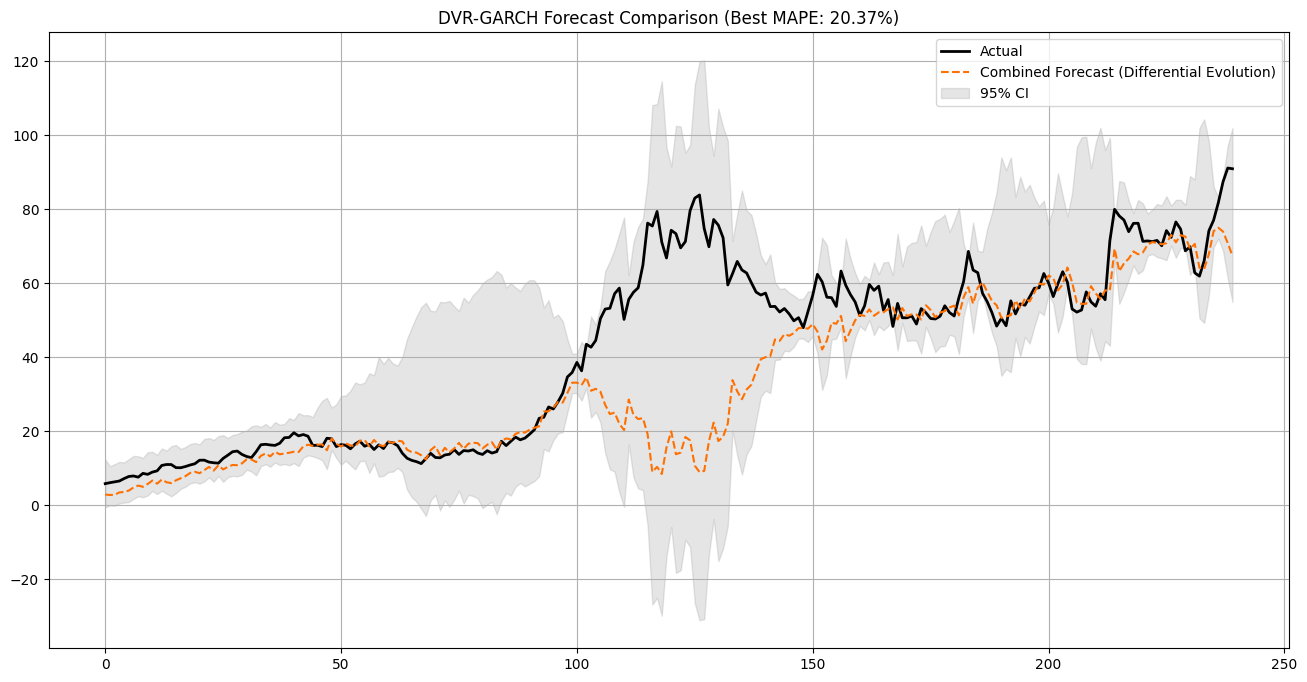

In [1611]:
# 1. Prepare volatility-adjusted forecasts
volatility = dva_garch_fit.conditional_volatility
dummy_point = all_pred
upper_bound = dummy_point + 1.96 * volatility
lower_bound = dummy_point - 1.96 * volatility

# 2. Create forecast DataFrame
forecasts = pd.DataFrame({
    'Point': dummy_point,
    'Upper': upper_bound,
    'Lower': lower_bound,
    'Actual': dummy_df['Close'].dropna()
}).dropna()

# 3. Define multiple optimization methods
def grid_search_weights(forecasts, precision=0.1):
    best_mape = float('inf')
    best_weights = None
    for w1 in np.arange(0, 1+precision, precision):
        for w2 in np.arange(0, 1-w1+precision, precision):
            w3 = 1 - w1 - w2
            combined = w1*forecasts['Point'] + w2*forecasts['Upper'] + w3*forecasts['Lower']
            current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
            if current_mape < best_mape:
                best_mape = current_mape
                best_weights = (w1, w2, w3)
    return best_weights, best_mape

def random_search_weights(forecasts, iterations=1000):
    best_mape = float('inf')
    best_weights = None
    for _ in range(iterations):
        weights = np.random.dirichlet(np.ones(3))
        combined = weights[0]*forecasts['Point'] + weights[1]*forecasts['Upper'] + weights[2]*forecasts['Lower']
        current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
        if current_mape < best_mape:
            best_mape = current_mape
            best_weights = weights
    return best_weights, best_mape

def diff_evolution_weights(forecasts):
    X = forecasts[['Point', 'Upper', 'Lower']].values
    y = forecasts['Actual'].values
    
    def mape_objective(weights):
        return np.mean(np.abs((y - X@weights)/y))*100
    
    constraints = NonlinearConstraint(lambda w: np.sum(w), 1, 1)
    bounds = [(0,1)]*3
    
    result = differential_evolution(
        mape_objective,
        bounds,
        constraints=constraints,
        popsize=15,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42,
        tol=0.001
    )
    return result.x, result.fun

# 4. Run all optimization methods
methods = {
    'Grid Search': grid_search_weights(forecasts),
    'Random Search': random_search_weights(forecasts),
    'Differential Evolution': diff_evolution_weights(forecasts)
}

# 5. Compare results
print("\nMethod Comparison Results:")
print("="*40)
results_df = pd.DataFrame([
    {
        'Method': method,
        'Point Weight': weights[0],
        'Upper Weight': weights[1], 
        'Lower Weight': weights[2],
        'MAPE': mape
    }
    for method, (weights, mape) in methods.items()
]).sort_values('MAPE')

print(results_df.to_string(index=False))

# 6. Select best method
best_method = results_df.iloc[0]['Method']
best_weights, best_mape = methods[best_method]
multi_y_pred = (best_weights[0]*forecasts['Point'] + 
               best_weights[1]*forecasts['Upper'] + 
               best_weights[2]*forecasts['Lower'])

# 7. Enhanced visualization
plt.figure(figsize=(16,8))

# Plot actual vs combined forecast
plt.plot(forecasts['Actual'], label='Actual', color='k', linewidth=2)
plt.plot(multi_y_pred, label=f'Combined Forecast ({best_method})', linestyle='--', color='#FF7000')
plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                color='gray', alpha=0.2, label='95% CI')
plt.title(f"DVR-GARCH Forecast Comparison (Best MAPE: {best_mape:.2f}%)")
plt.legend()
plt.grid(True)

# 8. Final output
print("\nBest Combination:")
print(f"Method: {best_method}")
print(f"Weights: Point={best_weights[0]:.3f}, Upper={best_weights[1]:.3f}, Lower={best_weights[2]:.3f}")
print(f"MAPE: {best_mape:.2f}%")


Combined model improves MAPE by 6.00% points
Using MSTL-GARCH combined forecast

Model Comparison:
              Model      MAPE Improvement
          Pure MSTL 26.367482           -
MSTL-GARCH Combined 20.366780       6.00%


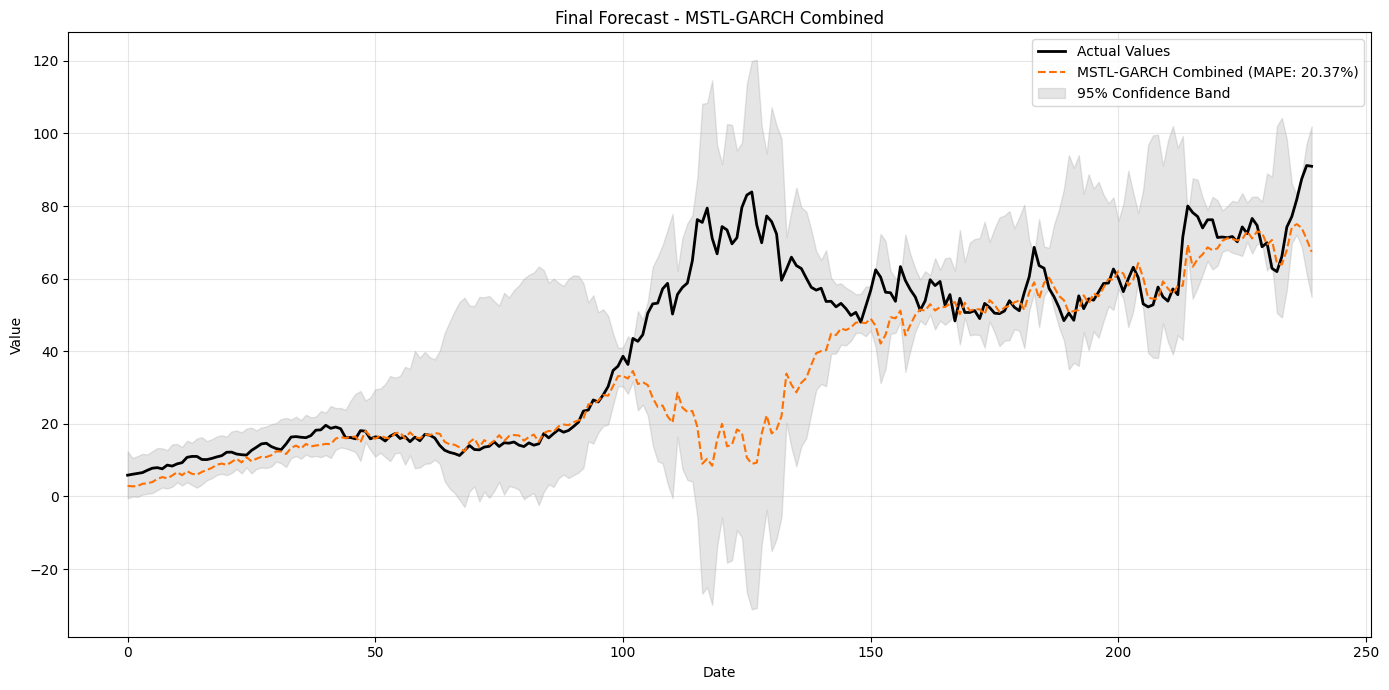


Best forecast stored in df_stl['final_forecast']


In [1612]:
# 1. Calculate pure MSTL performance
dummy_only_mape = np.mean(np.abs((forecasts['Actual'] - forecasts['Point'])/forecasts['Actual'])) * 100

# 2. Compare with combined model
if best_mape < dummy_only_mape:
    print(f"\nCombined model improves MAPE by {dummy_only_mape-best_mape:.2f}% points")
    print("Using MSTL-GARCH combined forecast")
    dummy_y_pred = (best_weights[0]*forecasts['Point'] + 
                   best_weights[1]*forecasts['Upper'] + 
                   best_weights[2]*forecasts['Lower'])
    best_model_name = "MSTL-GARCH Combined"
else:
    print("\nPure MSTL performs better than combined model")
    print("Using pure MSTL forecast")
    dummy_y_pred = forecasts['Point']
    best_model_name = "Pure MSTL"
    best_mape = dummy_only_mape

# 3. Final comparison table
comparison = pd.DataFrame({
    'Model': ['Pure MSTL', 'MSTL-GARCH Combined'],
    'MAPE': [dummy_only_mape, best_mape],
    'Improvement': ['-', f"{dummy_only_mape-best_mape:.2f}%"]
})
print("\nModel Comparison:")
print(comparison.to_string(index=False))

# 4. Final visualization
plt.figure(figsize=(14,7))
plt.plot(forecasts['Actual'], label='Actual Values', color='black', linewidth=2)
plt.plot(dummy_y_pred, label=f'{best_model_name} (MAPE: {best_mape:.2f}%)', 
         color='#FF7000', linestyle='--')

if best_model_name == "MSTL-GARCH Combined":
    plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                    color='gray', alpha=0.2, label='95% Confidence Band')

plt.title(f"Final Forecast - {best_model_name}")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Store final forecast
dummy_df['final_forecast'] = dummy_y_pred
print("\nBest forecast stored in df_stl['final_forecast']")

In [1613]:
# Print Write Noice
white_noise_add = acorr_ljungbox(garch_std_resid, lags = [12], return_df=True)
white_noise_add

# Print the p-value from the Ljung-Box test
print(f"Ljung-Box test p-value: {white_noise_add['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_add['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")

Ljung-Box test p-value: 1.6480211626536603e-139

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


# Additive STL Model

## Additive STL Model

Text(0, 0.5, 'Residual')

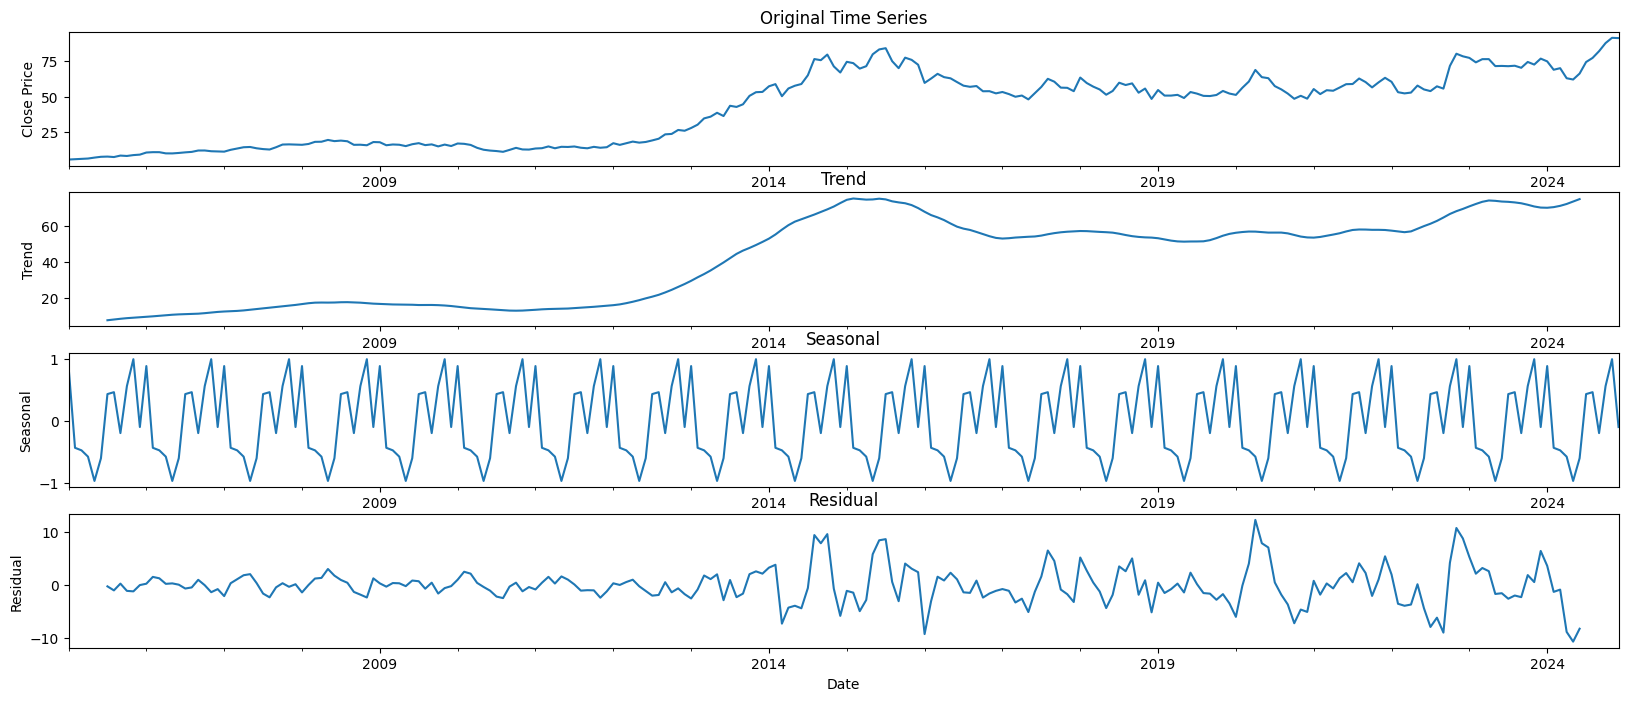

In [1614]:
# Data preparation
df_stl = pd.read_csv(CSV_file, usecols=['Date', 'Close'])
df_stl = df_stl.dropna()
df_stl['Date'] = pd.to_datetime(df_stl['Date'])
df_stl.set_index('Date', inplace=True)

# Assuming you want to predict 'Close' column - adjust column name as needed
train_data = df_stl['Close'][:train_end]
test_data = df_stl['Close'][train_end + timedelta(days=1):test_end]

seasonal_decomp_add = seasonal_decompose(df_stl, model='additive', period=12)
df_stl['trend_add'] = seasonal_decomp_add.trend
df_stl['seasonal_add'] = seasonal_decomp_add.seasonal
df_stl['residual_add'] = seasonal_decomp_add.resid

#plot graph
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 8))

# Plot original data
df_stl['Close'].plot(ax=ax1)
ax1.set_title('Original Time Series')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')

# Plot trend
seasonal_decomp_add.trend.plot(ax=ax2)
ax2.set_title('Trend')
ax2.set_xlabel('Date')
ax2.set_ylabel('Trend')

# Plot seasonal
seasonal_decomp_add.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
ax3.set_xlabel('Date')
ax3.set_ylabel('Seasonal')

# Plot residual
seasonal_decomp_add.resid.plot(ax=ax4)
ax4.set_title('Residual')
ax4.set_xlabel('Date')
ax4.set_ylabel('Residual')

## Additive STL Model Forecast

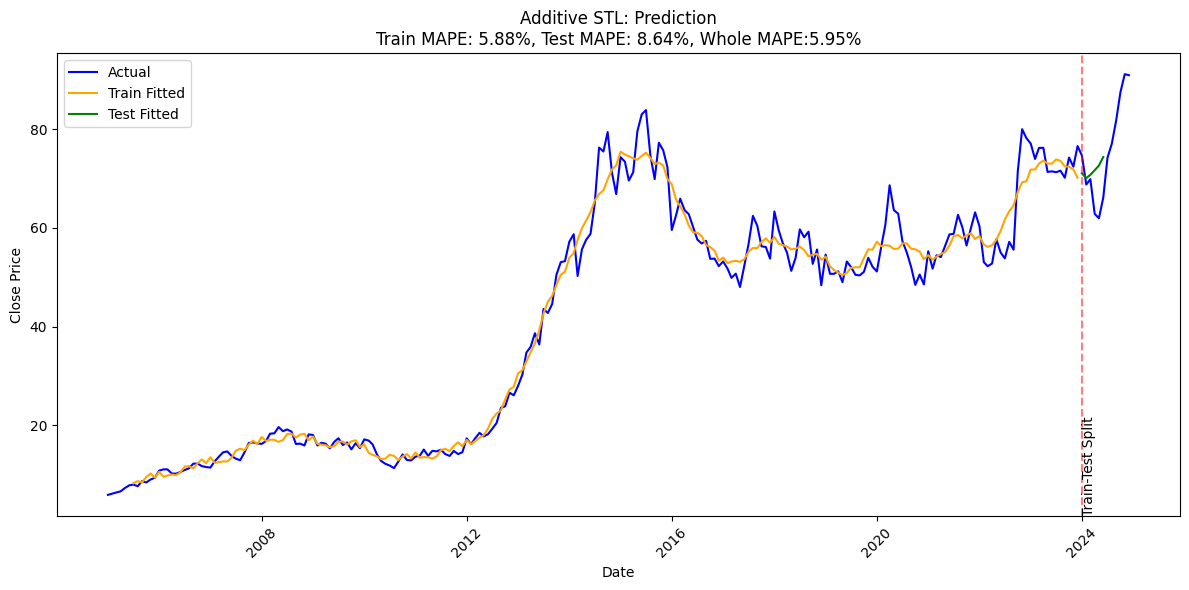

In [1615]:
# Calculate fitted values (predictions)
df_stl['add_fitted'] = df_stl['trend_add'] + df_stl['seasonal_add']

# Create train and test masks
train_mask = df_stl.index <= train_end
test_mask = (df_stl.index > train_end) & (df_stl.index <= test_end)

# Calculate MAPE for train and test sets
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

train_mape = calculate_mape(df_stl.loc[train_mask, 'Close'], df_stl.loc[train_mask, 'add_fitted'])
test_mape = calculate_mape(df_stl.loc[test_mask, 'Close'], df_stl.loc[test_mask, 'add_fitted'])
whole_mape = calculate_mape(df_stl['Close'], df_stl['add_fitted'])

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_stl['Close'], label='Actual', color='blue')
plt.plot(df_stl.loc[train_mask, 'add_fitted'], label='Train Fitted', color='orange')
plt.plot(df_stl.loc[test_mask, 'add_fitted'], label='Test Fitted', color='green')
plt.axvline(x=train_end, color='red', linestyle='--', alpha=0.5)
plt.text(train_end, plt.ylim()[0], 'Train-Test Split', rotation=90, verticalalignment='bottom')
plt.title(
    f'Additive STL: Prediction\n'
    f'Train MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%, Whole MAPE:{whole_mape:.2f}%'
)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Additive STL Model Residual Analysis

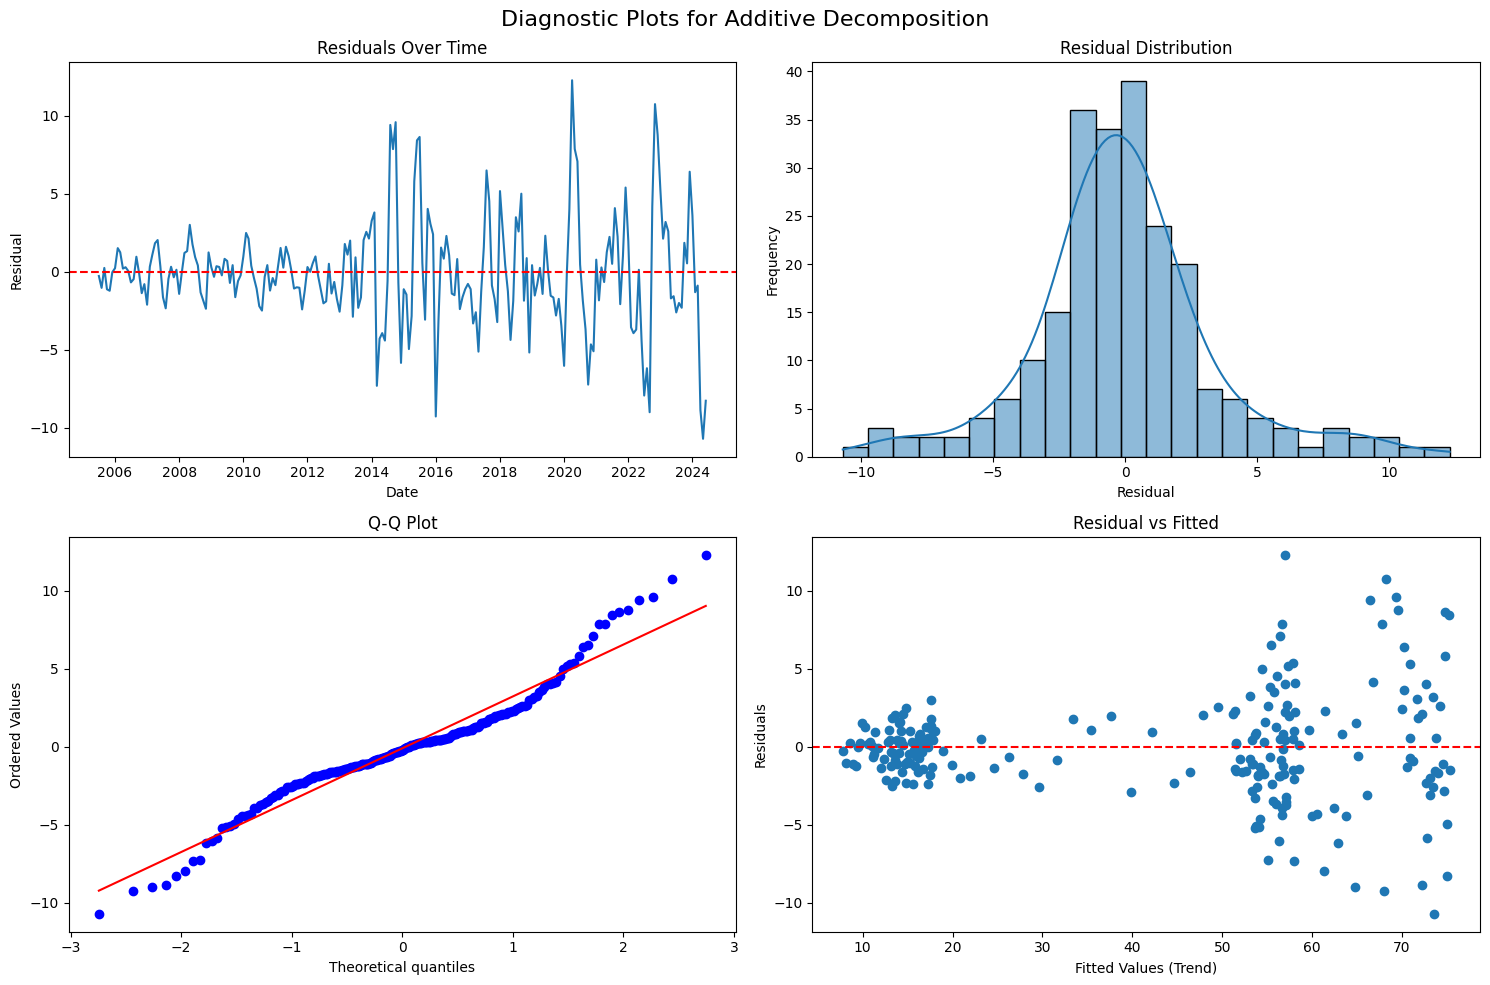

In [1616]:
# Create diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residual Plot over time
ax1.plot(df_stl.index, df_stl['residual_add'])
ax1.axhline(y=0, color='r', linestyle='--')
ax1.set_title('Residuals Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Residual')

# 2. Residual Histogram
sns.histplot(df_stl['residual_add'].dropna(), kde=True, ax=ax2)
ax2.set_title('Residual Distribution')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Frequency')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(df_stl['residual_add'].dropna(), dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot')

# 4. Residual vs Fitted (Trend)
ax4.scatter(df_stl['trend_add'], df_stl['residual_add'])
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_title('Residual vs Fitted')
ax4.set_xlabel('Fitted Values (Trend)')
ax4.set_ylabel('Residuals')
plt.suptitle('Diagnostic Plots for Additive Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

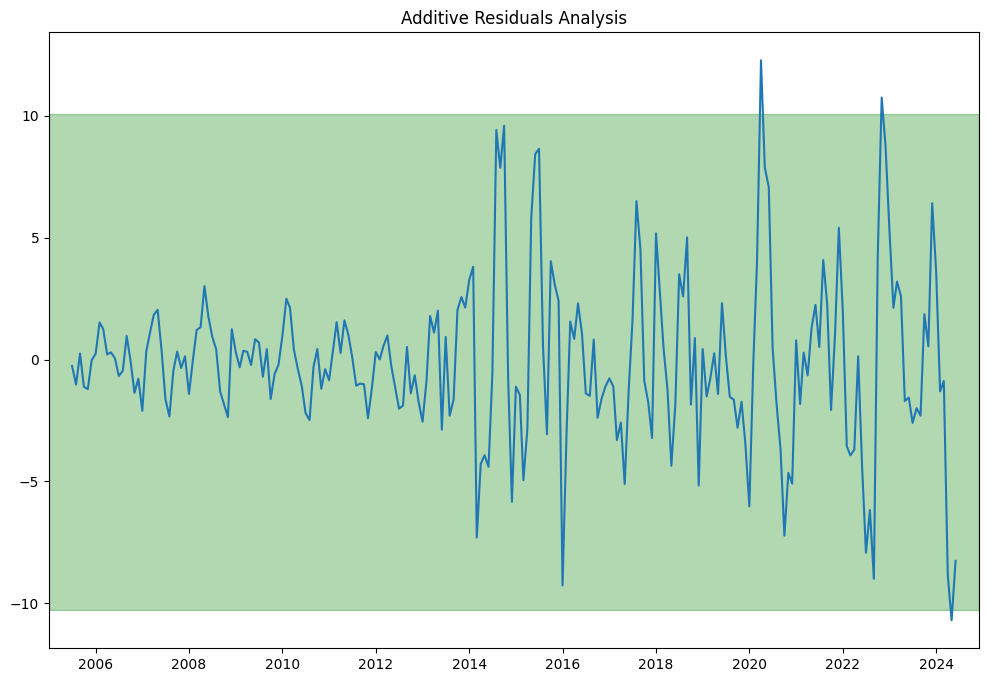

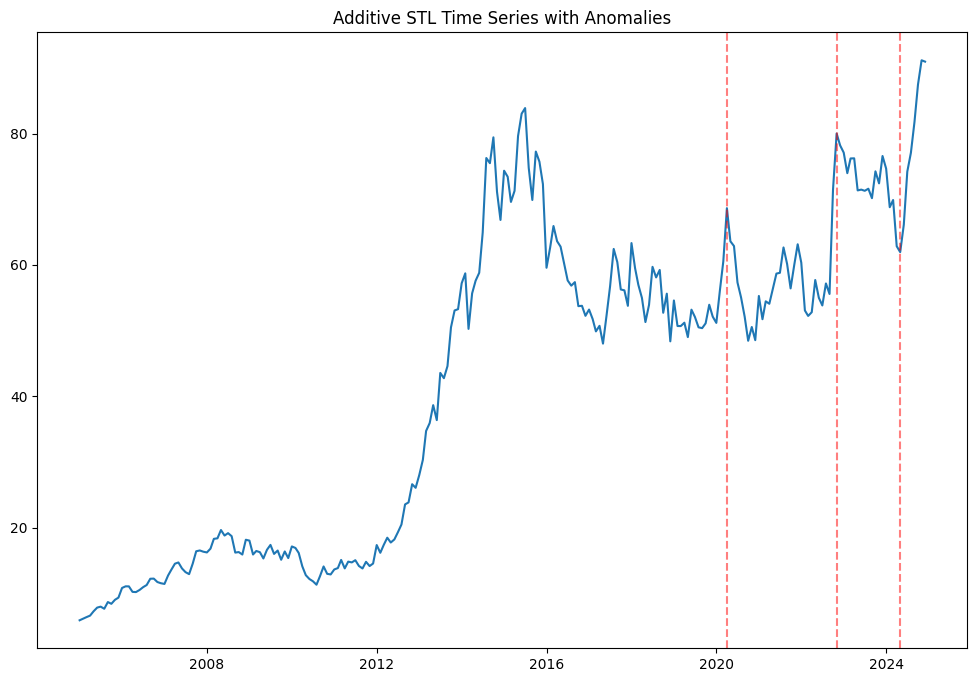

Dates of Anomalies: DatetimeIndex(['2020-04-01', '2022-11-01', '2024-05-01'], dtype='datetime64[ns]', name='Date', freq=None)


In [1617]:
# Residual Analysis
res = pd.DataFrame(seasonal_decomp_add.resid)
res.columns = ['resid']

# Calculate statistics
res.resid_mean = res.resid.mean()
res.resid_std = res.resid.std()
lower_bound = res.resid_mean - 3 * res.resid_std
upper_bound = res.resid_mean + 3 * res.resid_std

# Plot the residuals
plt.figure(figsize=(12, 8))
plt.plot(res.resid)
plt.fill_between(res.resid.index, lower_bound, upper_bound, color='green', alpha=0.3)
plt.title('Additive Residuals Analysis')
plt.xlim(res.resid.index[0], res.resid.index[-1])
plt.show()

# Anomaly Detection
anomalies = res.resid[(res.resid < lower_bound) | (res.resid > upper_bound)]
plt.figure(figsize=(12, 8))
plt.plot(raw_df['Close'])  
for i in anomalies.index:
    plt.axvline(i, color='r', linestyle='--', alpha=0.5)
plt.title('Additive STL Time Series with Anomalies')
plt.show()

print(f'Dates of Anomalies: {anomalies.index}')

In [1618]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(df_stl['residual_add'].dropna())

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 55.7577
LM test p-value: 2.2790094839537187e-08

ARCH LM Test Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests there is ARCH effect present in the residuals.


In [1619]:
# Print Write Noice
white_noise_add = acorr_ljungbox(df_stl['residual_add'].dropna(), lags = [12], return_df=True)
white_noise_add

# Print the p-value from the Ljung-Box test 
print(f"Ljung-Box test p-value: {white_noise_add['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_add['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")

Ljung-Box test p-value: 1.0220833073493274e-27

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


## Additive GARCH Model

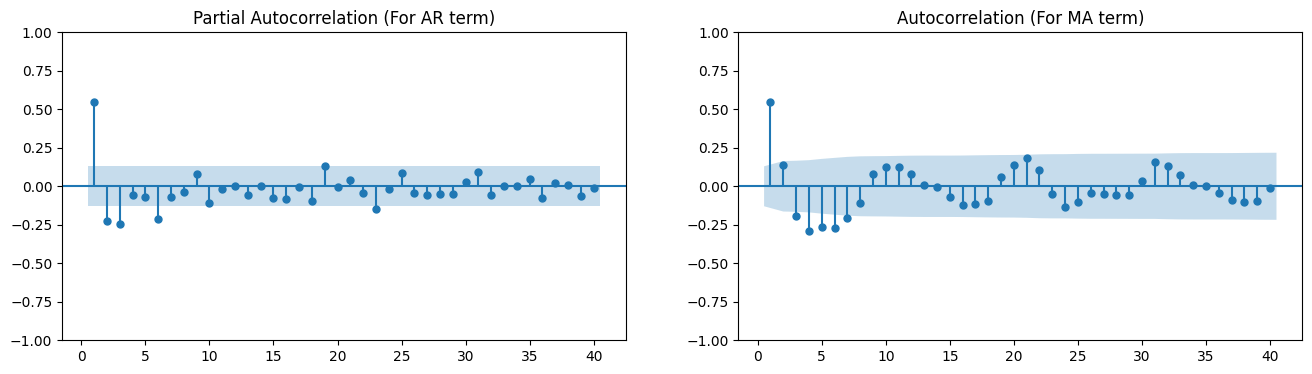

Iteration:      1,   Func. Count:      7,   Neg. LLF: 6080.330780645411
Iteration:      2,   Func. Count:     14,   Neg. LLF: 4754.824653189207
Iteration:      3,   Func. Count:     21,   Neg. LLF: 587.7728700867685
Iteration:      4,   Func. Count:     29,   Neg. LLF: 537.2697994093548
Iteration:      5,   Func. Count:     36,   Neg. LLF: 537.0411155004816
Iteration:      6,   Func. Count:     43,   Neg. LLF: 534.4330893670324
Iteration:      7,   Func. Count:     49,   Neg. LLF: 534.4177194735838
Iteration:      8,   Func. Count:     55,   Neg. LLF: 534.4170793522156
Iteration:      9,   Func. Count:     61,   Neg. LLF: 534.4170738994173
Iteration:     10,   Func. Count:     66,   Neg. LLF: 534.417073455596
Optimization terminated successfully    (Exit mode 0)
            Current function value: 534.4170738994173
            Iterations: 10
            Function evaluations: 66
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results                

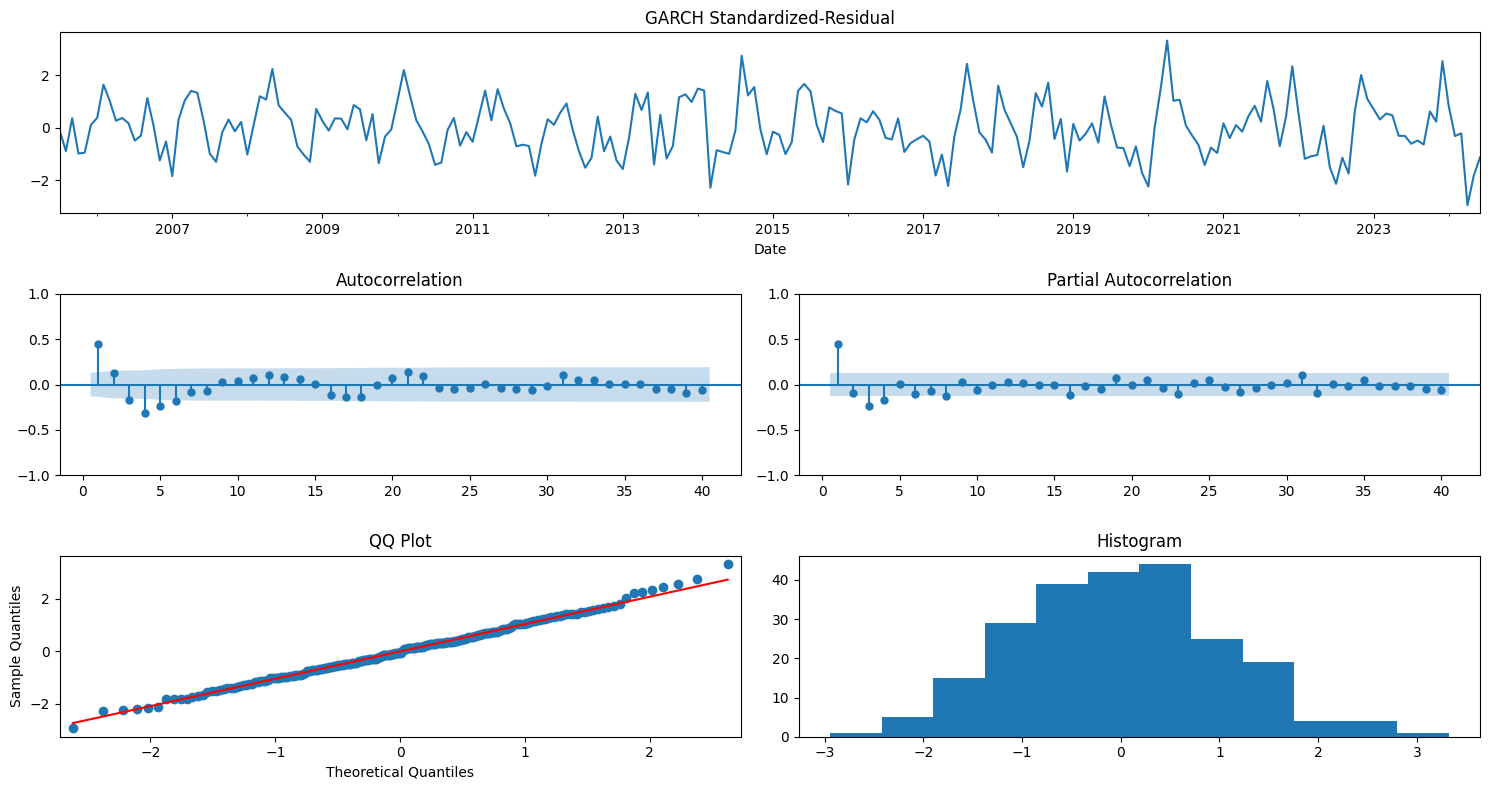

In [ ]:
#GARCH Model
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_stl['residual_add'].dropna(), lags=40, zero=False, ax=ax2, title='Autocorrelation (For MA term)')
plot_pacf(df_stl['residual_add'].dropna(), lags=40, zero=False, ax=ax1, title = 'Partial Autocorrelation (For AR term)')
plt.show()

add_garch = arch_model(df_stl['residual_add'].dropna(), vol = 'GARCH', p = 1, q = 1)
add_garch_fit = add_garch.fit()
print(add_garch_fit.summary())

garch_std_resid = pd.Series(add_garch_fit.resid / add_garch_fit.conditional_volatility)
fig = plt.figure(figsize = (15, 8))

# Residual
garch_std_resid.plot(ax = fig.add_subplot(3,1,1), title = 'GARCH Standardized-Residual', legend = False)

# ACF/PACF
sgt.plot_acf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,3))
sgt.plot_pacf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,4))

# QQ-Plot & Norm-Dist
sm.qqplot(garch_std_resid, line='s', ax=fig.add_subplot(3,2,5)) 
plt.title("QQ Plot")
fig.add_subplot(3,2,6).hist(garch_std_resid, bins = 12)
plt.title("Histogram")

plt.tight_layout()
plt.show()

In [1621]:
add_garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:           residual_add   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -534.417
Distribution:                  Normal   AIC:                           1078.83
Method:            Maximum Likelihood   BIC:                           1095.98
                                        No. Observations:                  228
Date:                Tue, Apr 01 2025   Df Residuals:                      227
Time:                        23:36:43   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.1526      0.122     -1.248      0.212 [ -0.392,8.702e-02]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.2076      0.160      1.299      0.194    [ -0.106,  0.521]
alpha[1]       0.3485  9.852e-02      3.537  4.042e-04    [  0.155,  0.542]
beta[1]        0.2954      0.152      1.942  5.209e-02 [-2.672e-03,  0.593]
beta[2]        0.3561      0.174      2.047  4.065e-02  [1.516e-02,  0.697]
===========================================================================

Covariance estimator: robust
"""

In [1622]:
# Detect GARCH model order
p = len([param for param in add_garch_fit.params.index if 'alpha' in param])
q = len([param for param in add_garch_fit.params.index if 'beta' in param])

print(f"Detected GARCH({p},{q}) model")

# Print all parameters
print("\nModel Parameters:")
for param_name, value in add_garch_fit.params.items():
    print(f"{param_name}: {value:.6f}")

# Construct equation based on model order
equation = f"σ²(t) = {add_garch_fit.params['omega']:.6f}"

# Add ARCH terms (alpha)
for i in range(1, p+1):
    alpha = add_garch_fit.params[f'alpha[{i}]']
    equation += f" + {alpha:.6f}*ε²(t-{i})"

# Add GARCH terms (beta)
for i in range(1, q+1):
    beta = add_garch_fit.params[f'beta[{i}]']
    equation += f" + {beta:.6f}*σ²(t-{i})"

print("\nGARCH Equation:")
print(equation)

print("\nwhere:")
print("σ²(t)   = conditional variance at time t")
print("ε²(t-i) = squared error term at lag i")
print("σ²(t-i) = conditional variance at lag i")

Detected GARCH(1,2) model

Model Parameters:
mu: -0.152646
omega: 0.207638
alpha[1]: 0.348493
beta[1]: 0.295411
beta[2]: 0.356096

GARCH Equation:
σ²(t) = 0.207638 + 0.348493*ε²(t-1) + 0.295411*σ²(t-1) + 0.356096*σ²(t-2)

where:
σ²(t)   = conditional variance at time t
ε²(t-i) = squared error term at lag i
σ²(t-i) = conditional variance at lag i


In [1623]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(garch_std_resid)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 7.1216
LM test p-value: 0.7139217522199338

ARCH LM Test Interpretation:
Since p-value > 0.05, we fail to reject the null hypothesis.
This suggests there is no ARCH effect in the residuals.



Method Comparison Results:
                Method  Point Weight  Upper Weight  Lower Weight     MAPE
         Random Search       0.70910      0.110279      0.180621 5.924822
Differential Evolution       0.18206      0.373957      0.443983 5.924829
           Grid Search       0.10000      0.400000      0.500000 5.933681

Best Combination:
Method: Random Search
Weights: Point=0.709, Upper=0.110, Lower=0.181
MAPE: 5.92%


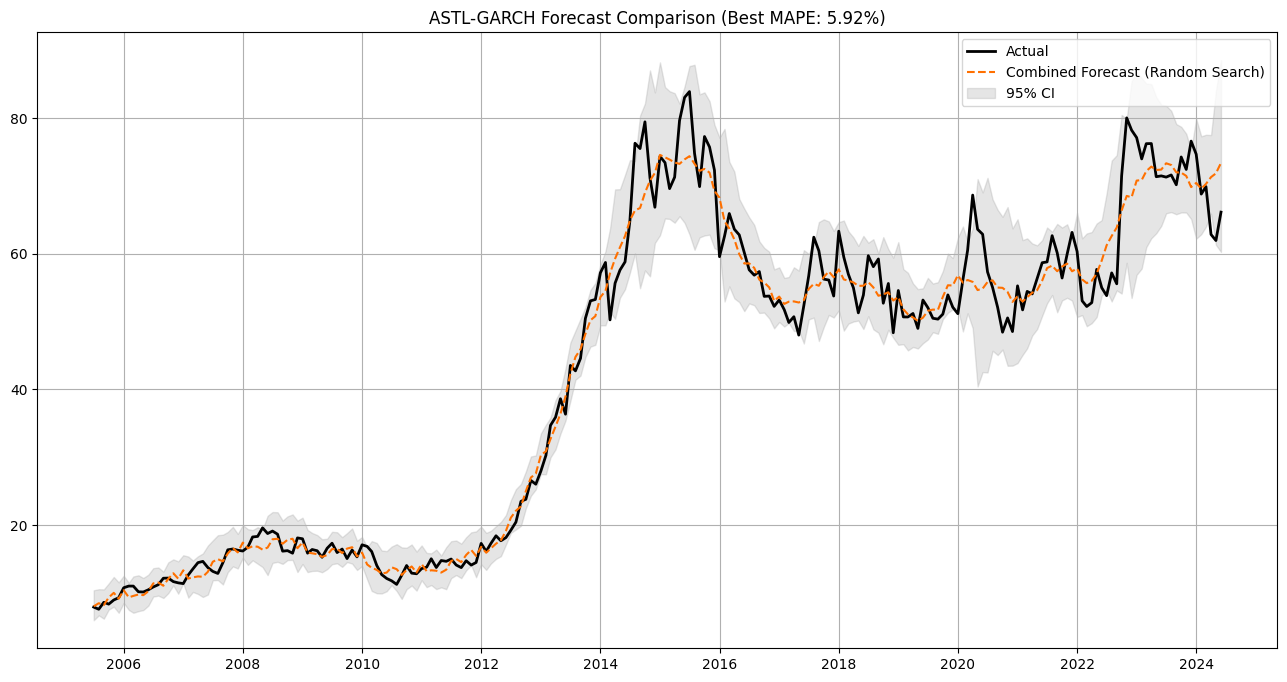

In [1624]:
# 1. Prepare volatility-adjusted forecasts
volatility = add_garch_fit.conditional_volatility
mstl_point = df_stl['add_fitted'].dropna()
upper_bound = mstl_point + 1.96 * volatility
lower_bound = mstl_point - 1.96 * volatility

# 2. Create forecast DataFrame
forecasts = pd.DataFrame({
    'Point': mstl_point,
    'Upper': upper_bound,
    'Lower': lower_bound,
    'Actual': df_stl['Close'].dropna()
}).dropna()

# 3. Define multiple optimization methods
def grid_search_weights(forecasts, precision=0.1):
    best_mape = float('inf')
    best_weights = None
    for w1 in np.arange(0, 1+precision, precision):
        for w2 in np.arange(0, 1-w1+precision, precision):
            w3 = 1 - w1 - w2
            combined = w1*forecasts['Point'] + w2*forecasts['Upper'] + w3*forecasts['Lower']
            current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
            if current_mape < best_mape:
                best_mape = current_mape
                best_weights = (w1, w2, w3)
    return best_weights, best_mape

def random_search_weights(forecasts, iterations=1000):
    best_mape = float('inf')
    best_weights = None
    for _ in range(iterations):
        weights = np.random.dirichlet(np.ones(3))
        combined = weights[0]*forecasts['Point'] + weights[1]*forecasts['Upper'] + weights[2]*forecasts['Lower']
        current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
        if current_mape < best_mape:
            best_mape = current_mape
            best_weights = weights
    return best_weights, best_mape

def diff_evolution_weights(forecasts):
    X = forecasts[['Point', 'Upper', 'Lower']].values
    y = forecasts['Actual'].values
    
    def mape_objective(weights):
        return np.mean(np.abs((y - X@weights)/y))*100
    
    constraints = NonlinearConstraint(lambda w: np.sum(w), 1, 1)
    bounds = [(0,1)]*3
    
    result = differential_evolution(
        mape_objective,
        bounds,
        constraints=constraints,
        popsize=15,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42,
        tol=0.001
    )
    return result.x, result.fun

# 4. Run all optimization methods
methods = {
    'Grid Search': grid_search_weights(forecasts),
    'Random Search': random_search_weights(forecasts),
    'Differential Evolution': diff_evolution_weights(forecasts)
}

# 5. Compare results
print("\nMethod Comparison Results:")
print("="*40)
results_df = pd.DataFrame([
    {
        'Method': method,
        'Point Weight': weights[0],
        'Upper Weight': weights[1], 
        'Lower Weight': weights[2],
        'MAPE': mape
    }
    for method, (weights, mape) in methods.items()
]).sort_values('MAPE')

print(results_df.to_string(index=False))

# 6. Select best method
best_method = results_df.iloc[0]['Method']
best_weights, best_mape = methods[best_method]
multi_y_pred = (best_weights[0]*forecasts['Point'] + 
               best_weights[1]*forecasts['Upper'] + 
               best_weights[2]*forecasts['Lower'])

# 7. Enhanced visualization
plt.figure(figsize=(16,8))

# Plot actual vs combined forecast
plt.plot(forecasts['Actual'], label='Actual', color='k', linewidth=2)
plt.plot(multi_y_pred, label=f'Combined Forecast ({best_method})', linestyle='--', color='#FF7000')
plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                color='gray', alpha=0.2, label='95% CI')
plt.title(f"ASTL-GARCH Forecast Comparison (Best MAPE: {best_mape:.2f}%)")
plt.legend()
plt.grid(True)

# 8. Final output
print("\nBest Combination:")
print(f"Method: {best_method}")
print(f"Weights: Point={best_weights[0]:.3f}, Upper={best_weights[1]:.3f}, Lower={best_weights[2]:.3f}")
print(f"MAPE: {best_mape:.2f}%")


Combined model improves MAPE by 0.02% points
Using MSTL-GARCH combined forecast

Model Comparison:
              Model     MAPE Improvement
          Pure MSTL 5.947847           -
MSTL-GARCH Combined 5.924822       0.02%


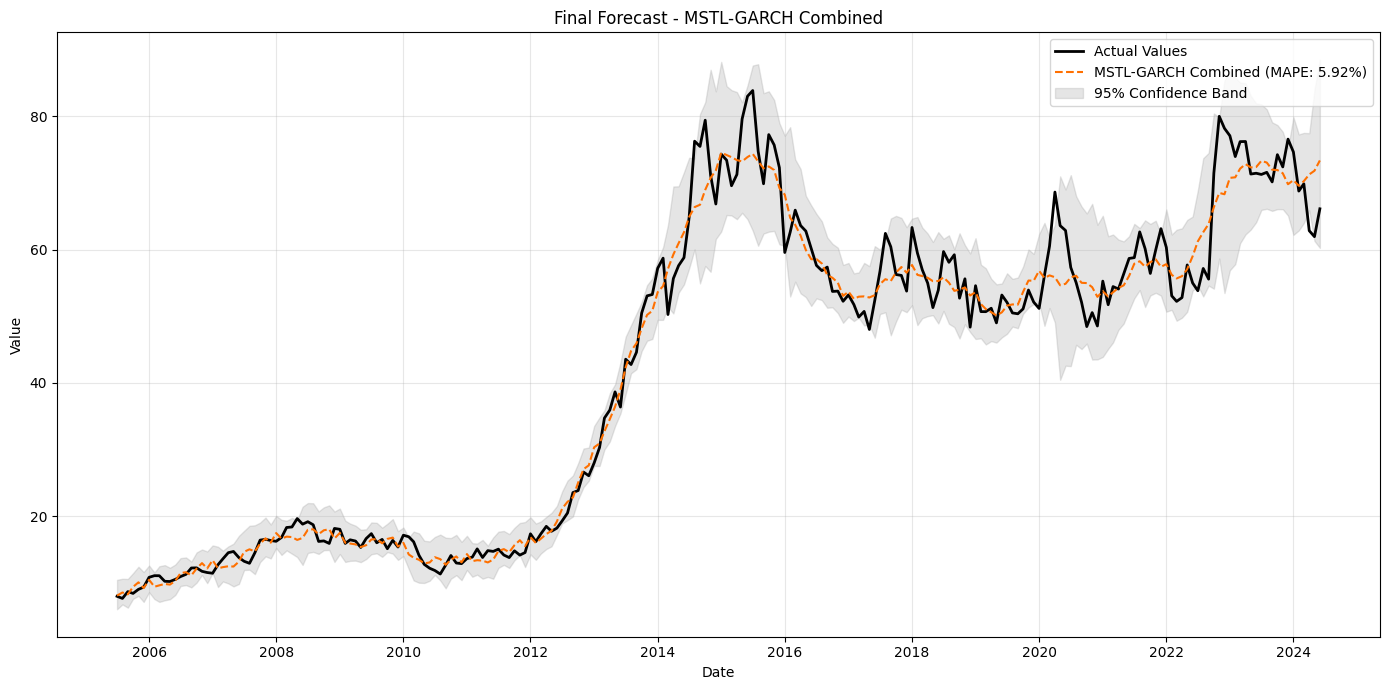


Best forecast stored in df_stl['final_forecast']


In [1625]:
# 1. Calculate pure MSTL performance
add_only_mape = np.mean(np.abs((forecasts['Actual'] - forecasts['Point'])/forecasts['Actual'])) * 100

# 2. Compare with combined model
if best_mape < add_only_mape:
    print(f"\nCombined model improves MAPE by {add_only_mape-best_mape:.2f}% points")
    print("Using MSTL-GARCH combined forecast")
    add_y_pred = (best_weights[0]*forecasts['Point'] + 
                   best_weights[1]*forecasts['Upper'] + 
                   best_weights[2]*forecasts['Lower'])
    best_model_name = "MSTL-GARCH Combined"
else:
    print("\nPure MSTL performs better than combined model")
    print("Using pure MSTL forecast")
    add_y_pred = forecasts['Point']
    best_model_name = "Pure MSTL"
    best_mape = add_only_mape

# 3. Final comparison table
comparison = pd.DataFrame({
    'Model': ['Pure MSTL', 'MSTL-GARCH Combined'],
    'MAPE': [add_only_mape, best_mape],
    'Improvement': ['-', f"{add_only_mape-best_mape:.2f}%"]
})
print("\nModel Comparison:")
print(comparison.to_string(index=False))

# 4. Final visualization
plt.figure(figsize=(14,7))
plt.plot(forecasts['Actual'], label='Actual Values', color='black', linewidth=2)
plt.plot(add_y_pred, label=f'{best_model_name} (MAPE: {best_mape:.2f}%)', 
         color='#FF7000', linestyle='--')

if best_model_name == "MSTL-GARCH Combined":
    plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                    color='gray', alpha=0.2, label='95% Confidence Band')

plt.title(f"Final Forecast - {best_model_name}")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Store final forecast
df_stl['final_forecast'] = add_y_pred
print("\nBest forecast stored in df_stl['final_forecast']")

In [1626]:
# Print Write Noice
white_noise_add = acorr_ljungbox(garch_std_resid, lags = [12], return_df=True)
white_noise_add

# Print the p-value from the Ljung-Box test
print("\n")
print(f"Ljung-Box test p-value: {white_noise_add['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_add['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")



Ljung-Box test p-value: 2.899908792612064e-17

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


# Multiplicative STL Model

## Multiplicative STL Model

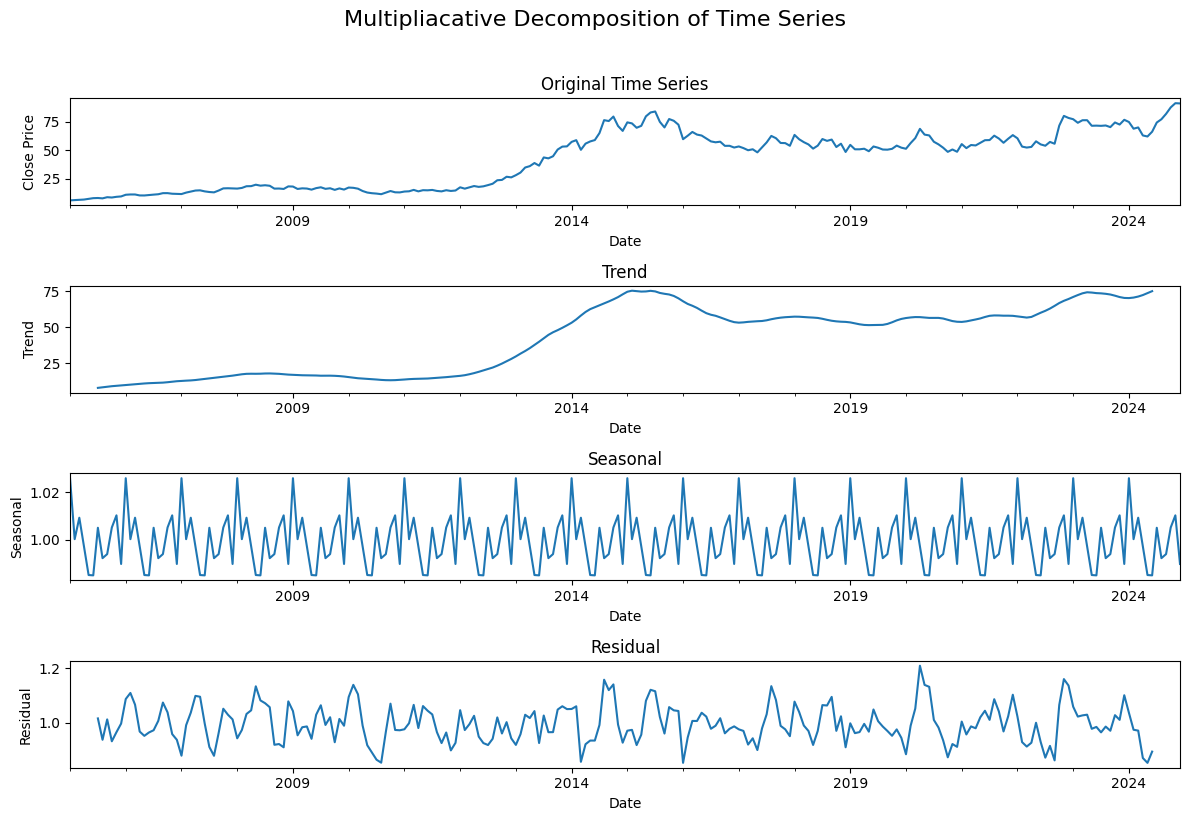

In [1627]:
#Multiplicative Decomposition
from statsmodels.tsa.seasonal import STL, seasonal_decompose
seasonal_decomp_multi = seasonal_decompose(df_stl['Close'], model='multiplicative', period=12)
df_stl['trend_multi'] = seasonal_decomp_multi.trend
df_stl['seasonal_multi'] = seasonal_decomp_multi.seasonal
df_stl['residual_multi'] = seasonal_decomp_multi.resid

#plot graph
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))

# Plot original data
df_stl['Close'].plot(ax=ax1)
ax1.set_title('Original Time Series')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')

# Plot trend
seasonal_decomp_multi.trend.plot(ax=ax2)
ax2.set_title('Trend')
ax2.set_xlabel('Date')
ax2.set_ylabel('Trend')

# Plot seasonal
seasonal_decomp_multi.seasonal.plot(ax=ax3)
ax3.set_title('Seasonal')
ax3.set_xlabel('Date')
ax3.set_ylabel('Seasonal')

# Plot residual
seasonal_decomp_multi.resid.plot(ax=ax4)
ax4.set_title('Residual')
ax4.set_xlabel('Date')
ax4.set_ylabel('Residual')

# Add main title
plt.suptitle('Multipliacative Decomposition of Time Series', fontsize=16, y=1.02)

# Adjust layout
plt.tight_layout()
plt.show()

## Multiplicative STL Model Forecast

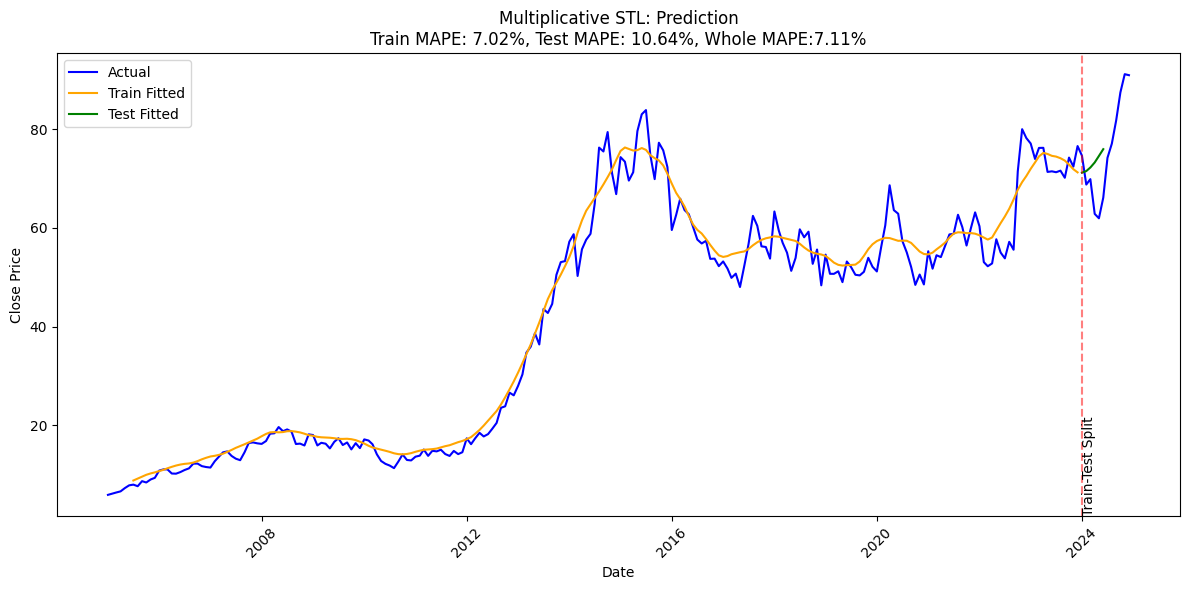

In [1628]:
# Calculate fitted values (predictions)
df_stl['multi_fitted'] = df_stl['trend_multi'] + df_stl['seasonal_multi']

# Create train and test masks
train_mask = df_stl.index <= train_end
test_mask = (df_stl.index > train_end) & (df_stl.index <= test_end)

# Calculate MAPE for train and test sets
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

train_mape = calculate_mape(df_stl.loc[train_mask, 'Close'], df_stl.loc[train_mask, 'multi_fitted'])
test_mape = calculate_mape(df_stl.loc[test_mask, 'Close'], df_stl.loc[test_mask, 'multi_fitted'])
whole_mape = calculate_mape(df_stl['Close'], df_stl['multi_fitted'])

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_stl['Close'], label='Actual', color='blue')
plt.plot(df_stl.loc[train_mask, 'multi_fitted'], label='Train Fitted', color='orange')
plt.plot(df_stl.loc[test_mask, 'multi_fitted'], label='Test Fitted', color='green')
plt.axvline(x=train_end, color='red', linestyle='--', alpha=0.5)
plt.text(train_end, plt.ylim()[0], 'Train-Test Split', rotation=90, verticalalignment='bottom')
plt.title(
    f'Multiplicative STL: Prediction\n'
    f'Train MAPE: {train_mape:.2f}%, Test MAPE: {test_mape:.2f}%, Whole MAPE:{whole_mape:.2f}%'
)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multiplcative STL Model Residual Analysis

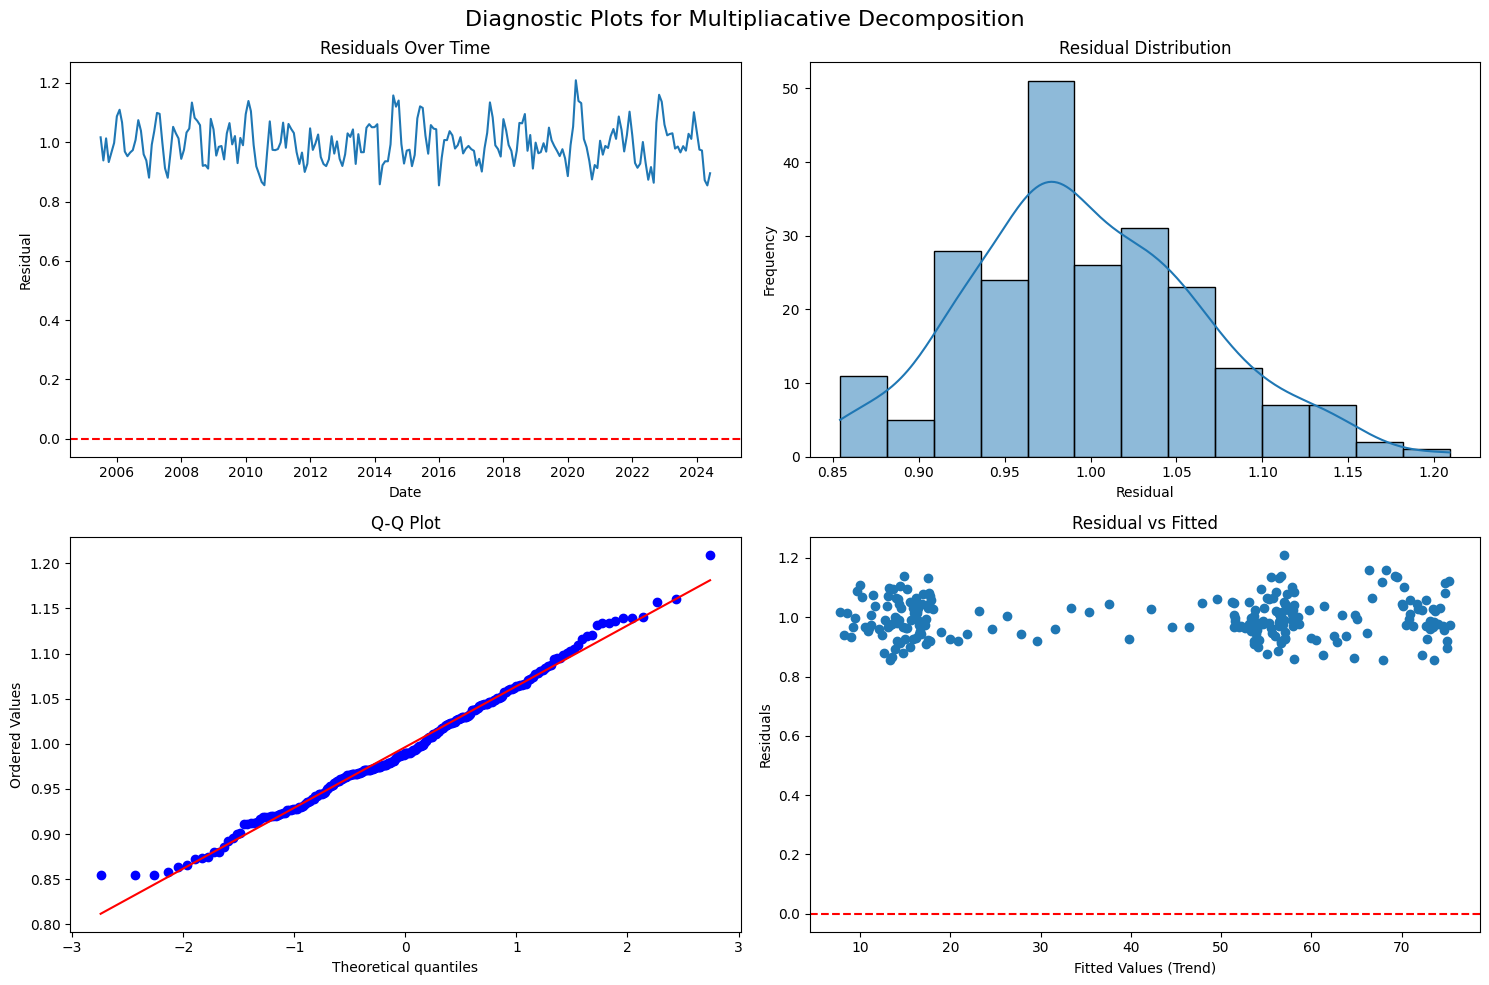

In [1629]:
# Create diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residual Plot over time
ax1.plot(df_stl.index, df_stl['residual_multi'])
ax1.axhline(y=0, color='r', linestyle='--')
ax1.set_title('Residuals Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Residual')

# 2. Residual Histogram
sns.histplot(df_stl['residual_multi'].dropna(), kde=True, ax=ax2)
ax2.set_title('Residual Distribution')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Frequency')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(df_stl['residual_multi'].dropna(), dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot')

# 4. Residual vs Fitted (Trend)
ax4.scatter(df_stl['trend_multi'], df_stl['residual_multi'])
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_title('Residual vs Fitted')
ax4.set_xlabel('Fitted Values (Trend)')
ax4.set_ylabel('Residuals')

plt.suptitle('Diagnostic Plots for Multipliacative Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

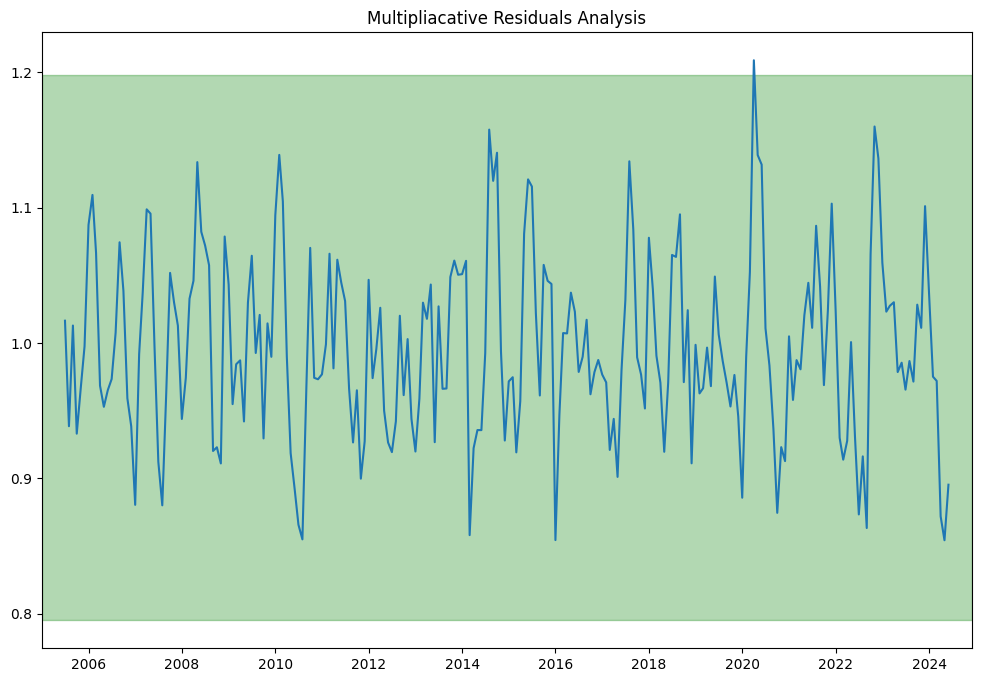

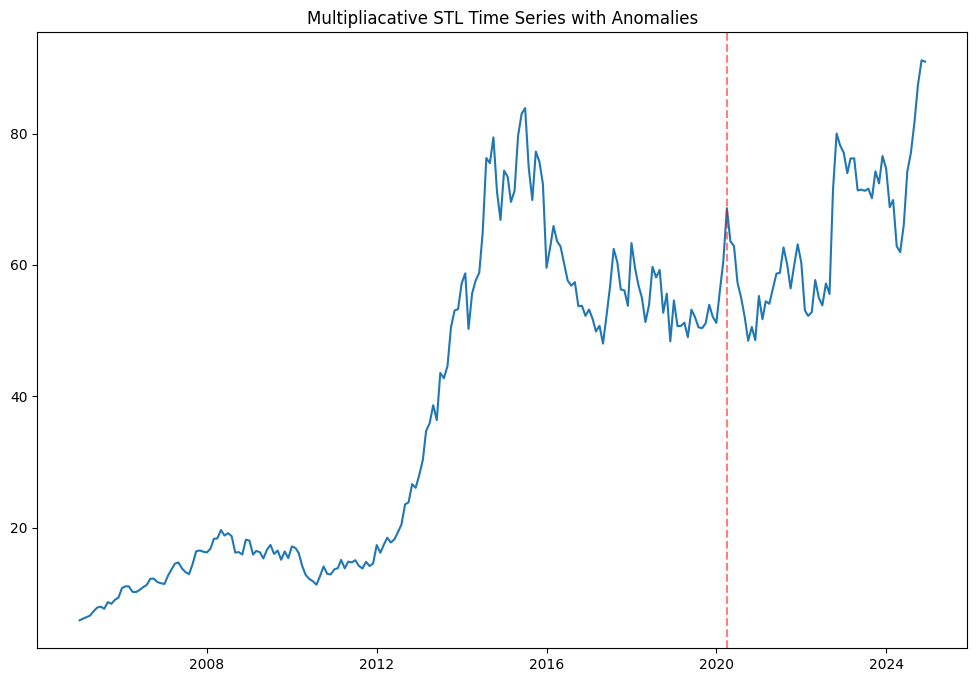

Dates of Anomalies: DatetimeIndex(['2020-04-01'], dtype='datetime64[ns]', name='Date', freq=None)


In [1630]:
# Residual Analysis
res = pd.DataFrame(seasonal_decomp_multi.resid)
res.columns = ['resid']

# Calculate statistics
res.resid_mean = res.resid.mean()
res.resid_std = res.resid.std()
lower_bound = res.resid_mean - 3 * res.resid_std
upper_bound = res.resid_mean + 3 * res.resid_std

# Plot the residuals
plt.figure(figsize=(12, 8))
plt.plot(res.resid)
plt.fill_between(res.resid.index, lower_bound, upper_bound, color='green', alpha=0.3)
plt.title('Multipliacative Residuals Analysis')
plt.xlim(res.resid.index[0], res.resid.index[-1])
plt.show()

# Anomaly Detection
anomalies = res.resid[(res.resid < lower_bound) | (res.resid > upper_bound)]
plt.figure(figsize=(12, 8))
plt.plot(raw_df['Close'])  
for i in anomalies.index:
    plt.axvline(i, color='r', linestyle='--', alpha=0.5)
plt.title('Multipliacative STL Time Series with Anomalies')
plt.show()

print(f'Dates of Anomalies: {anomalies.index}')

In [1631]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(df_stl['residual_multi'].dropna())

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 85.8593
LM test p-value: 3.5326063367906394e-14

ARCH LM Test Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests there is ARCH effect present in the residuals.


In [1632]:
# Print Write Noice
white_noise_multi = acorr_ljungbox(df_stl['residual_multi'].dropna(), lags = [12], return_df=True)
white_noise_multi

# Print the p-value from the Ljung-Box test
print("\n=== Ljung-Box test Results ===")
print(f"Ljung-Box test p-value: {white_noise_multi['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_multi['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")


=== Ljung-Box test Results ===
Ljung-Box test p-value: 3.5063073205305405e-21

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


## Multiplicative GARCH Model

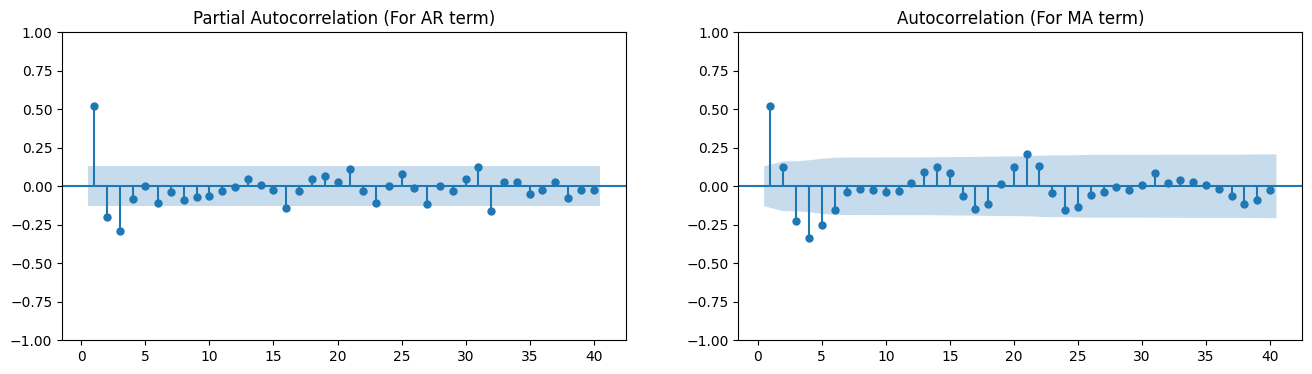

Iteration:      1,   Func. Count:      5,   Neg. LLF: 756297.7032757244
Iteration:      2,   Func. Count:     14,   Neg. LLF: -107.74295042375394
Iteration:      3,   Func. Count:     22,   Neg. LLF: -276.21815625743466
Iteration:      4,   Func. Count:     27,   Neg. LLF: 1458169.1805132255
Iteration:      5,   Func. Count:     33,   Neg. LLF: -301.3714488421213
Iteration:      6,   Func. Count:     37,   Neg. LLF: -301.3720643366484
Iteration:      7,   Func. Count:     41,   Neg. LLF: -301.3720712056967
Iteration:      8,   Func. Count:     44,   Neg. LLF: -301.37207120568326
Optimization terminated successfully    (Exit mode 0)
            Current function value: -301.3720712056967
            Iterations: 8
            Function evaluations: 44
            Gradient evaluations: 8
                      Constant Mean - ARCH Model Results                      
Dep. Variable:         residual_multi   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-s

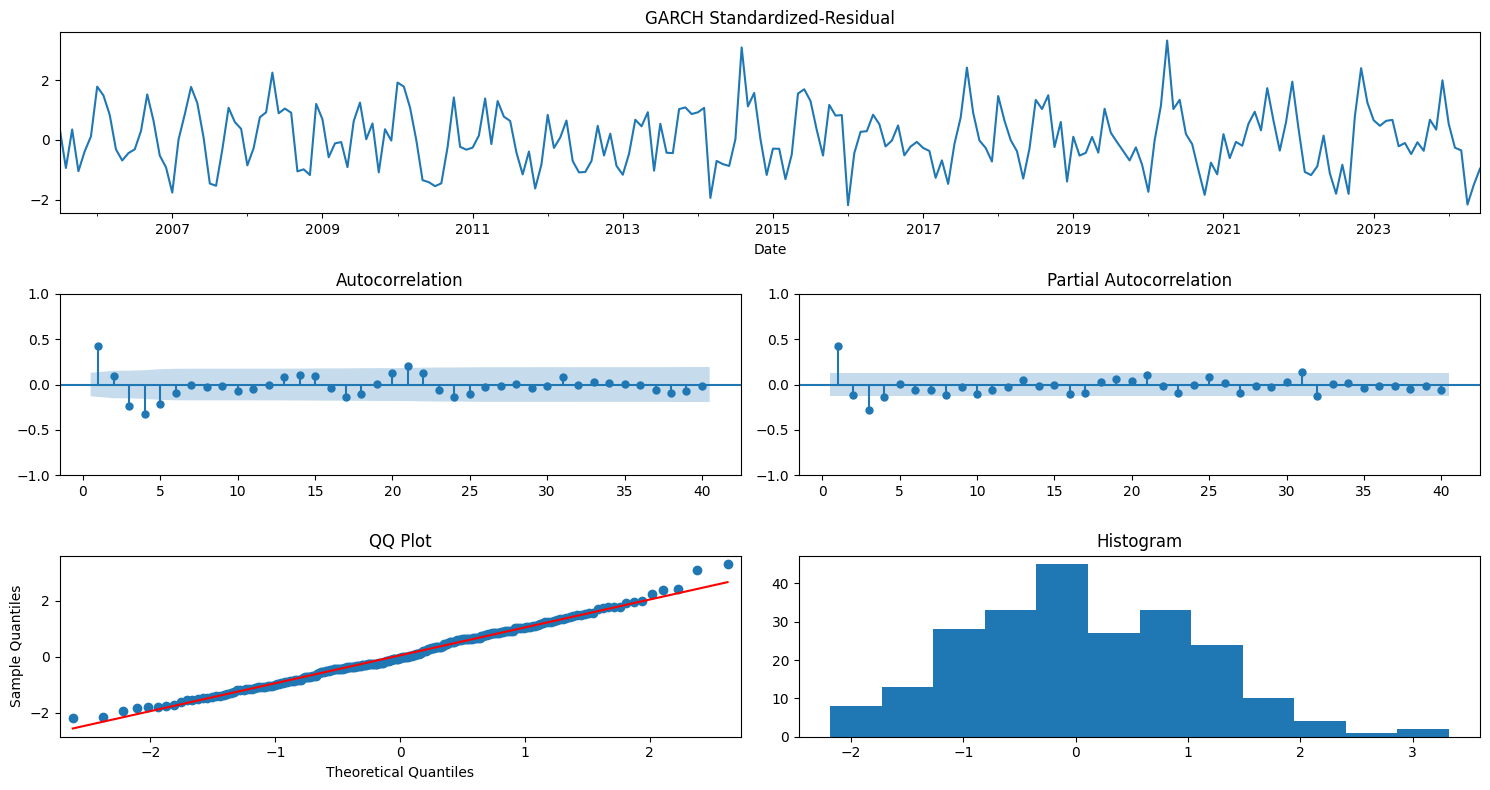

In [ ]:
#GARCH Model
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_stl['residual_multi'].dropna(), lags=40, zero=False, ax=ax2, title='Autocorrelation (For MA term)')
plot_pacf(df_stl['residual_multi'].dropna(), lags=40, zero=False, ax=ax1, title = 'Partial Autocorrelation (For AR term)')
plt.show()

multi_garch = arch_model(df_stl['residual_multi'].dropna(), vol = 'GARCH', p = 1, q = 1)
multi_garch_fit = multi_garch.fit()
print(multi_garch_fit.summary())

garch_std_resid = pd.Series(multi_garch_fit.resid / multi_garch_fit.conditional_volatility)
fig = plt.figure(figsize = (15, 8))

# Residual
garch_std_resid.plot(ax = fig.add_subplot(3,1,1), title = 'GARCH Standardized-Residual', legend = False)

# ACF/PACF
sgt.plot_acf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,3))
sgt.plot_pacf(garch_std_resid, zero = False, lags = 40, ax=fig.add_subplot(3,2,4))

# QQ-Plot & Norm-Dist
sm.qqplot(garch_std_resid, line='s', ax=fig.add_subplot(3,2,5)) 
plt.title("QQ Plot")
fig.add_subplot(3,2,6).hist(garch_std_resid, bins = 12)
plt.title("Histogram")

plt.tight_layout()
plt.show()

In [1634]:
multi_garch_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:         residual_multi   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                301.372
Distribution:                  Normal   AIC:                          -596.744
Method:            Maximum Likelihood   BIC:                          -586.456
                                        No. Observations:                  228
Date:                Tue, Apr 01 2025   Df Residuals:                      227
Time:                        23:36:49   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.9913  5.291e-03    187.361      0.000 [  0.981,  1.002]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.8899e-03  4.708e-04      6.138  8.369e-10 [1.967e-03,3.813e-03]
alpha[1]       0.3720      0.119      3.118  1.818e-03     [  0.138,  0.606]
============================================================================

Covariance estimator: robust
"""

In [1635]:
# Detect GARCH model order
p = len([param for param in multi_garch_fit.params.index if 'alpha' in param])
q = len([param for param in multi_garch_fit.params.index if 'beta' in param])

print(f"Detected GARCH({p},{q}) model")

# Print all parameters
print("\nModel Parameters:")
for param_name, value in multi_garch_fit.params.items():
    print(f"{param_name}: {value:.6f}")

# Construct equation based on model order
equation = f"σ²(t) = {multi_garch_fit.params['omega']:.6f}"

# Add ARCH terms (alpha)
for i in range(1, p+1):
    alpha = multi_garch_fit.params[f'alpha[{i}]']
    equation += f" + {alpha:.6f}*ε²(t-{i})"

# Add GARCH terms (beta)
for i in range(1, q+1):
    beta = multi_garch_fit.params[f'beta[{i}]']
    equation += f" + {beta:.6f}*σ²(t-{i})"

print("\nGARCH Equation:")
print(equation)

print("\nwhere:")
print("σ²(t)   = conditional variance at time t")
print("ε²(t-i) = squared error term at lag i")
print("σ²(t-i) = conditional variance at lag i")

Detected GARCH(1,0) model

Model Parameters:
mu: 0.991301
omega: 0.002890
alpha[1]: 0.372021

GARCH Equation:
σ²(t) = 0.002890 + 0.372021*ε²(t-1)

where:
σ²(t)   = conditional variance at time t
ε²(t-i) = squared error term at lag i
σ²(t-i) = conditional variance at lag i


In [1636]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(garch_std_resid)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 2.4360
LM test p-value: 0.9917757767055065

ARCH LM Test Interpretation:
Since p-value > 0.05, we fail to reject the null hypothesis.
This suggests there is no ARCH effect in the residuals.



Method Comparison Results:
                Method  Point Weight  Upper Weight  Lower Weight     MAPE
           Grid Search      0.000000      0.000000      1.000000 6.848962
Differential Evolution      0.000557      0.000278      0.999165 6.849248
         Random Search      0.036210      0.003994      0.959797 6.860309

Best Combination:
Method: Grid Search
Weights: Point=0.000, Upper=0.000, Lower=1.000
MAPE: 6.85%


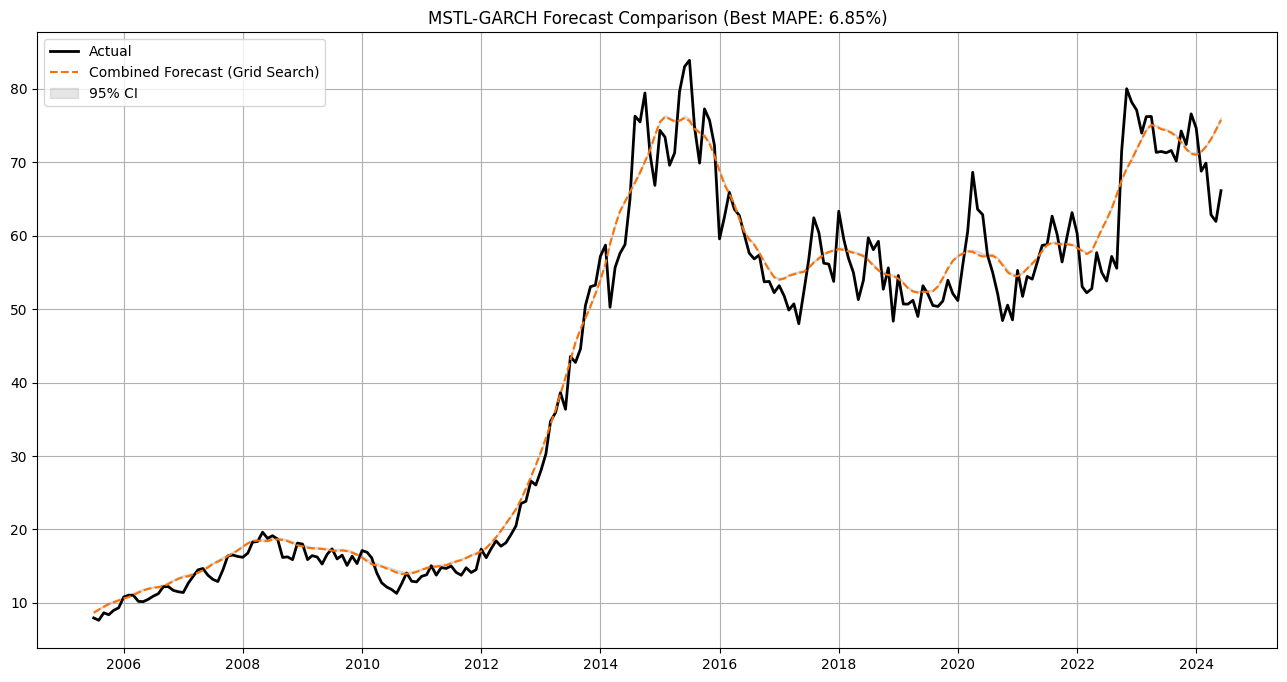

In [1637]:
# 1. Prepare volatility-adjusted forecasts
volatility = multi_garch_fit.conditional_volatility
mstl_point = df_stl['multi_fitted'].dropna()
upper_bound = mstl_point + 1.96 * volatility
lower_bound = mstl_point - 1.96 * volatility

# 2. Create forecast DataFrame
forecasts = pd.DataFrame({
    'Point': mstl_point,
    'Upper': upper_bound,
    'Lower': lower_bound,
    'Actual': df_stl['Close'].dropna()
}).dropna()

# 3. Define multiple optimization methods
def grid_search_weights(forecasts, precision=0.1):
    best_mape = float('inf')
    best_weights = None
    for w1 in np.arange(0, 1+precision, precision):
        for w2 in np.arange(0, 1-w1+precision, precision):
            w3 = 1 - w1 - w2
            combined = w1*forecasts['Point'] + w2*forecasts['Upper'] + w3*forecasts['Lower']
            current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
            if current_mape < best_mape:
                best_mape = current_mape
                best_weights = (w1, w2, w3)
    return best_weights, best_mape

def random_search_weights(forecasts, iterations=1000):
    best_mape = float('inf')
    best_weights = None
    for _ in range(iterations):
        weights = np.random.dirichlet(np.ones(3))
        combined = weights[0]*forecasts['Point'] + weights[1]*forecasts['Upper'] + weights[2]*forecasts['Lower']
        current_mape = np.mean(np.abs((forecasts['Actual'] - combined)/forecasts['Actual']))*100
        if current_mape < best_mape:
            best_mape = current_mape
            best_weights = weights
    return best_weights, best_mape

def diff_evolution_weights(forecasts):
    X = forecasts[['Point', 'Upper', 'Lower']].values
    y = forecasts['Actual'].values
    
    def mape_objective(weights):
        return np.mean(np.abs((y - X@weights)/y))*100
    
    constraints = NonlinearConstraint(lambda w: np.sum(w), 1, 1)
    bounds = [(0,1)]*3
    
    result = differential_evolution(
        mape_objective,
        bounds,
        constraints=constraints,
        popsize=15,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42,
        tol=0.001
    )
    return result.x, result.fun

# 4. Run all optimization methods
methods = {
    'Grid Search': grid_search_weights(forecasts),
    'Random Search': random_search_weights(forecasts),
    'Differential Evolution': diff_evolution_weights(forecasts)
}

# 5. Compare results
print("\nMethod Comparison Results:")
print("="*40)
results_df = pd.DataFrame([
    {
        'Method': method,
        'Point Weight': weights[0],
        'Upper Weight': weights[1], 
        'Lower Weight': weights[2],
        'MAPE': mape
    }
    for method, (weights, mape) in methods.items()
]).sort_values('MAPE')

print(results_df.to_string(index=False))

# 6. Select best method
best_method = results_df.iloc[0]['Method']
best_weights, best_mape = methods[best_method]
multi_y_pred = (best_weights[0]*forecasts['Point'] + 
               best_weights[1]*forecasts['Upper'] + 
               best_weights[2]*forecasts['Lower'])

# 7. Enhanced visualization
plt.figure(figsize=(16,8))

# Plot actual vs combined forecast
plt.plot(forecasts['Actual'], label='Actual', color='k', linewidth=2)
plt.plot(multi_y_pred, label=f'Combined Forecast ({best_method})', linestyle='--', color='#FF7000')
plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                color='gray', alpha=0.2, label='95% CI')
plt.title(f"MSTL-GARCH Forecast Comparison (Best MAPE: {best_mape:.2f}%)")
plt.legend()
plt.grid(True)

# 8. Final output
print("\nBest Combination:")
print(f"Method: {best_method}")
print(f"Weights: Point={best_weights[0]:.3f}, Upper={best_weights[1]:.3f}, Lower={best_weights[2]:.3f}")
print(f"MAPE: {best_mape:.2f}%")


Combined model improves MAPE by 0.27% points
Using MSTL-GARCH combined forecast

Model Comparison:
              Model     MAPE Improvement
          Pure MSTL 7.114270           -
MSTL-GARCH Combined 6.848962       0.27%


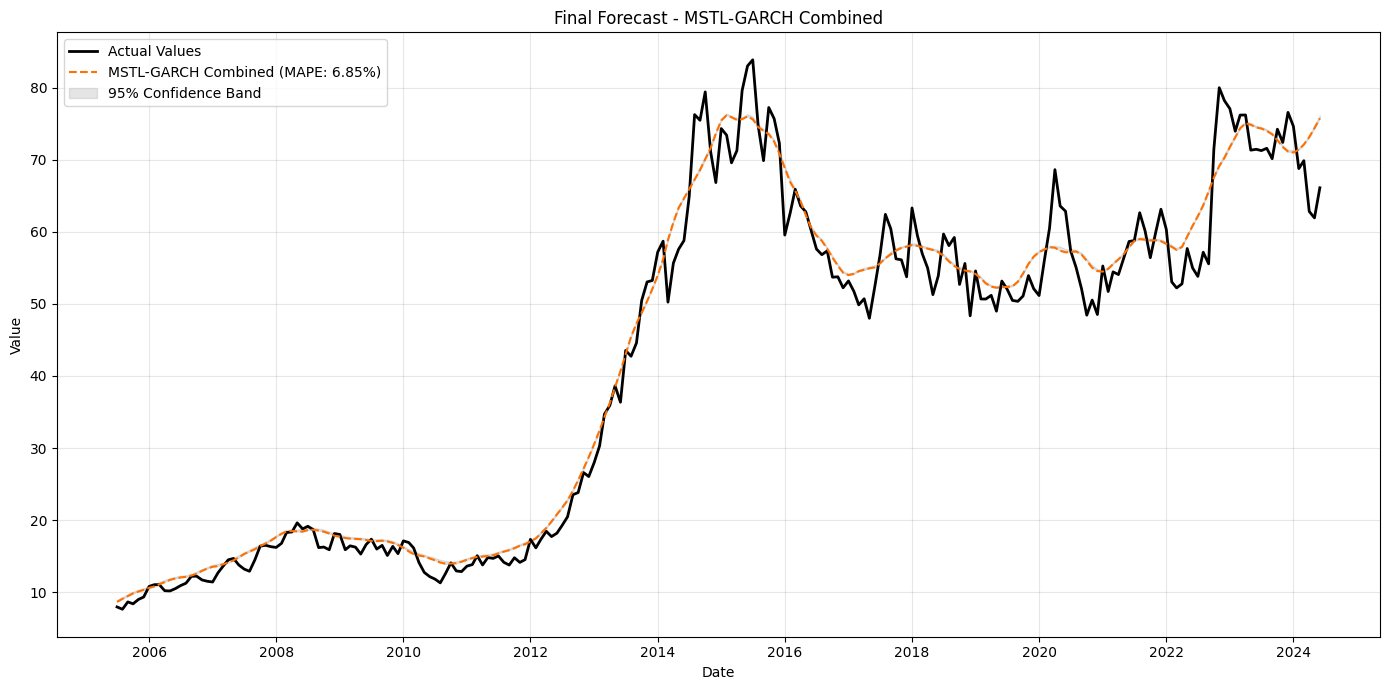


Best forecast stored in df_stl['final_forecast']


In [1638]:
# 1. Calculate pure MSTL performance
mstl_only_mape = np.mean(np.abs((forecasts['Actual'] - forecasts['Point'])/forecasts['Actual'])) * 100

# 2. Compare with combined model
if best_mape < mstl_only_mape:
    print(f"\nCombined model improves MAPE by {mstl_only_mape-best_mape:.2f}% points")
    print("Using MSTL-GARCH combined forecast")
    multi_y_pred = (best_weights[0]*forecasts['Point'] + 
                   best_weights[1]*forecasts['Upper'] + 
                   best_weights[2]*forecasts['Lower'])
    best_model_name = "MSTL-GARCH Combined"
else:
    print("\nPure MSTL performs better than combined model")
    print("Using pure MSTL forecast")
    multi_y_pred = forecasts['Point']
    best_model_name = "Pure MSTL"
    best_mape = mstl_only_mape

# 3. Final comparison table
comparison = pd.DataFrame({
    'Model': ['Pure MSTL', 'MSTL-GARCH Combined'],
    'MAPE': [mstl_only_mape, best_mape],
    'Improvement': ['-', f"{mstl_only_mape-best_mape:.2f}%"]
})
print("\nModel Comparison:")
print(comparison.to_string(index=False))

# 4. Final visualization
plt.figure(figsize=(14,7))
plt.plot(forecasts['Actual'], label='Actual Values', color='black', linewidth=2)
plt.plot(multi_y_pred, label=f'{best_model_name} (MAPE: {best_mape:.2f}%)', 
         color='#FF7000', linestyle='--')

if best_model_name == "MSTL-GARCH Combined":
    plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                    color='gray', alpha=0.2, label='95% Confidence Band')

plt.title(f"Final Forecast - {best_model_name}")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Store final forecast
df_stl['final_forecast'] = multi_y_pred
print("\nBest forecast stored in df_stl['final_forecast']")

In [1639]:
# Print Write Noice
white_noise_add = acorr_ljungbox(garch_std_resid, lags = [12], return_df=True)
white_noise_add

# Print the p-value from the Ljung-Box test
print("\n")
print(f"Ljung-Box test p-value: {white_noise_add['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_add['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")



Ljung-Box test p-value: 2.2121649016501487e-15

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


# ARIMA Model

## ARIMA Model

ADF Statistic: -0.6472245123232313
p-value: 0.859950295455792
Data is non-stationary


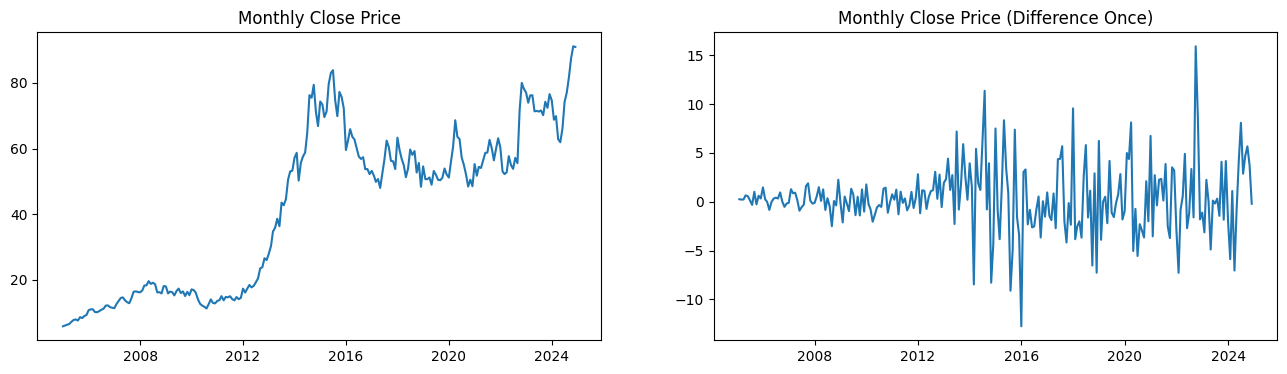

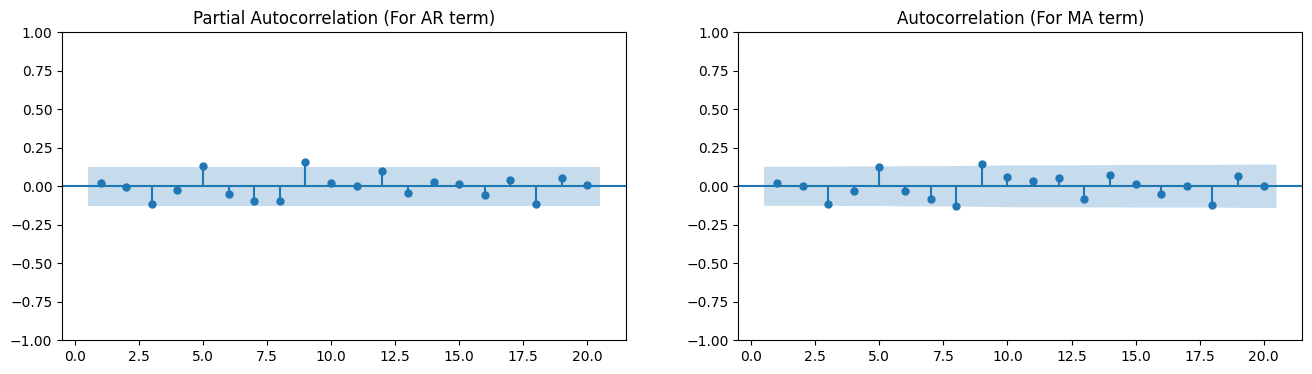

In [1640]:
#Import data
arima_df = raw_df['Close']

#infer the frequency of the data
df_freq = arima_df.asfreq(pd.infer_freq(raw_df.index))

#ADF Test (for stationarity)
result = adfuller(arima_df.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] <= 0.05:
    print('Data is stationary')
    diff_order = 0
else:
    print('Data is non-stationary')
    diff_order = 1

diff = arima_df.diff()[1:]
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(arima_df)
ax1.set_title('Monthly Close Price')
ax2.plot(diff)
ax2.set_title('Monthly Close Price (Difference Once)')
plt.show()

#ACF and PACF plots for the data
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
if diff_order == 0:
    setting = arima_df
else:
    setting = diff
plot_acf(setting, lags=20, zero=False, ax=ax2, title='Autocorrelation (For MA term)')
plot_pacf(setting, lags=20, zero=False, ax=ax1, title = 'Partial Autocorrelation (For AR term)')
plt.show()

In [1641]:
#Arima Model
pmd_mdl = pmd.auto_arima(y = arima_df,
                         d = diff_order)
print(pmd_mdl.summary())

# Get fitted values (in-sample predictions)
fitted_values = pd.Series(pmd_mdl.predict_in_sample(), index=arima_df.index)
# Calculate residuals
residuals = arima_df - fitted_values

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  240
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -625.968
Date:                Tue, 01 Apr 2025   AIC                           1263.935
Time:                        23:36:53   BIC                           1284.794
Sample:                    01-01-2005   HQIC                          1272.341
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6014      0.392      1.532      0.125      -0.168       1.371
ar.L1          0.2478      0.041      5.985      0.000       0.167       0.329
ar.L2         -0.9429      0.033    -28.417      0.0

In [1642]:
pmd_mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  240
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -625.968
Date:                Tue, 01 Apr 2025   AIC                           1263.935
Time:                        23:36:53   BIC                           1284.794
Sample:                    01-01-2005   HQIC                          1272.341
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6014      0.392      1.532      0.125      -0.168       1.371
ar.L1          0.2478      0.041      5.985      0.000       0.167       0.329
ar.L2         -0.9429      0.033    -28.417      0.000      -1.008      -0.878
ma.L1         -0.1825      0.040     -4.514      0.000      -0.262      -0.103
ma.L2          0.9445      0.037     25.434      0.000       0.872       1.017
sigma2        11.0018      0.807     13.636      0.000       9.420      12.583
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):                54.48
Prob(Q):                              0.45   Prob(JB):                         0.00
Heteroskedasticity (H):              18.10   Skew:                             0.42
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [1643]:
order = pmd_mdl.order  # (p,d,q)
params = pmd_mdl.params()  
# Build AR terms
ar_terms = ""
if order[0] > 0:  # If AR terms exist
    ar_coefs = params[1:1+order[0]]  # Slice AR coefficients
    ar_terms = " - " + " - ".join([f"{coef:.4f}L^{i+1}" 
                                  for i, coef in enumerate(ar_coefs)])

# Build MA terms
ma_terms = ""
if order[2] > 0:  # If MA terms exist
    ma_coefs = params[1+order[0]:]  # Slice MA coefficients
    ma_terms = " + " + " + ".join([f"{coef:.4f}L^{i+1}" 
                                  for i, coef in enumerate(ma_coefs)])

# Construct full equation
print(f"\nARIMA{order} Equation:")
print(f"(1{ar_terms})(1 - L)^{order[1]} y_t = {params[0]:.4f} + (1{ma_terms}) ε_t")


ARIMA(2, 1, 2) Equation:
(1 - 0.2478L^1 - -0.9429L^2)(1 - L)^1 y_t = 0.6014 + (1 + -0.1825L^1 + 0.9445L^2 + 11.0018L^3) ε_t


## ARIMA Model Forecast

Training Set MAPE: 5.99 %
Test Set MAPE: 11.61 %
Full Dataset MAPE: 6.27 %
Root Mean Squared Error: 9.9916128419668


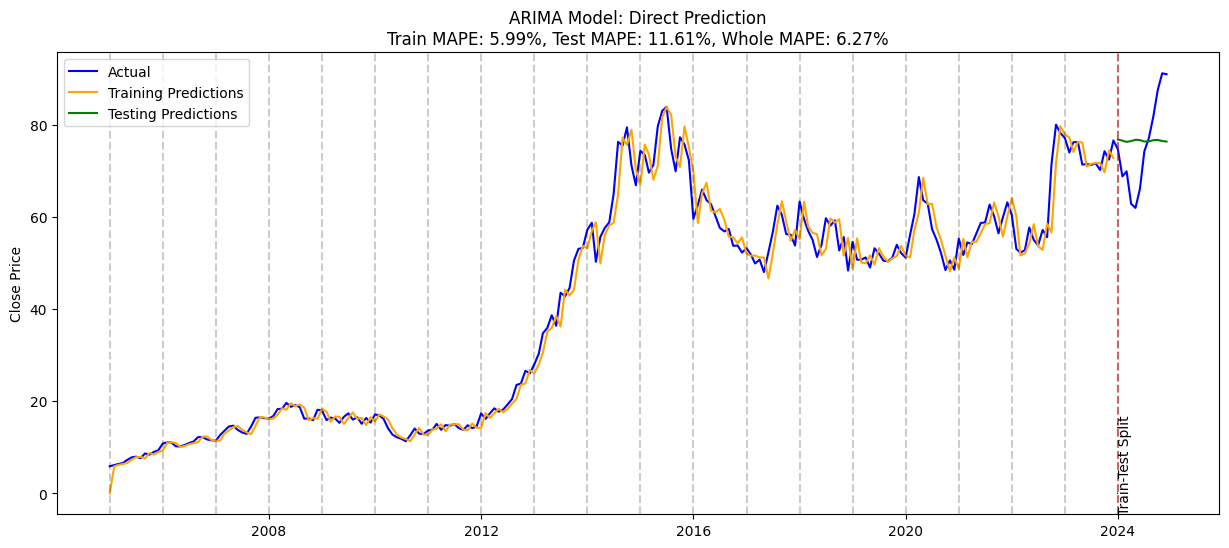

In [1644]:
# Split the data
train_end = datetime(2023, 12, 31)
test_end = datetime(2024, 12, 31)
train_data = raw_df['Close'][:train_end]
test_data = raw_df['Close'][train_end + timedelta(days=1):test_end]

# Fit ARIMA model once on training data
model = SARIMAX(train_data, order=pmd_mdl.order)
model_fit = model.fit(disp=False)

# Direct forecasting for the entire test period
forecast_steps = len(test_data)
forecast = model_fit.get_forecast(steps=forecast_steps)
predictions = forecast.predicted_mean
confidence_intervals = forecast.conf_int(alpha=0.05)  # 95% confidence intervals

# Calculate metrics
train_predictions = model_fit.get_prediction(start=train_data.index[0]).predicted_mean
train_residuals = train_data - train_predictions
test_residuals = test_data - predictions

# Calculate MAPE
train_mape = round(np.mean(abs(train_residuals/train_data)) * 100, 2)
test_mape = round(np.mean(abs(test_residuals/test_data)) * 100, 2)

# Combine predictions for full dataset
full_predictions = pd.concat([train_predictions, predictions])
full_actual = pd.concat([train_data, test_data])
full_residuals = full_actual - full_predictions
full_mape = round(np.mean(abs(full_residuals/full_actual)) * 100, 2)

# Print metrics
print('Training Set MAPE:', train_mape, '%')
print('Test Set MAPE:', test_mape, '%')
print('Full Dataset MAPE:', full_mape, '%')
print('Root Mean Squared Error:', np.sqrt(np.mean(test_residuals**2)))

# Store MAPE values
arima_train_mape = train_mape
arima_test_mape = test_mape
arima_whole_mape = full_mape

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(raw_df['Close'], label='Actual', color='blue')
plt.plot(train_predictions, label='Training Predictions', color='orange')
plt.plot(predictions, label='Testing Predictions', color='green')
plt.axvline(x=train_end, color='red', linestyle='--', alpha=0.5)
plt.text(train_end, plt.ylim()[0], 'Train-Test Split', rotation=90, verticalalignment='bottom')
plt.title(
    f'ARIMA Model: Direct Prediction\n'
    f'Train MAPE: {train_mape:.2f}%, '
    f'Test MAPE: {test_mape:.2f}%, '
    f'Whole MAPE: {full_mape:.2f}%'
)
plt.ylabel('Close Price')
plt.legend()
for year in range(2005, 2025):
    plt.axvline(datetime(year,1,1), color='k', linestyle='--', alpha=0.2)
plt.show()

## ARIMA Model Residual Analysis

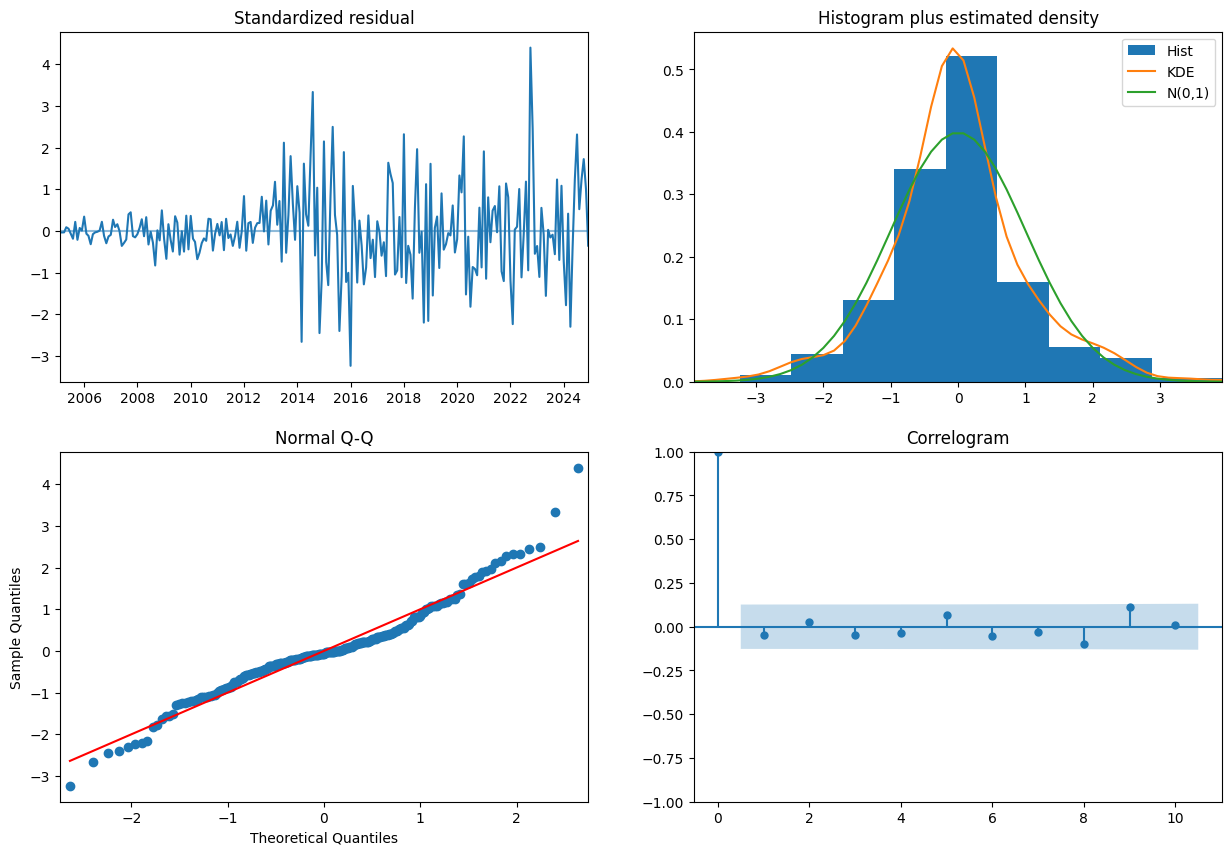

In [1645]:
pmd_mdl.plot_diagnostics(figsize = (15, 10))
plt.show()

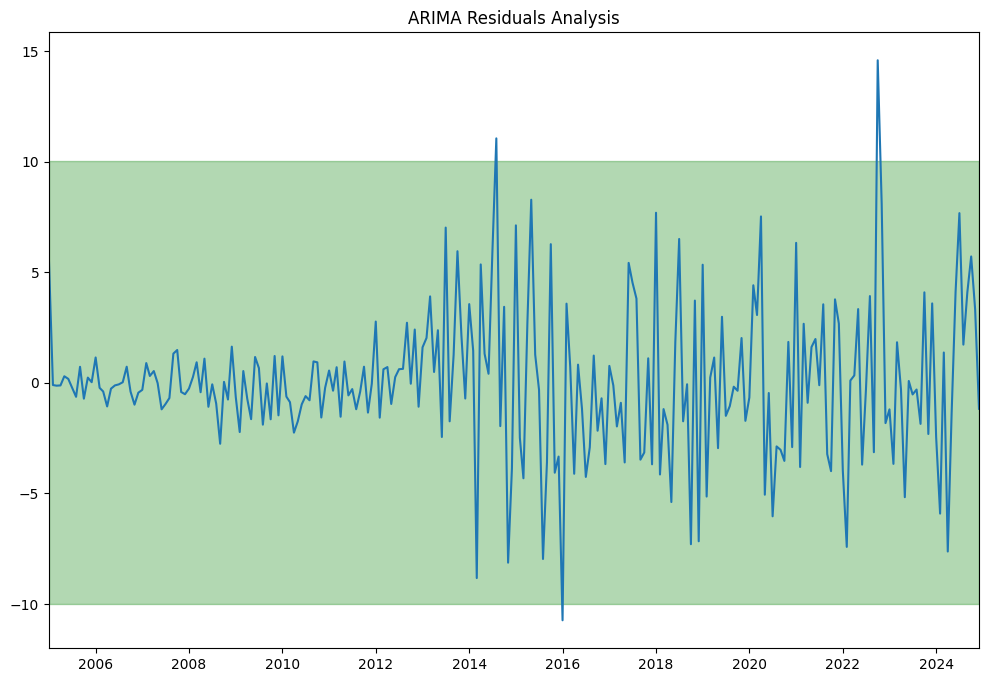

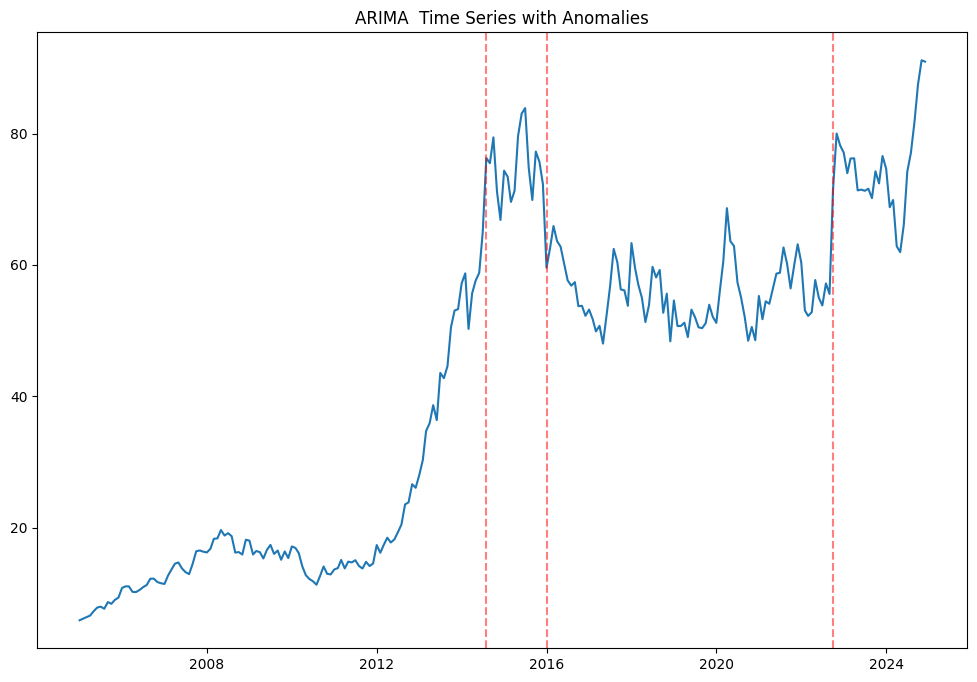

Dates of Anomalies: DatetimeIndex(['2014-08-01', '2016-01-01', '2022-10-01'], dtype='datetime64[ns]', name='Date', freq=None)


In [1646]:
# Calculate statistics
res.resid_mean = residuals.mean()
res.resid_std = residuals.std()
lower_bound = res.resid_mean - 3 * res.resid_std
upper_bound = res.resid_mean + 3 * res.resid_std

# Plot the residuals
plt.figure(figsize=(12, 8))
plt.plot(residuals)
plt.fill_between(residuals.index, lower_bound, upper_bound, color='green', alpha=0.3)
plt.title('ARIMA Residuals Analysis')
plt.xlim(residuals.index[0], residuals.index[-1])
plt.show()

# Anomaly Detection
anomalies = residuals[(residuals < lower_bound) | (residuals > upper_bound)]
plt.figure(figsize=(12, 8))
plt.plot(raw_df['Close'])
for i in anomalies.index:
    plt.axvline(i, color='r', linestyle='--', alpha=0.5)
plt.title('ARIMA  Time Series with Anomalies')
plt.show()

print(f'Dates of Anomalies: {anomalies.index}')

In [1647]:
# Print Write Noice
white_noise_arima = acorr_ljungbox(residuals, lags = [12], return_df=True)
white_noise_arima

# Print the p-value from the Ljung-Box test
print("\n=== Ljung-Box test Results ===")
print(f"Ljung-Box test p-value: {white_noise_arima['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_arima['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")


=== Ljung-Box test Results ===
Ljung-Box test p-value: 0.3998817785935515

Interpretation:
Since p-value > 0.05, we fail to reject the null hypothesis.
This suggests the residuals are independent (white noise).


In [1648]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(residuals)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 25.6393
LM test p-value: 0.004256812590031472

ARCH LM Test Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests there is ARCH effect present in the residuals.


In [1649]:
arima_model = arch_model(residuals, vol='GARCH', p=1, q=2)
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 34075.28481272678
Iteration:      2,   Func. Count:     15,   Neg. LLF: 81642.99945411205
Iteration:      3,   Func. Count:     22,   Neg. LLF: 576.5085843211301
Iteration:      4,   Func. Count:     29,   Neg. LLF: 575.0585692785266
Iteration:      5,   Func. Count:     36,   Neg. LLF: 576.3183088673711
Iteration:      6,   Func. Count:     43,   Neg. LLF: 572.6789018866386
Iteration:      7,   Func. Count:     49,   Neg. LLF: 572.620066819566
Iteration:      8,   Func. Count:     55,   Neg. LLF: 572.6103281312594
Iteration:      9,   Func. Count:     61,   Neg. LLF: 572.6098033164915
Iteration:     10,   Func. Count:     67,   Neg. LLF: 572.6097275036822
Iteration:     11,   Func. Count:     72,   Neg. LLF: 572.6097264968339
Optimization terminated successfully    (Exit mode 0)
            Current function value: 572.6097275036822
            Iterations: 11
            Function evaluations: 72
            Gradient evaluations: 11


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -572.610
Distribution:                  Normal   AIC:                           1155.22
Method:            Maximum Likelihood   BIC:                           1172.62
                                        No. Observations:                  240
Date:                Tue, Apr 01 2025   Df Residuals:                      239
Time:                        23:36:54   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.0523      0.112     -0.468      0.640 [ -0.271,  0.167]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.0651      0.172      0.378      0.706 [ -0.273,  0.403]
alpha[1]       0.1760      0.185      0.951      0.341 [ -0.187,  0.538]
beta[1]        0.8240      1.709      0.482      0.630 [ -2.525,  4.173]
beta[2]    5.7697e-11      1.481  3.895e-11      1.000 [ -2.903,  2.903]
========================================================================

Covariance estimator: robust
"""

## ARIMA GARCH Model

In [1650]:
# 2. GARCH Model Selection
def test_garch_models(residuals, p_values=[1,2], q_values=[0,1,2]):
    """Test GARCH models and select best based on AIC and LM test"""
    results = []
    best_model = None
    best_aic = np.inf
    
    for p in p_values:
        for q in q_values:
            try:
                model = arch_model(residuals, vol='GARCH', p=p, q=q, mean='zero')
                res = model.fit(disp='off')
                std_resid = res.resid / res.conditional_volatility
                
                # ARCH LM Test
                lm_stat, lm_pval, _, _ = het_arch(std_resid)
                
                results.append({
                    'p': p, 'q': q,
                    'AIC': res.aic, 'BIC': res.bic,
                    'LM_pvalue': lm_pval,
                    'model': res
                })
                
                if (res.aic < best_aic) and (lm_pval > 0.05):
                    best_aic = res.aic
                    best_model = res
                    
            except Exception as e:
                print(f"Failed GARCH({p},{q}): {str(e)}")
                continue
    
    return pd.DataFrame(results).sort_values('AIC'), best_model

garch_results, best_garch = test_garch_models(residuals)
print("\nGARCH Model Selection Results:")
print(garch_results.to_string())



GARCH Model Selection Results:
   p  q          AIC          BIC  LM_pvalue                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            


=== Best GARCH Model ===
GARCH(1,1) Parameters:

GARCH Equation:
σ²(t) = 0.065495 + 0.177151*ε²(t-1) + 0.822849*σ²(t-1)


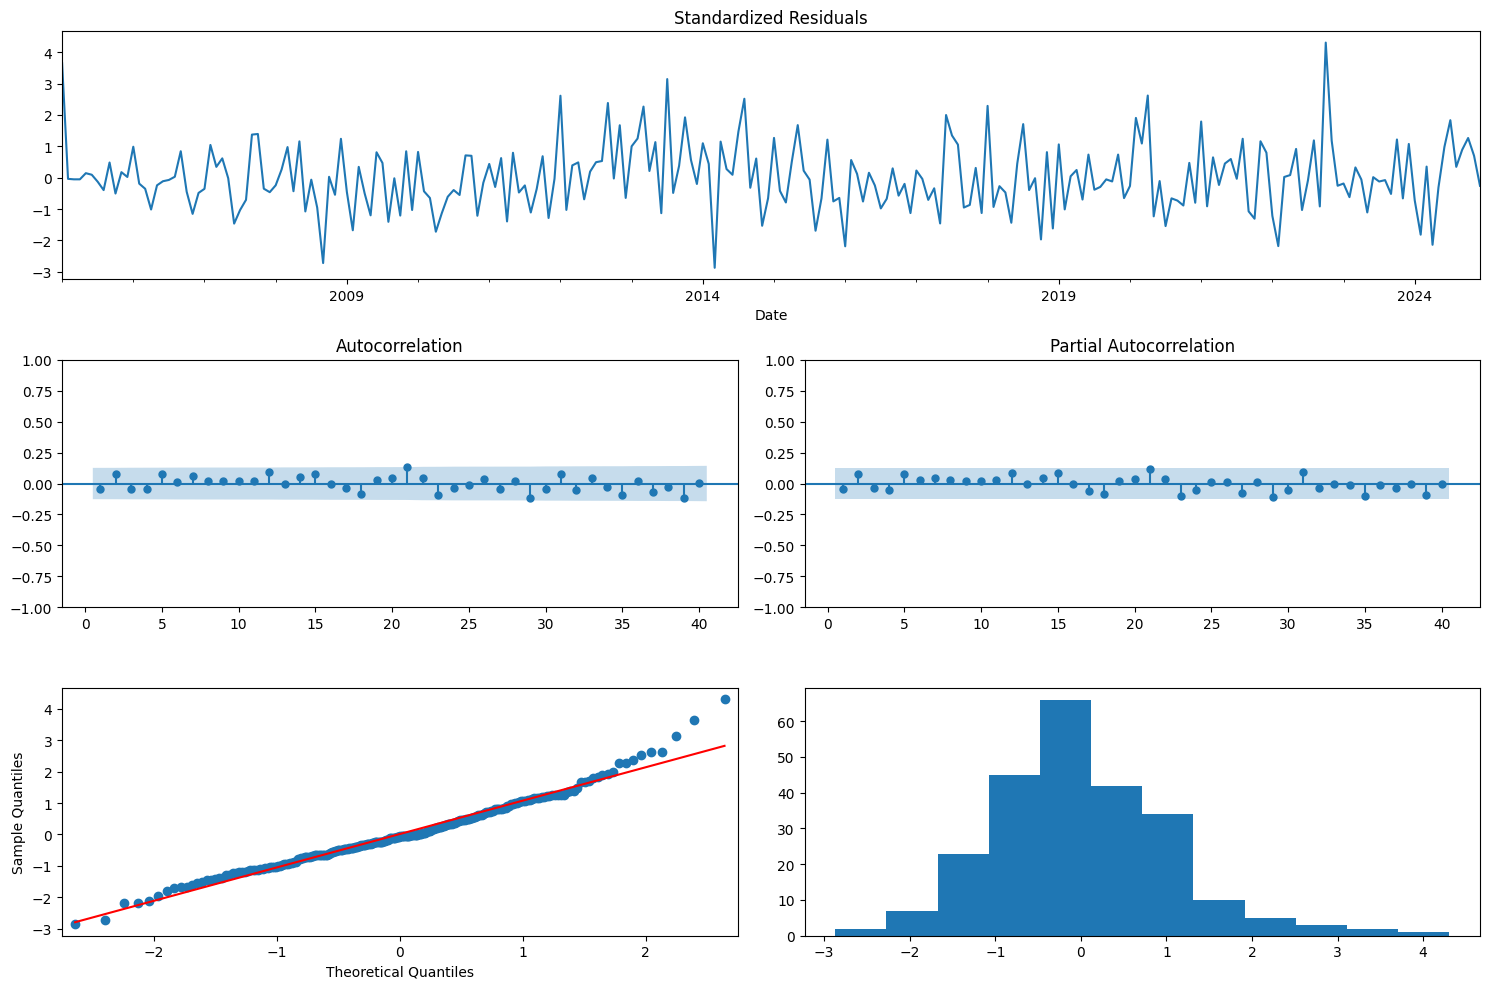


=== ARCH LM Test on Standardized Residuals ===
LM Stat: 9.0326, p-value: 0.5290
No ARCH effects present


In [1651]:
if best_garch:
    print("\n=== Best GARCH Model ===")
    # Code 2: Model equation and parameters
    p = len([p for p in best_garch.params.index if 'alpha' in p])
    q = len([p for p in best_garch.params.index if 'beta' in p])
    print(f"GARCH({p},{q}) Parameters:")
    
    equation = f"σ²(t) = {best_garch.params['omega']:.6f}"
    for i in range(1, p+1):
        equation += f" + {best_garch.params[f'alpha[{i}]']:.6f}*ε²(t-{i})"
    for i in range(1, q+1):
        equation += f" + {best_garch.params[f'beta[{i}]']:.6f}*σ²(t-{i})"
    
    print("\nGARCH Equation:")
    print(equation)
    
    # Code 1: Diagnostic plots
    garch_std_resid = best_garch.resid / best_garch.conditional_volatility
    
    fig = plt.figure(figsize=(15, 10))
    garch_std_resid.plot(ax=fig.add_subplot(3,1,1), title='Standardized Residuals')
    
    sgt.plot_acf(garch_std_resid, zero=False, lags=40, ax=fig.add_subplot(3,2,3))
    sgt.plot_pacf(garch_std_resid, zero=False, lags=40, ax=fig.add_subplot(3,2,4))
    sm.qqplot(garch_std_resid, line='s', ax=fig.add_subplot(3,2,5))
    fig.add_subplot(3,2,6).hist(garch_std_resid, bins=12)
    
    plt.tight_layout()
    plt.show()
    
    # Code 3: ARCH LM Test
    print("\n=== ARCH LM Test on Standardized Residuals ===")
    lm_stat, lm_pval, _, _ = het_arch(garch_std_resid)
    print(f"LM Stat: {lm_stat:.4f}, p-value: {lm_pval:.4f}")
    print("No ARCH effects present" if lm_pval > 0.05 else "ARCH effects detected")
    
else:
    print("No suitable GARCH model found")

In [1652]:
# 3. Forecast Combination
# ======================
if best_garch:
    # Get volatility and bounds
    volatility = best_garch.conditional_volatility
    full_predictions = fitted_values  # ARIMA predictions
    upper_bound = full_predictions + 1.96 * volatility
    lower_bound = full_predictions - 1.96 * volatility
    
    # Prepare forecast DataFrame
    forecasts = pd.DataFrame({
        'Forecast': full_predictions,
        'Upper': upper_bound,
        'Lower': lower_bound,
        'Actual': arima_df
    }).dropna()

    # Weight optimization methods
    def grid_search_weights(forecasts, precision=0.05):
        best_mape = float('inf')
        best_weights = None
        step = precision
        
        for w1 in np.arange(0, 1 + step, step):
            remaining = 1 - w1
            for w2 in np.arange(0, remaining + step, step):
                w3 = remaining - w2
                combined = w1*forecasts['Forecast'] + w2*forecasts['Upper'] + w3*forecasts['Lower']
                current_mape = mean_absolute_percentage_error(forecasts['Actual'], combined)
                if current_mape < best_mape:
                    best_mape = current_mape
                    best_weights = (w1, w2, w3)
        return best_weights, best_mape

    def random_search_weights(forecasts, iterations=5000):
        best_mape = float('inf')
        best_weights = None
        
        for _ in range(iterations):
            weights = np.random.dirichlet(np.ones(3))
            combined = weights[0]*forecasts['Forecast'] + weights[1]*forecasts['Upper'] + weights[2]*forecasts['Lower']
            current_mape = mean_absolute_percentage_error(forecasts['Actual'], combined)
            if current_mape < best_mape:
                best_mape = current_mape
                best_weights = weights
        return best_weights, best_mape

    def diff_evolution_weights(forecasts):
        X = forecasts[['Forecast', 'Upper', 'Lower']].values
        y = forecasts['Actual'].values
        
        def mape_objective(weights):
            return mean_absolute_percentage_error(y, X @ weights)
        
        constraints = NonlinearConstraint(lambda w: np.sum(w), 1, 1)
        bounds = [(0,1)]*3
        
        result = differential_evolution(
            mape_objective, 
            bounds, 
            constraints=constraints,
            popsize=15,
            mutation=(0.5, 1),
            recombination=0.7,
            seed=42
        )
        return result.x, result.fun

     # Run all optimization methods
    methods = {}
    grid_weights, grid_mape = grid_search_weights(forecasts)
    methods['Grid Search'] = grid_mape
    
    random_weights, random_mape = random_search_weights(forecasts)
    methods['Random Search'] = random_mape
    
    de_weights, de_mape = diff_evolution_weights(forecasts)
    methods['Differential Evolution'] = de_mape
    
    # Select best method
    best_method = min(methods, key=methods.get)
    best_weights = grid_weights if best_method == 'Grid Search' else random_weights if best_method == 'Random Search' else de_weights
    
    # Create combined forecast (this will be our arima_y_pred)
    arima_y_pred = (
        best_weights[0] * forecasts['Forecast'] +
        best_weights[1] * forecasts['Upper'] +
        best_weights[2] * forecasts['Lower']
    )


MODEL SELECTION RESULTS

Pure ARIMA MAPE: 5.92%
Combined ARIMA-GARCH MAPE: 5.87%

Selected Model: ARIMA-GARCH (MAPE: 5.87%)


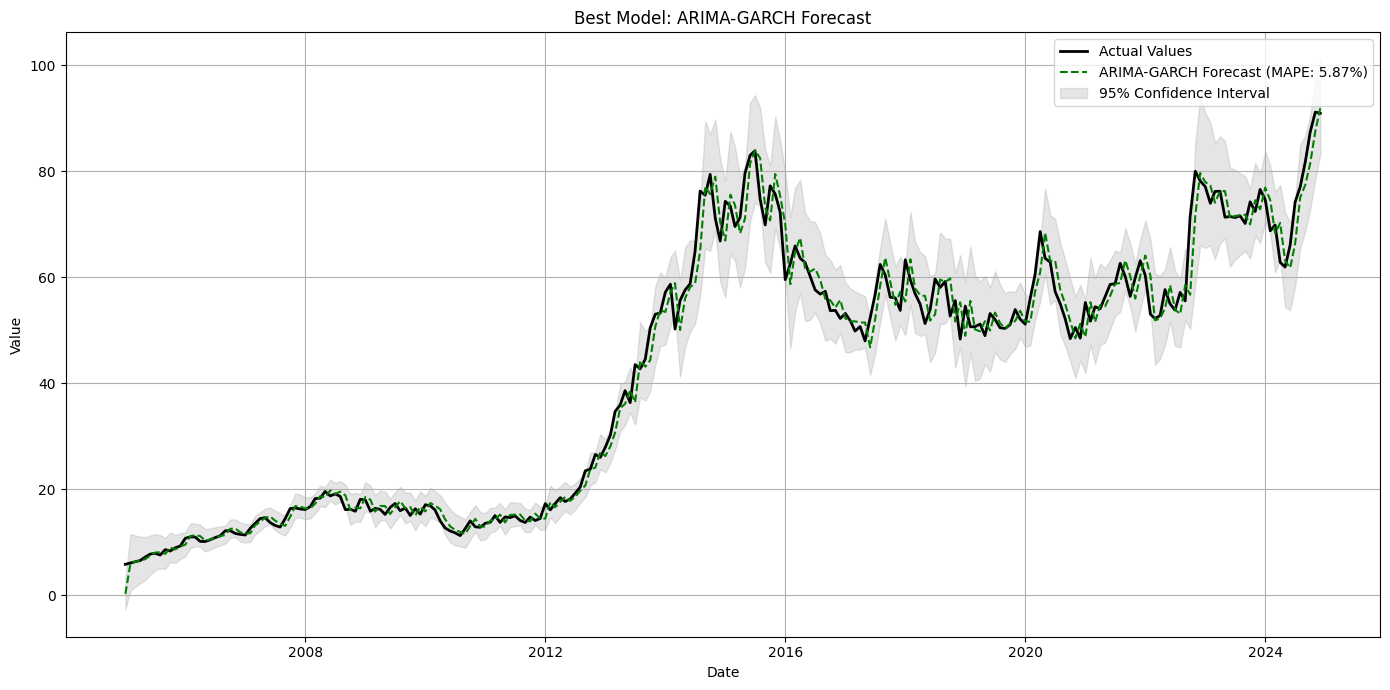


Model Equation:
Optimal Forecast = 0.1261×Point + 0.4239×Upper + 0.4500×Lower


In [1653]:

# BLOCK 1: Model Comparison and Selection
# =============================================
if best_garch:
    # Prepare forecast DataFrame
    forecasts = pd.DataFrame({
        'Forecast': full_predictions,
        'Upper': upper_bound,
        'Lower': lower_bound,
        'Actual': arima_df
    }).dropna()

    # Calculate performance metrics
    arima_mape = mean_absolute_percentage_error(forecasts['Actual'], forecasts['Forecast'])
    combined_mape = methods[best_method]
    
    # Determine best model
    if combined_mape < arima_mape:
        best_model_name = "ARIMA-GARCH"
        best_forecast = arima_y_pred
        best_mape = combined_mape
        model_equation = (
            f"Optimal Forecast = {best_weights[0]:.4f}×Point + "
            f"{best_weights[1]:.4f}×Upper + {best_weights[2]:.4f}×Lower"
        )
    else:
        best_model_name = "Pure ARIMA"
        best_forecast = forecasts['Forecast']
        best_mape = arima_mape
        model_equation = "Pure ARIMA Forecast"
    
    print("\n" + "="*60)
    print("MODEL SELECTION RESULTS")
    print("="*60)
    print(f"\nPure ARIMA MAPE: {arima_mape:.2%}")
    print(f"Combined ARIMA-GARCH MAPE: {combined_mape:.2%}")
    print(f"\nSelected Model: {best_model_name} (MAPE: {best_mape:.2%})")

# =============================================
# BLOCK 2: Plotting the Best Model
# =============================================
if best_garch:
    plt.figure(figsize=(14, 7))
    
    # Plot actual values
    plt.plot(forecasts.index, forecasts['Actual'], 
             label='Actual Values', color='black', linewidth=2)
    
    # Plot selected forecast
    plt.plot(forecasts.index, best_forecast,
             label=f'{best_model_name} Forecast (MAPE: {best_mape:.2%})', 
             color='green' if best_model_name == "ARIMA-GARCH" else 'blue',
             linestyle='--')
    
    # Add confidence interval if using ARIMA-GARCH
    if best_model_name == "ARIMA-GARCH":
        plt.fill_between(forecasts.index, forecasts['Lower'], forecasts['Upper'],
                         color='gray', alpha=0.2, label='95% Confidence Interval')
    
    plt.title(f"Best Model: {best_model_name} Forecast")
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print("\nModel Equation:")
    print(model_equation)
else:
    print("No suitable GARCH model found for residuals")

In [1654]:
# Determine final predictions
arima_mape = mean_absolute_percentage_error(forecasts['Actual'], forecasts['Forecast'])
combined_mape = methods[best_method]

if combined_mape < arima_mape:
    # Use combined forecast
    arima_y_pred = (
        best_weights[0] * forecasts['Forecast'] +
        best_weights[1] * forecasts['Upper'] +
        best_weights[2] * forecasts['Lower']
    )
else:
    # Use pure ARIMA forecast
    arima_y_pred = forecasts['Forecast']

In [1655]:
arima_y_pred

Date
2005-01-01     0.277262
2005-02-01     6.084455
2005-03-01     6.347142
2005-04-01     6.579279
2005-05-01     6.829004
                ...    
2024-08-01    75.089304
2024-09-01    77.466549
2024-10-01    81.518920
2024-11-01    87.600120
2024-12-01    91.900860
Length: 240, dtype: float64

In [1656]:
# Print Write Noice
white_noise_add = acorr_ljungbox(garch_std_resid, lags = [12], return_df=True)
white_noise_add

# Print the p-value from the Ljung-Box test
print(f"Ljung-Box test p-value: {white_noise_add['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_add['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")

Ljung-Box test p-value: 0.8162198856455611

Interpretation:
Since p-value > 0.05, we fail to reject the null hypothesis.
This suggests the residuals are independent (white noise).


# Mixed Model

In [1657]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error
from scipy.optimize import differential_evolution, NonlinearConstraint
import matplotlib.pyplot as plt

# Prepare your forecast data (replace with your actual data variables)
forecasts = pd.DataFrame({
    #'Dummy-GARCH': dummy_y_pred,          # Your dummy model forecasts
    'Additive STL-GARCH': add_y_pred,     # Your additive model forecasts
    'Multiplicative STL-GARCH': multi_y_pred,  # Your multiplicative model forecasts
    'ARIMA-GARCH': arima_y_pred,          # Your ARIMA model forecasts
    'Actual': raw_df['Close']           # Your actual values
}).dropna()  # Remove any missing values

Running optimized grid search...

Optimal Weights:
Additive STL-GARCH: 0.40
Multiplicative STL-GARCH: 0.00
ARIMA-GARCH: 0.60
Best MAPE: 0.05%


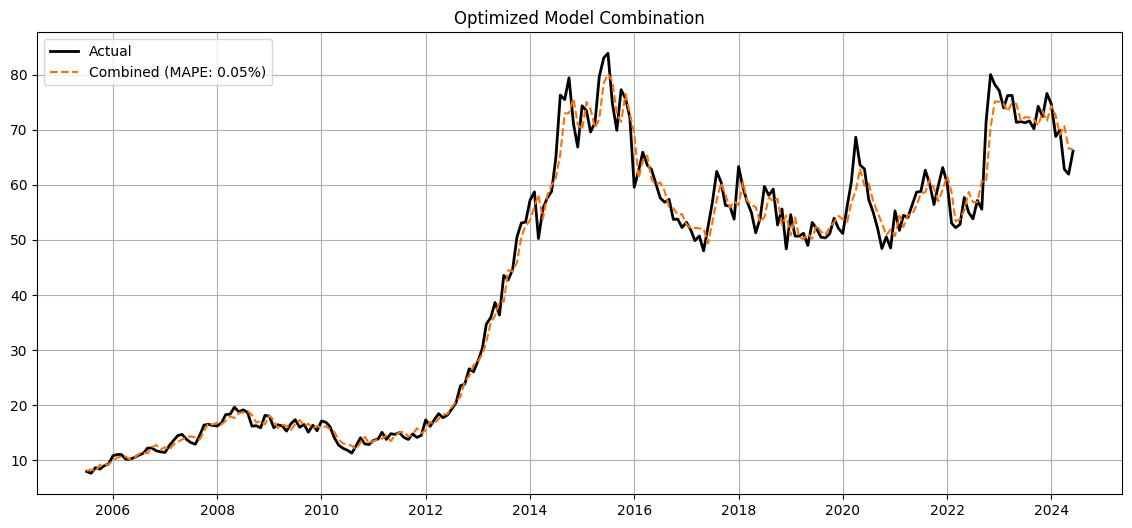

In [1658]:
#grid method
def find_optimal_weights_grid(forecasts, precision=0.1):
    """
    Optimized grid search for three-model combination weights
    Parameters:
        forecasts: DataFrame containing model forecasts and actual values
        precision: Step size for weight combinations (default 0.1)
    Returns:
        best_weights: Tuple of optimal weights (w1, w2, w3)
        best_mape: Minimum MAPE achieved
    """
    best_mape = float('inf')
    best_weights = (1/3, 1/3, 1/3)  # Default equal weights
    
    # Pre-calculate components to avoid repeated DataFrame access
    actuals = forecasts['Actual'].values
    m1 = forecasts['Additive STL-GARCH'].values
    m2 = forecasts['Multiplicative STL-GARCH'].values
    m3 = forecasts['ARIMA-GARCH'].values
    
    # Create weight combinations using meshgrid
    weights = np.arange(0, 1 + precision, precision)
    for w1 in weights:
        for w2 in weights:
            remaining = 1 - w1 - w2
            if remaining >= 0:  # Only valid weight combinations
                w3 = remaining
                
                # Vectorized calculation
                combined = w1*m1 + w2*m2 + w3*m3
                current_mape = np.mean(np.abs((actuals - combined)/actuals))
                
                if current_mape < best_mape:
                    best_mape = current_mape
                    best_weights = (w1, w2, w3)
    
    return best_weights, best_mape

# Run optimized grid search
print("Running optimized grid search...")
grid_weights, grid_mape = find_optimal_weights_grid(forecasts, precision=0.1)

# Results
print("\nOptimal Weights:")
print(f"Additive STL-GARCH: {grid_weights[0]:.2f}")
print(f"Multiplicative STL-GARCH: {grid_weights[1]:.2f}") 
print(f"ARIMA-GARCH: {grid_weights[2]:.2f}")
print(f"Best MAPE: {grid_mape:.2f}%")

# Create combined forecast
forecasts['Combined'] = (grid_weights[0] * forecasts['Additive STL-GARCH'] +
                        grid_weights[1] * forecasts['Multiplicative STL-GARCH'] +
                        grid_weights[2] * forecasts['ARIMA-GARCH'])

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(forecasts.index, forecasts['Actual'], label='Actual', color='k', linewidth=2)
plt.plot(forecasts.index, forecasts['Combined'], label=f'Combined (MAPE: {grid_mape:.2f}%)', 
         linestyle='--', color='#FF7000')
plt.title('Optimized Model Combination')
plt.legend()
plt.grid(True)
plt.show()

In [1659]:
#Random Search Method
def find_optimal_weights_random(forecasts, iterations=5000):
    """
    Optimized random search for three-model combination
    Uses Dirichlet distribution for valid weight combinations
    """
    best_mape = float('inf')
    best_weights = None
    models = ['Additive STL-GARCH', 'Multiplicative STL-GARCH', 'ARIMA-GARCH']
    
    # Pre-cache values for speed
    actuals = forecasts['Actual'].values
    model_preds = [forecasts[m].values for m in models]
    
    for _ in range(iterations):
        weights = np.random.dirichlet(np.ones(3))
        combined = sum(w*m for w, m in zip(weights, model_preds))
        current_mape = np.mean(np.abs((actuals - combined)/actuals))
        
        if current_mape < best_mape:
            best_mape = current_mape
            best_weights = weights
    
    return dict(zip(models, best_weights)), best_mape

random_weights, random_mape = find_optimal_weights_random(forecasts, iterations=5000)

In [1660]:
def optimize_weights_de(forecasts):
    """
    Differential evolution optimization for three-model combination
    """
    models = ['Additive STL-GARCH', 'Multiplicative STL-GARCH', 'ARIMA-GARCH']
    X = forecasts[models].values
    y = forecasts['Actual'].values
    
    def mape_objective(weights):
        return np.mean(np.abs((y - X @ weights)/y) )
    
    constraints = NonlinearConstraint(lambda w: np.sum(w), 1, 1)
    bounds = [(0,1)]*3
    
    result = differential_evolution(
        mape_objective,
        bounds,
        constraints=constraints,
        popsize=15,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42,
        tol=0.001
    )
    
    return dict(zip(models, result.x)), result.fun

de_weights, de_mape = optimize_weights_de(forecasts)

In [1661]:
#Best method
methods = {
    'Grid Search': grid_mape,
    'Random Search': random_mape,
    'Differential Evolution': de_mape
}

best_method = min(methods, key=methods.get)

print("\nMETHOD COMPARISON")
print("="*40)
print(f"{'Method':<25} {'MAPE':<10}")
print("-"*40)
for method, mape in methods.items():
    print(f"{method:<25} {mape:.4%}")
print("="*40)
print(f"Best method: {best_method} (MAPE: {methods[best_method]:.4%})")



METHOD COMPARISON
Method                    MAPE      
----------------------------------------
Grid Search               4.7949%
Random Search             4.7870%
Differential Evolution    4.7869%
Best method: Differential Evolution (MAPE: 4.7869%)



BEST MODEL EQUATION (Differential Evolution Weights)

Optimal Forecast = 
0.3824 × Additive STL-GARCH +
0.0367 × Multiplicative STL-GARCH +
0.5810 × ARIMA-GARCH

Achieved MAPE: 4.7869%


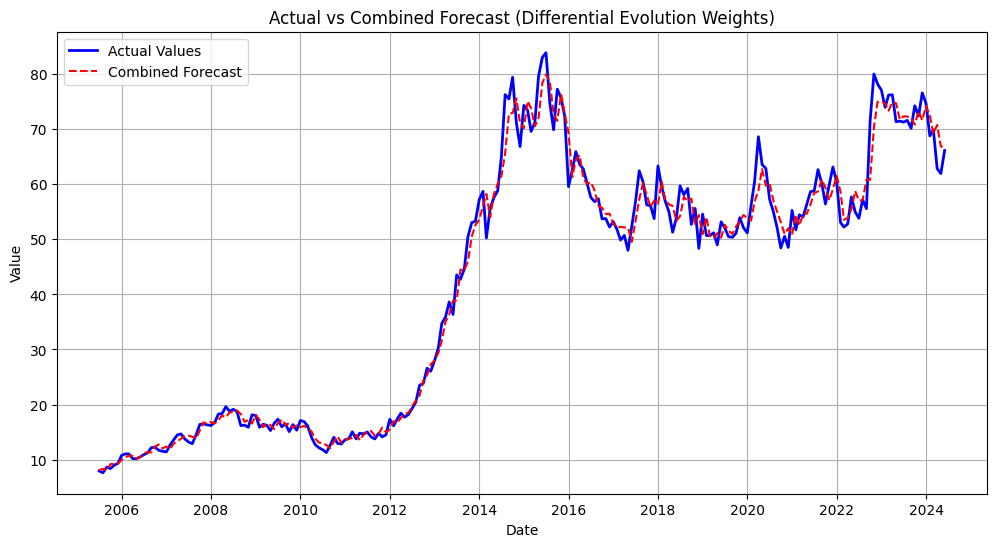

In [1662]:
# 1. Get weights from the best method
if best_method == 'Grid Search':
    best_weights = grid_weights
elif best_method == 'Random Search':
    best_weights = random_weights
else:  # Differential Evolution
    best_weights = de_weights

# 2. Create the forecast equation
equation = (
    f"Optimal Forecast = \n"
    f"{best_weights['Additive STL-GARCH']:.4f} × Additive STL-GARCH +\n" 
    f"{best_weights['Multiplicative STL-GARCH']:.4f} × Multiplicative STL-GARCH +\n"
    f"{best_weights['ARIMA-GARCH']:.4f} × ARIMA-GARCH"
)

# 3. Calculate combined forecast
combined_forecast = (
    best_weights['Additive STL-GARCH'] * forecasts['Additive STL-GARCH'] +
    best_weights['Multiplicative STL-GARCH'] * forecasts['Multiplicative STL-GARCH'] +
    best_weights['ARIMA-GARCH'] * forecasts['ARIMA-GARCH']
)

# 4. Display results
print("\n" + "="*60)
print(f"BEST MODEL EQUATION ({best_method} Weights)")
print("="*60)
print(f"\n{equation}")
print(f"\nAchieved MAPE: {methods[best_method]:.4%}")

# 5. Plot actual vs combined forecast
plt.figure(figsize=(12, 6))
plt.plot(forecasts['Actual'], label='Actual Values', color='blue', linewidth=2)
plt.plot(combined_forecast, label='Combined Forecast', linestyle='--', color='red')
plt.title(f"Actual vs Combined Forecast ({best_method} Weights)")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [1663]:
mixed_residual

Date
2005-07-01    -1.031483
2005-08-01    -0.278644
2005-09-01    -0.377521
2005-10-01     0.630848
2005-11-01    -0.574747
                ...    
2024-02-01     4.458599
2024-03-01     7.840299
2024-04-01    -5.351172
2024-05-01   -20.440483
2024-06-01   -12.491739
Freq: MS, Length: 228, dtype: float64

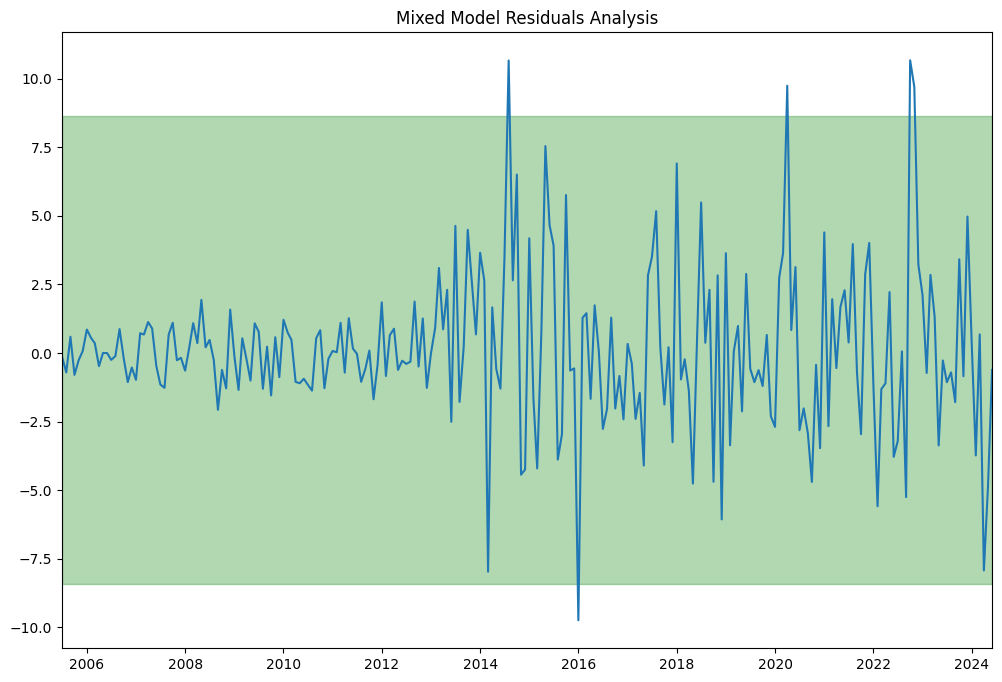

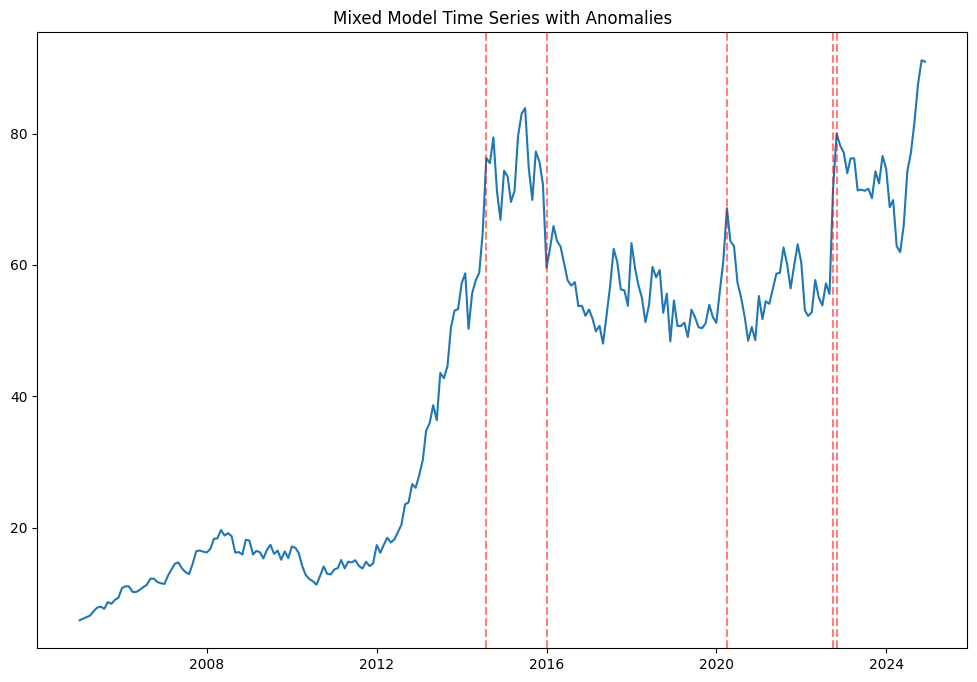

Dates of Anomalies: DatetimeIndex(['2014-08-01', '2016-01-01', '2020-04-01', '2022-10-01',
               '2022-11-01'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [1664]:
mixed_residual = forecasts['Actual'] - combined_forecast
# Calculate statistics
res.resid_mean = mixed_residual.mean()
res.resid_std = mixed_residual.std()
lower_bound = res.resid_mean - 3 * res.resid_std
upper_bound = res.resid_mean + 3 * res.resid_std

# Plot the residuals
plt.figure(figsize=(12, 8))
plt.plot(mixed_residual)
plt.fill_between(mixed_residual.index, lower_bound, upper_bound, color='green', alpha=0.3)
plt.title('Mixed Model Residuals Analysis')
plt.xlim(mixed_residual.index[0], mixed_residual.index[-1])
plt.show()

# Anomaly Detection
anomalies = mixed_residual[(mixed_residual < lower_bound) | (mixed_residual > upper_bound)]
plt.figure(figsize=(12, 8))
plt.plot(raw_df['Close'])
for i in anomalies.index:
    plt.axvline(i, color='r', linestyle='--', alpha=0.5)
plt.title('Mixed Model Time Series with Anomalies')
plt.show()

print(f'Dates of Anomalies: {anomalies.index}')

In [1665]:
# Print Write Noice
white_noise_arima = acorr_ljungbox(mixed_residual, lags = [12], return_df=True)
white_noise_arima

# Print the p-value from the Ljung-Box test
print("\n=== Ljung-Box test Results ===")
print(f"Ljung-Box test p-value: {white_noise_arima['lb_pvalue'][12]}")

# Interpret the result
p_value = white_noise_arima['lb_pvalue'][12]
if p_value > 0.05:
    print("\nInterpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests the residuals are independent (white noise).")
else:
    print("\nInterpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests the residuals are not independent (not white noise).")


=== Ljung-Box test Results ===
Ljung-Box test p-value: 0.04421361885195311

Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests the residuals are not independent (not white noise).


In [1666]:
# LM Test for ARCH Effects using het_arch
lm_stat, lm_pval, f_stat, f_pval = het_arch(mixed_residual)

# Print and interpret LM test
print("\n=== ARCH LM Test Results ===")
print(f"LM test statistic: {lm_stat:.4f}")
print(f"LM test p-value: {lm_pval}")

# Interpret LM test result
if lm_pval > 0.05:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value > 0.05, we fail to reject the null hypothesis.")
    print("This suggests there is no ARCH effect in the residuals.")
else:
    print("\nARCH LM Test Interpretation:")
    print("Since p-value < 0.05, we reject the null hypothesis.")
    print("This suggests there is ARCH effect present in the residuals.")


=== ARCH LM Test Results ===
LM test statistic: 20.5308
LM test p-value: 0.024613437423607405

ARCH LM Test Interpretation:
Since p-value < 0.05, we reject the null hypothesis.
This suggests there is ARCH effect present in the residuals.


# VAR Model

## Import Data and Data Cleaning 

In [1667]:
def parser(s):
    return datetime.strptime(s, '%Y-%m-%d')

nbi_df = pd.read_csv('/Users/lokheilee/Desktop/TSA/monthly_stock_prices_20250325副本.csv', parse_dates=[0],index_col=0, date_parser=parser)
nbi_df = nbi_df.asfreq(pd.infer_freq(nbi_df.index))
nbi_df = nbi_df.dropna(axis=1, how='any')
nbi_df

,GILD,ILMN,INVA,ACAD,ALKS,ALNY,AMGN,AMRN,ANIP,ARWR,...,ORKA,REGN,RIGL,SIGA,SNY,SRPT,UTHR,VCEL,VRTX,VTRS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-31,5.868604,4.713035,13.526764,7.07,12.670000,7.000000,43.419170,32.500000,202.679993,38.000000,...,770901.687500,7.190759,191.899994,1.318129,17.429871,15.780000,21.334999,539.200012,10.170000,13.707716
2005-02-28,6.125688,4.022374,13.511758,7.52,11.670000,7.150000,42.979675,26.799999,181.800003,40.400002,...,758215.937500,6.102159,186.399994,1.213002,18.689577,15.660000,22.715000,404.799988,11.540000,14.507263
2005-03-31,6.347311,3.929961,13.691813,6.90,10.380000,7.330000,40.607807,21.400000,144.000000,38.500000,...,634286.187500,5.103442,160.399994,1.035095,19.827528,15.000000,22.850000,332.799988,9.360000,14.630795
2005-04-30,6.579574,4.776265,13.279183,7.46,11.250000,7.780000,40.607807,19.299999,140.039993,27.500000,...,568905.937500,5.562851,171.500000,0.865275,20.778164,16.020000,23.995001,320.000000,9.530000,13.623487
2005-05-31,7.233807,5.107004,13.196659,8.73,11.600000,7.460000,43.656364,13.400000,133.199997,27.400000,...,724062.062500,6.222004,178.899994,1.107876,21.073187,14.160000,24.980000,438.399994,13.920000,13.623487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,77.075180,131.399994,19.379999,16.58,28.450001,262.690002,328.527405,0.630000,63.750000,23.830000,...,28.799999,1183.169556,13.440000,9.030000,56.259998,135.779999,363.549988,51.650002,495.890015,11.821739
2024-09-30,82.561722,130.410004,19.309999,15.38,27.990000,275.029999,317.091949,0.630000,59.660000,19.370001,...,24.510000,1049.890869,16.180000,6.750000,57.630001,124.889999,358.350006,42.250000,465.079987,11.361787
2024-10-31,87.465797,144.139999,19.559999,14.59,25.700001,266.589996,315.074524,0.580000,57.250000,19.230000,...,28.000000,837.124268,13.630000,7.220000,52.880001,126.000000,373.970001,44.040001,475.980011,11.352001


In [1668]:
# Initialize a clean DataFrame with the same index
nbi_clean_df = pd.DataFrame(index=nbi_df.index)

for column in nbi_df.columns:
    stock_series = nbi_df[column].copy()
    
    # Normalization (Z-score)
    avg = stock_series.mean()
    dev = stock_series.std()
    stock_series = (stock_series - avg) / dev
    
    # First Difference (remove trend)
    stock_series = stock_series.diff().dropna()
    
    # Remove Volatility (annual scaling)
    annual_volatility = stock_series.groupby(stock_series.index.year).std()
    stock_annual_vol = stock_series.index.map(lambda d: annual_volatility.loc[d.year])
    stock_series = stock_series / stock_annual_vol
    
    # Remove Seasonality (monthly adjustment)
    month_avg = stock_series.groupby(stock_series.index.month).mean()
    stock_month_avg = stock_series.index.map(lambda d: month_avg.loc[d.month])
    stock_series = stock_series - stock_month_avg
    
    # Store the processed series in nbi_clean_df (original column name)
    nbi_clean_df[column] = stock_series

nbi_clean_df = nbi_clean_df.dropna()
nbi_clean_df

,GILD,ILMN,INVA,ACAD,ALKS,ALNY,AMGN,AMRN,ANIP,ARWR,...,ORKA,REGN,RIGL,SIGA,SNY,SRPT,UTHR,VCEL,VRTX,VTRS
Date,,,,,,,,,,,,,,,,,,,,,
2005-02-28,0.855781,-0.997643,-0.177323,0.210847,-0.673352,0.147733,0.124212,-1.868331,-0.986989,0.702468,...,0.117528,-0.561663,-0.190937,-1.005264,1.632824,-0.004876,0.604602,-1.792321,0.713463,0.731485
2005-03-31,0.155977,-0.256623,0.118185,-0.387698,-0.630752,0.271107,-0.658274,-1.686598,-1.462003,-0.461548,...,-0.894470,-0.835111,-0.657677,-1.042644,0.435429,-0.272245,0.241195,-1.073239,-1.215198,0.243965
2005-04-30,0.693612,1.150347,-0.466846,0.731662,0.648798,0.467805,-0.032031,-0.714009,-0.366207,-2.407559,...,-0.629177,0.205613,0.364771,-1.297166,0.501128,0.493348,0.441053,-0.064640,-0.249902,-0.761904
2005-05-31,1.642891,0.421794,-0.103550,1.259624,0.221006,-0.373777,0.696313,-1.710892,-0.100244,0.263000,...,1.768341,-0.051053,0.518571,1.572935,-0.108380,-1.019333,0.227351,1.772507,1.794374,0.198061
2005-06-30,1.121728,0.667785,-0.394954,-0.134908,0.725818,-0.419759,-0.508009,-0.481174,-0.024711,-0.004240,...,0.704331,1.253979,0.305036,-1.171196,-1.434870,-0.349588,-0.414336,0.858546,0.976956,2.256228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.625487,0.962269,0.732728,-0.912903,0.609675,0.718276,0.082965,-0.462223,-0.176446,-0.918757,...,2.164886,0.685033,0.684112,-0.352105,1.984660,-0.484489,2.153043,0.497761,-0.137921,0.275434
2024-09-30,0.836487,-0.071652,0.042735,-0.658582,-0.159416,0.167430,-0.574298,0.165474,-0.960167,-1.138123,...,-0.502797,-1.302195,0.464124,-1.507055,0.305755,-0.983217,-0.170871,-1.278321,-0.944988,-0.365423
2024-10-31,0.743399,1.273850,0.310431,-0.244868,-0.772207,0.132590,-0.199855,-0.189832,-0.462777,0.088836,...,1.023889,-2.151180,-0.072740,0.231173,-1.559666,0.334727,0.431734,0.313666,0.528323,-0.076566


In [1669]:
column_names = nbi_clean_df.columns.tolist()
print("Columns with complete data (no missing values):")
print(column_names)

Columns with complete data (no missing values):
['GILD', 'ILMN', 'INVA', 'ACAD', 'ALKS', 'ALNY', 'AMGN', 'AMRN', 'ANIP', 'ARWR', 'AVDL', 'AZN', 'BCRX', 'BIIB', 'BMRN', 'CYTK', 'DVAX', 'EXEL', 'EYPT', 'GERN', 'HALO', 'INCY', 'INSM', 'IONS', 'LGND', 'LXRX', 'MNKD', 'NBIX', 'NVAX', 'ORKA', 'REGN', 'RIGL', 'SIGA', 'SNY', 'SRPT', 'UTHR', 'VCEL', 'VRTX', 'VTRS']


## VAR Model

In [1670]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

# =================================================================
# 0. Configuration
# =================================================================
VAR_MAXLAGS = 4               # Lag order for VAR model
TEST_SIZE = 12                # Months for backtesting
FORECAST_STEPS = 12           # Months for future forecasting
PLOT_COLS = 3                 # Number of top stocks to visualize
SIG_LEVEL = 0.05              # Significance threshold for variable selection

# =================================================================
# 1. Data Preparation
# =================================================================
print("Preparing data...")
scaler = StandardScaler()
nbi_scaled = pd.DataFrame(
    scaler.fit_transform(nbi_clean_df),
    columns=nbi_clean_df.columns,
    index=nbi_clean_df.index
)

# Split into training and testing
train = nbi_scaled.iloc[:-TEST_SIZE]
test = nbi_scaled.iloc[-TEST_SIZE:]

# =================================================================
# 2. VAR Model Fitting
# =================================================================
print("\nFitting VAR model...")
model = VAR(train)
var_results = model.fit(maxlags=VAR_MAXLAGS, ic='aic')

# Display summary
print("\nVAR Model Summary:")
print("="*60)
print(var_results.summary())

Preparing data...

Fitting VAR model...

VAR Model Summary:
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 01, Apr, 2025
Time:                     23:37:03
--------------------------------------------------------------------
No. of Equations:         39.0000    BIC:                    73.6194
Nobs:                     223.000    HQIC:                   17.8337
Log likelihood:          -3995.02    FPE:                 0.00139160
AIC:                     -19.9326    Det(Omega_mle):     1.30570e-12
--------------------------------------------------------------------
Results for equation GILD
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.027371         0.063547            0.431           0.667
L1.GILD         0.060565         0.144921            0.418           0.676
L1.ILMN        -0.260908 

In [1671]:
# 3. Model Diagnostics
# =================================================================
print("\nRunning model diagnostics...")
residuals = pd.DataFrame(var_results.resid, columns=train.columns)

# Ljung-Box test for autocorrelation
print("\nResidual Autocorrelation Test (Ljung-Box):")
for col in residuals.columns[:3]:  # First 3 only for display
    lb_test = acorr_ljungbox(residuals[col], lags=[4], return_df=True)
    print(f"{col}: Q-stat = {lb_test['lb_stat'].iloc[0]:.2f}, p-value = {lb_test['lb_pvalue'].iloc[0]:.4f}")


Running model diagnostics...

Residual Autocorrelation Test (Ljung-Box):
GILD: Q-stat = 1.71, p-value = 0.7886
ILMN: Q-stat = 3.62, p-value = 0.4592
INVA: Q-stat = 5.12, p-value = 0.2752



Selecting significant variables...
No variables significant at p ≤ 0.05. Using all variables.

Calculating MAPE table...

MAPE Results (%):
Variable  Train_MAPE  Test_MAPE  Combined_MAPE
    GILD        1.53      12.94           2.11
    ILMN        7.25       3.14           7.04
    INVA        1.58       6.35           1.82
    ACAD        1.24       1.45           1.25
    ALKS        1.42       3.58           1.53
    ALNY        1.39      20.72           2.38
    AMGN        5.58       3.42           5.47
    AMRN        3.49       2.95           3.46
    ANIP        3.87       4.41           3.89
    ARWR        4.45       2.66           4.36
    AVDL        1.48       1.64           1.49
     AZN        1.13       1.74           1.16
    BCRX        7.78       2.07           7.49
    BIIB        8.11       1.06           7.75
    BMRN        1.56       4.16           1.69
    CYTK        1.87       2.60           1.91
    DVAX       40.18      15.33          38.91
    EXEL     

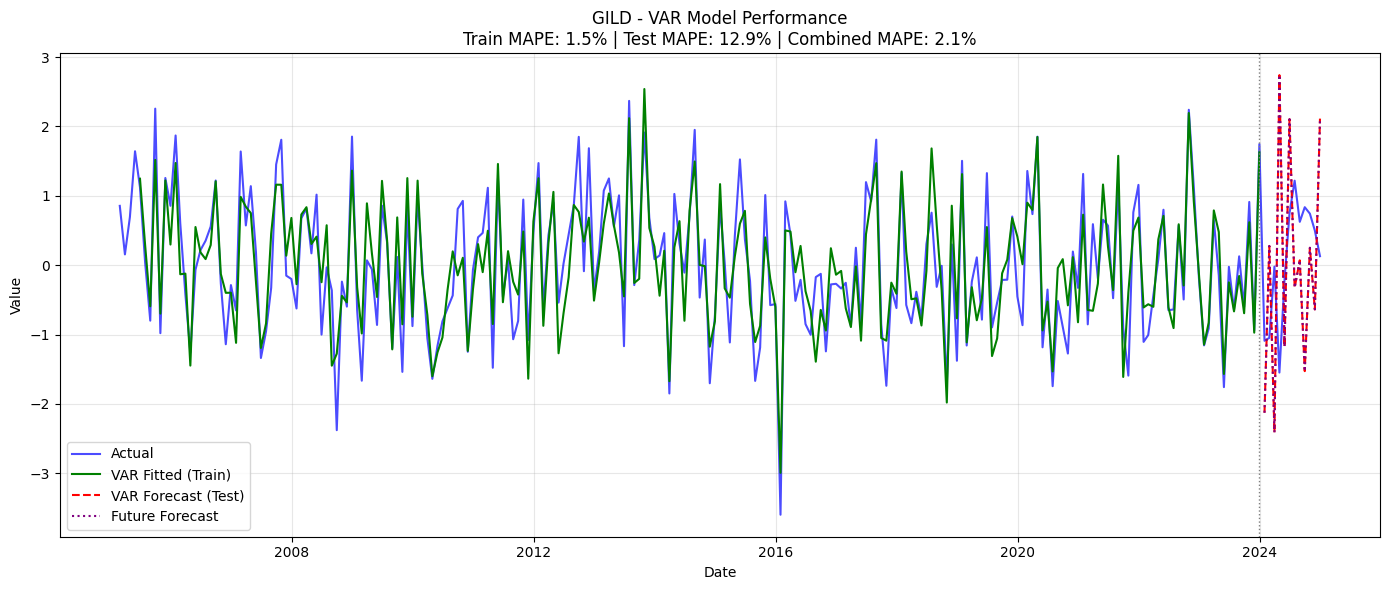

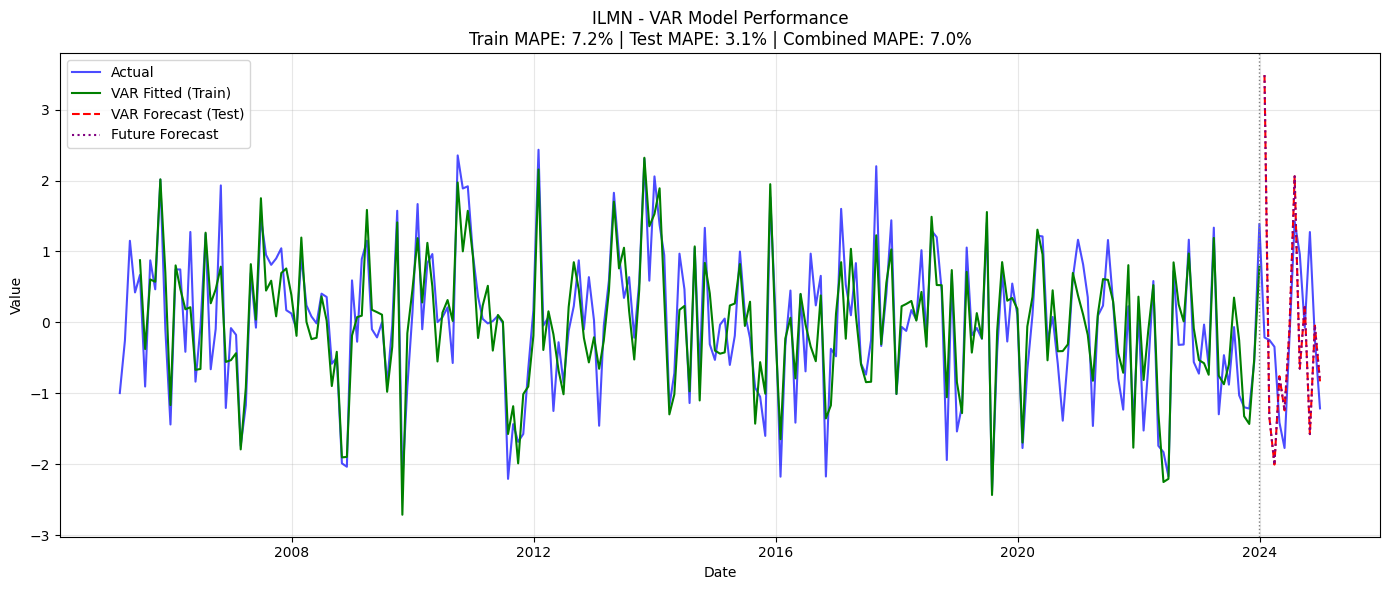

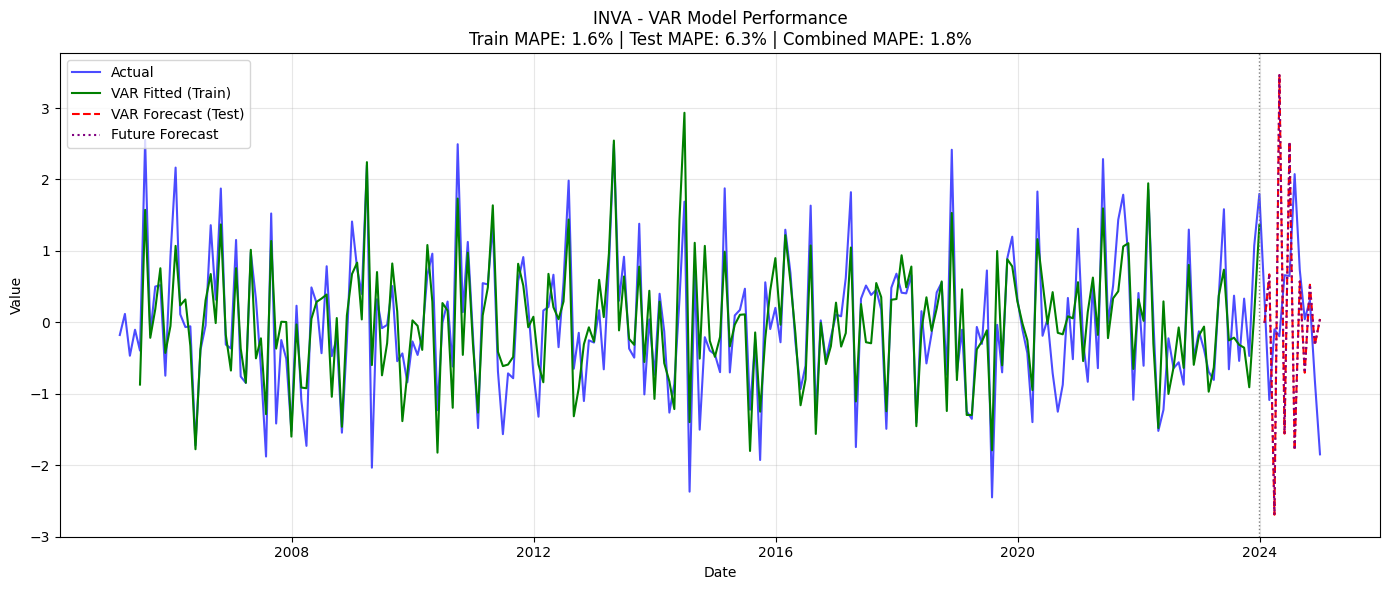

In [1672]:
# 4. Significant Variable Selection
# =================================================================
print("\nSelecting significant variables...")
pvalues = var_results.pvalues.max(axis=1)
significant_vars = [var for var in pvalues[pvalues <= SIG_LEVEL].index 
                   if var in train.columns and var != 'const']

if len(significant_vars) == 0:
    print(f"No variables significant at p ≤ {SIG_LEVEL}. Using all variables.")
    significant_vars = train.columns.tolist()
elif len(significant_vars) < len(train.columns):
    print(f"Keeping significant variables (p ≤ {SIG_LEVEL}): {significant_vars}")
else:
    print("All variables are statistically significant")

# =================================================================
# 5. Backtesting with MAPE Table
# =================================================================
def calculate_mape_table(results, train, test, original_df, scaler, vars_to_use):
    """Calculate MAPE and return results in DataFrame format."""
    if len(vars_to_use) == 0:
        raise ValueError("No variables selected for forecasting")
    
    # Training fitted values
    train_fitted = results.fittedvalues[vars_to_use]
    train_forecast = pd.DataFrame(
        scaler.inverse_transform(train_fitted),
        columns=vars_to_use,
        index=train.index[results.k_ar:]
    )
    
    # Testing forecasts
    test_forecast_values = results.forecast(
        train[vars_to_use].values[-results.k_ar:], 
        steps=TEST_SIZE
    )
    test_forecast = pd.DataFrame(
        scaler.inverse_transform(test_forecast_values),
        columns=vars_to_use,
        index=test.index
    )
    
    # Initialize results dictionary
    mape_results = {
        'Variable': [],
        'Train_MAPE': [],
        'Test_MAPE': [],
        'Combined_MAPE': []
    }
    
    for col in vars_to_use:
        # Training MAPE
        train_true = original_df.loc[train_forecast.index, col].replace(0, 1e-10)
        train_pred = train_forecast[col]
        train_mape = mean_absolute_percentage_error(train_true, train_pred)
        
        # Testing MAPE
        test_true = original_df.loc[test_forecast.index, col].replace(0, 1e-10)
        test_pred = test_forecast[col]
        test_mape = mean_absolute_percentage_error(test_true, test_pred)
        
        # Combined MAPE (weighted average)
        n_train = len(train_true)
        n_test = len(test_true)
        combined_mape = (train_mape * n_train + test_mape * n_test) / (n_train + n_test)
        
        # Store results
        mape_results['Variable'].append(col)
        mape_results['Train_MAPE'].append(train_mape)
        mape_results['Test_MAPE'].append(test_mape)
        mape_results['Combined_MAPE'].append(combined_mape)
    
    # Create DataFrame
    mape_df = pd.DataFrame(mape_results)
    mape_df = mape_df.round(2)
    
    return mape_df, pd.concat([train_forecast, test_forecast])

print("\nCalculating MAPE table...")
mape_df, full_forecast = calculate_mape_table(
    var_results, train, test, nbi_clean_df, scaler, significant_vars
)

# Display the MAPE table
print("\nMAPE Results (%):")
print("="*60)
print(mape_df.to_string(index=False))
print("="*60)

# =================================================================
# 6. Future Forecasting
# =================================================================
print(f"\nGenerating {FORECAST_STEPS}-month forecasts...")
future_forecast_values = var_results.forecast(
    train[significant_vars].values[-var_results.k_ar:],
    steps=FORECAST_STEPS
)
future_forecast = pd.DataFrame(
    scaler.inverse_transform(future_forecast_values),
    columns=significant_vars,
    index=pd.date_range(
        start=train.index[-1] + pd.offsets.MonthBegin(1),
        periods=FORECAST_STEPS,
        freq='M'
    )
)

print("\nFuture Forecasts:")
print(future_forecast.head().round(2))

# =================================================================
# 7. Enhanced Visualization with Complete MAPE Display
# =================================================================
def plot_var_results(col, actual_df, forecast_df, future_df, train_end, mape_df):
    """Enhanced visualization showing all three MAPE values"""
    plt.figure(figsize=(14, 6))
    
    # Get all MAPE values from the dataframe
    row = mape_df[mape_df['Variable'] == col].iloc[0]
    train_mape = row['Train_MAPE']
    test_mape = row['Test_MAPE']
    combined_mape = row['Combined_MAPE']
    
    # Plot actual values
    plt.plot(actual_df.index, actual_df[col], 
             label='Actual', color='blue', alpha=0.7)
    
    # Plot training period fits
    train_fit = forecast_df[forecast_df.index <= train_end]
    plt.plot(train_fit.index, train_fit[col],
             label='VAR Fitted (Train)', color='green', linestyle='-')
    
    # Plot testing period forecasts
    test_fcst = forecast_df[forecast_df.index > train_end]
    plt.plot(test_fcst.index, test_fcst[col],
             label='VAR Forecast (Test)', color='red', linestyle='--')
    
    # Plot future forecasts
    plt.plot(future_df.index, future_df[col],
             label='Future Forecast', color='purple', linestyle=':')
    
    # Add formatting
    plt.axvline(x=train_end, color='gray', linestyle=':', linewidth=1)
    plt.title(
        f"{col} - VAR Model Performance\n"
        f"Train MAPE: {train_mape:.1f}% | "
        f"Test MAPE: {test_mape:.1f}% | "
        f"Combined MAPE: {combined_mape:.1f}%"
    )
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nGenerating visualizations...")
# Plot first PLOT_COLS variables in their original order
for col in mape_df['Variable'].iloc[:PLOT_COLS]:
    plot_var_results(
        col=col,
        actual_df=nbi_clean_df,
        forecast_df=full_forecast,
        future_df=future_forecast,
        train_end=train.index[-1],
        mape_df=mape_df
    )

In [1673]:
import scipy.stats as stats
def display_var_results(results, vars_per_section=3, sig_only=True):
    """
    Display VAR results with:
    - Coefficient estimates
    - Standard errors
    - z-statistics
    - p-values
    - Significance stars
    Only shows significant results (p < 0.05) if sig_only=True
    """
    # Create a DataFrame with all results
    coeffs = []
    for eq in results.names:
        for var in results.params.index:
            coef = results.params.loc[var, eq]
            std_err = results.bse.loc[var, eq]
            z = coef / std_err
            p = 2 * (1 - stats.norm.cdf(abs(z)))  # Two-tailed p-value
            
            # Skip if not significant and sig_only is True
            if sig_only and p >= 0.05:
                continue
                
            coeffs.append({
                'Equation': eq,
                'Variable': var,
                'Coefficient': coef,
                'Std.Error': std_err,
                'z-value': z,
                'p-value': p,
                'Significance': get_sig_stars(p)
            })
    
    df = pd.DataFrame(coeffs)
    
    if len(df) == 0:
        print("\nNo significant results found (p < 0.05)")
        return
        
    # Split display by equations
    equations = df['Equation'].unique()
    for i in range(0, len(equations), vars_per_section):
        current_eqs = equations[i:i+vars_per_section]
        print(f"\n{'='*80}")
        print(f"SIGNIFICANT VAR RESULTS (p < 0.05) FOR EQUATIONS: {', '.join(current_eqs)}")
        print(f"{'='*80}\n")
        
        # Display each equation's results
        for eq in current_eqs:
            eq_df = df[df['Equation'] == eq].drop('Equation', axis=1)
            if len(eq_df) > 0:  # Only display if there are significant results
                print(f"\nEquation: {eq}")
                print("-"*60)
                print(eq_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
                print("\n" + "-"*60)
        
        print(f"\n{'='*80}")

def get_sig_stars(p):
    """Return significance stars"""
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    return ''

# Usage example:
var_model = VAR(nbi_scaled)
results = var_model.fit(maxlags=4)
display_var_results(results)


SIGNIFICANT VAR RESULTS (p < 0.05) FOR EQUATIONS: GILD, ILMN, INVA


Equation: GILD
------------------------------------------------------------
Variable  Coefficient  Std.Error  z-value  p-value Significance
 L1.AMGN      -0.2792     0.1337  -2.0891   0.0367            *
 L1.ANIP      -0.2587     0.1087  -2.3806   0.0173            *
 L1.UTHR       0.3171     0.1155   2.7457   0.0060           **
 L2.ARWR       0.2809     0.1218   2.3056   0.0211            *
 L2.BMRN       0.2611     0.1248   2.0926   0.0364            *
 L2.DVAX      -0.2212     0.1088  -2.0333   0.0420            *
 L2.MNKD       0.2638     0.1137   2.3196   0.0204            *
 L2.ORKA      -0.2193     0.1089  -2.0149   0.0439            *
  L2.SNY       0.2191     0.1064   2.0584   0.0396            *
 L2.SRPT      -0.3227     0.1049  -3.0748   0.0021           **
 L2.VRTX      -0.2463     0.1029  -2.3934   0.0167            *
 L2.VTRS       0.2862     0.1003   2.8527   0.0043           **
 L3.DVAX       0.1923 

In [1674]:
#EQ
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
import scipy.stats as stats

def generate_significant_var_equations(data, lags=4, first_n=3):
    """
    Generate VAR model equations with ONLY significant terms (p < 0.05)
    
    Parameters:
    - data: DataFrame of time series data
    - lags: Number of lags for VAR model
    - first_n: Number of equations to generate
    
    Returns:
    - Dictionary containing:
        - equations: formatted equation strings
        - fit_metrics: dictionary of fit statistics
    """
    # Fit VAR model
    model = VAR(data)
    results = model.fit(maxlags=lags)
    
    # Get p-values matrix
    pvalues = results.pvalues
    
    # Initialize storage
    equations = {}
    fit_metrics = {
        'nobs': results.nobs,
        'aic': results.aic,
        'bic': results.bic,
        'fpe': results.fpe
    }
    
    # Get first n equations
    for eq in results.names[:first_n]:
        eq_str = f"{eq}(t) = "
        terms = []
        
        # Add intercept if significant
        if 'const' in results.params.index:
            p_const = pvalues.loc['const', eq]
            if p_const < 0.05:
                const = results.params.loc['const', eq]
                terms.append(f"{const:.4f}")
        
        # Add significant lagged terms
        for lag in range(1, results.k_ar + 1):
            for var in results.names:
                term = f'L{lag}.{var}'
                try:
                    p_val = pvalues.loc[term, eq]
                    if p_val < 0.05:
                        coef = results.params.loc[term, eq]
                        terms.append(f"{coef:.4f} * {var}(t-{lag})")
                except KeyError:
                    continue
        
        # Handle case where no terms are significant
        if not terms:
            eq_str += "No significant predictors"
        else:
            eq_str += " + ".join(terms)
            
        equations[eq] = eq_str
    
    return {'equations': equations, 'fit_metrics': fit_metrics}

# Example usage:
result_dict = generate_significant_var_equations(nbi_clean_df, lags=4, first_n=3)
equations = result_dict['equations']
fit_metrics = result_dict['fit_metrics']

# Print the equations with model fit information
print("VAR Model Equations (Only p < 0.05 Terms)")
print("="*80)
print(f"Overall Model Fit Metrics:")
print(f"Number of observations: {fit_metrics['nobs']}")
print(f"AIC: {fit_metrics['aic']:.2f}")
print(f"BIC: {fit_metrics['bic']:.2f}")
print(f"FPE: {fit_metrics['fpe']:.2f}")
print("="*80)

for eq_name, eq_str in equations.items():
    print(f"\n{eq_name} equation:")
    print(eq_str)
print("="*80)

VAR Model Equations (Only p < 0.05 Terms)
Overall Model Fit Metrics:
Number of observations: 235
AIC: -18.45
BIC: 71.69
FPE: 0.00

GILD equation:
GILD(t) = -0.2930 * AMGN(t-1) + -0.2616 * ANIP(t-1) + 0.3181 * UTHR(t-1) + 0.2794 * ARWR(t-2) + 0.2710 * BMRN(t-2) + -0.2223 * DVAX(t-2) + 0.2664 * MNKD(t-2) + -0.2198 * ORKA(t-2) + 0.2347 * SNY(t-2) + -0.3124 * SRPT(t-2) + -0.2463 * VRTX(t-2) + 0.2860 * VTRS(t-2) + 0.1933 * DVAX(t-3) + -0.3092 * HALO(t-3) + 0.2579 * IONS(t-3) + 0.2418 * NBIX(t-3) + -0.2452 * ANIP(t-4) + 0.2604 * LGND(t-4) + -0.3886 * REGN(t-4)

ILMN equation:
ILMN(t) = -0.3290 * ALKS(t-1) + 0.2452 * EXEL(t-1) + 0.2473 * GERN(t-1) + -0.2821 * LXRX(t-1) + 0.3095 * ACAD(t-2) + -0.3487 * ORKA(t-2) + -0.2884 * SIGA(t-2) + 0.3046 * UTHR(t-2) + 0.2918 * VTRS(t-2) + -0.2197 * ORKA(t-3) + 0.2870 * NBIX(t-4) + 0.2967 * ORKA(t-4)

INVA equation:
INVA(t) = -0.2710 * ORKA(t-1) + -0.2601 * VCEL(t-1) + 0.3513 * BCRX(t-2) + 0.3517 * UTHR(t-2) + 0.2568 * VRTX(t-2) + -0.2699 * GILD(t-4) + -0.

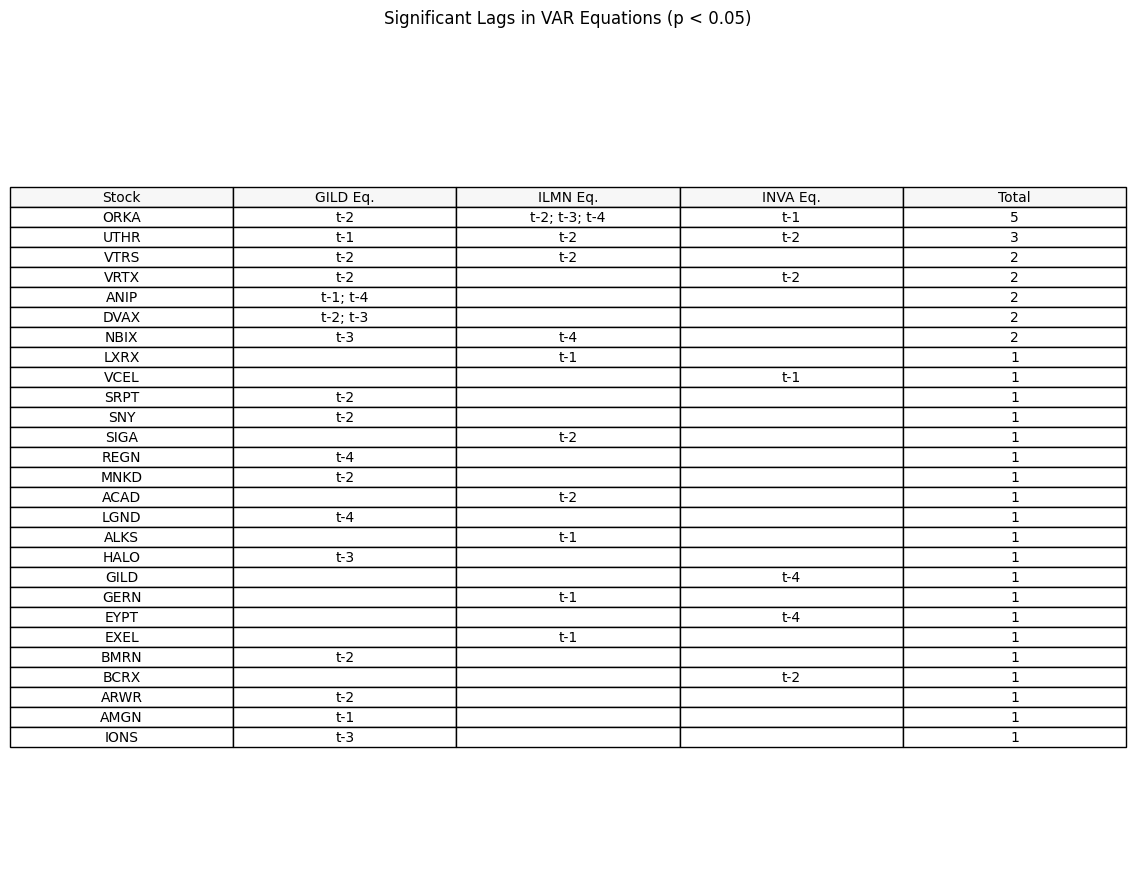

Stock GILD Eq.      ILMN Eq. INVA Eq.  Total
 ORKA      t-2 t-2; t-3; t-4      t-1      5
 UTHR      t-1           t-2      t-2      3
 VTRS      t-2           t-2               2
 VRTX      t-2                    t-2      2
 ANIP t-1; t-4                             2
 DVAX t-2; t-3                             2
 NBIX      t-3           t-4               2
 LXRX                    t-1               1
 VCEL                             t-1      1
 SRPT      t-2                             1
  SNY      t-2                             1
 SIGA                    t-2               1
 REGN      t-4                             1
 MNKD      t-2                             1
 ACAD                    t-2               1
 LGND      t-4                             1
 ALKS                    t-1               1
 HALO      t-3                             1
 GILD                             t-4      1
 GERN                    t-1               1
 EYPT                             t-4      1
 EXEL     

In [1675]:
# Count plot
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

def create_significance_table(data, lags=4, first_n=3):
    """
    Create table showing ONLY stocks with significant relationships
    
    Parameters:
    - data: DataFrame of time series data
    - lags: Number of lags in VAR model
    - first_n: Number of equations to analyze
    
    Returns:
    - DataFrame showing significant lags by stock and equation
    - Saves visualization as PNG
    """
    # Fit VAR model
    model = VAR(data)
    results = model.fit(maxlags=lags)
    
    # Get p-values matrix
    pvalues = results.pvalues
    
    # Initialize table
    table_data = []
    
    # Check all stocks
    for stock in sorted(results.names):
        row = {'Stock': stock}
        total = 0
        has_significant = False
        
        # Check each equation
        for i, eq in enumerate(results.names[:first_n]):
            lags_found = []
            
            # Check all lags for this stock
            for lag in range(1, lags + 1):
                term = f'L{lag}.{stock}'
                try:
                    if pvalues.loc[term, eq] < 0.05:
                        lags_found.append(f't-{lag}')
                        total += 1
                        has_significant = True
                except KeyError:
                    continue
            
            # Only include if significant
            row[f'{eq} Eq.'] = '; '.join(lags_found) if lags_found else ''
        
        # Only add to table if has at least one significant relationship
        if has_significant:
            row['Total'] = total
            table_data.append(row)
    
    # Create DataFrame
    if not table_data:
        print("No significant relationships found (p < 0.05)")
        return None
    
    df = pd.DataFrame(table_data)
    df = df.sort_values('Total', ascending=False)
    
    # Visualize table
    plt.figure(figsize=(12, max(6, len(df)*0.4)))  # Dynamic height
    plt.axis('off')
    plt.title('Significant Lags in VAR Equations (p < 0.05)', pad=20)
    
    table = plt.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center',
        colColours=['#f7f7f7']*len(df.columns)
    )
    
    # Adjust table style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    # Save and show
    plt.savefig('significant_stocks_table.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df

# Example usage:
significance_table = create_significance_table(nbi_clean_df, lags=4, first_n=3)
if significance_table is not None:
    print(significance_table.to_string(index=False))

## VAR Residual Analysis


Running full dataset anomaly detection...

ANOMALY DETECTION REPORT (Full Dataset)

GILD:
Total anomalies detected: 0
Anomaly threshold: ±1.44

ILMN:
Total anomalies detected: 0
Anomaly threshold: ±1.39

INVA:
Total anomalies detected: 0
Anomaly threshold: ±1.63

Generating anomaly plots...


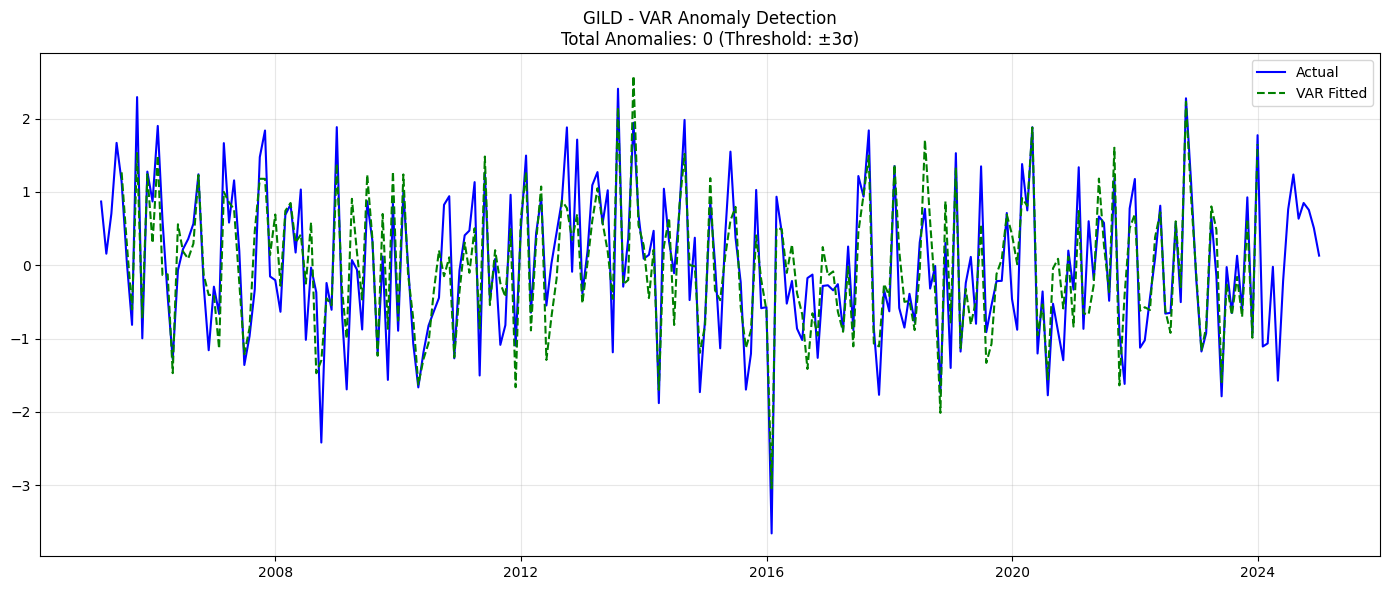

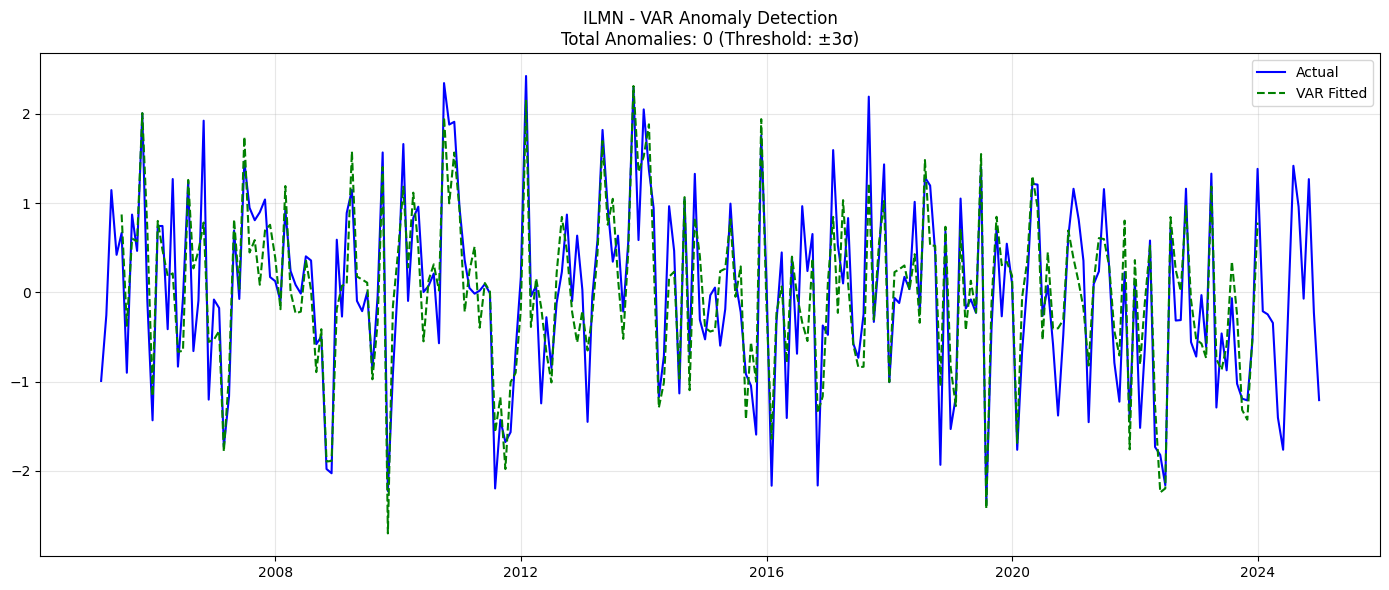

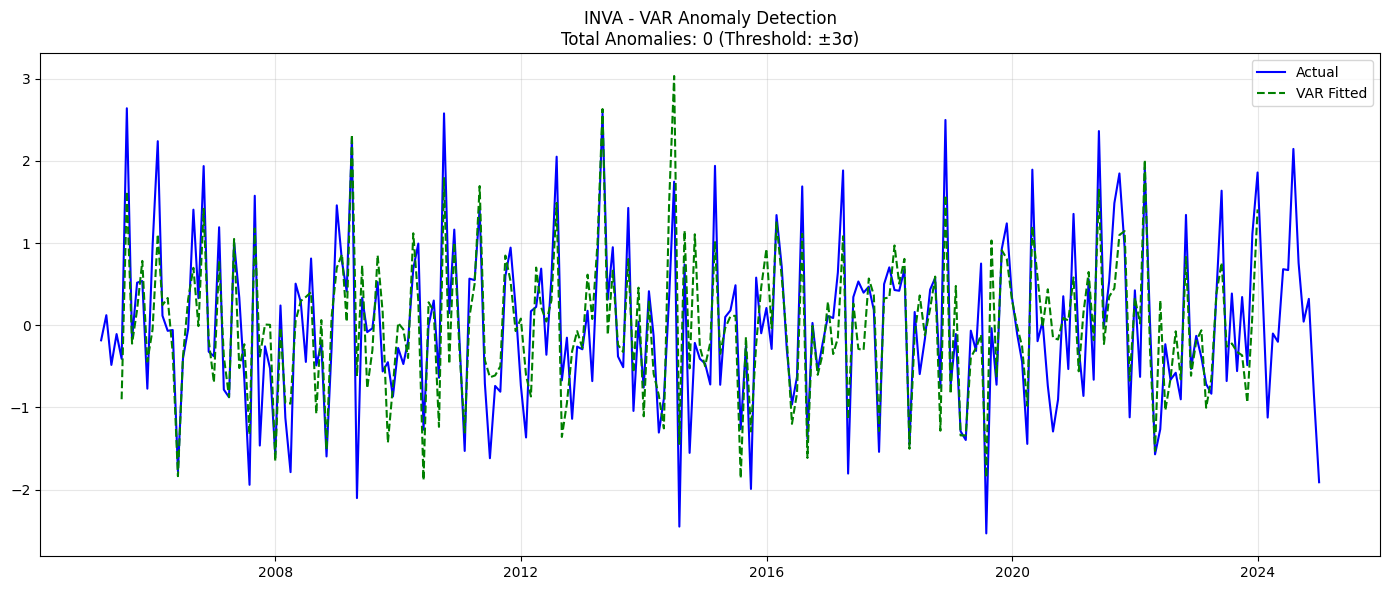

In [1676]:
# 8. Anomaly Detection (Full Dataset)
# =================================================================
def detect_anomalies_full_dataset(original_df, var_model, significant_vars, first_n_cols=3):
    """
    Detect anomalies in the full dataset using VAR model residuals
    
    Parameters:
    - original_df: Original normalized dataframe
    - var_model: Fitted VAR model object
    - significant_vars: List of significant variables from VAR
    - first_n_cols: Number of columns to show detailed results for
    
    Returns:
    - Dictionary with full anomaly results
    - Prints detailed report for first_n_cols
    """
    # Get fitted values for full training period
    fitted_values = var_model.fittedvalues[significant_vars]
    
    # Calculate residuals
    residuals = original_df.loc[fitted_values.index, significant_vars] - fitted_values
    
    # Detect anomalies (3-sigma method)
    anomaly_results = {}
    for col in significant_vars:
        std = residuals[col].std()
        lower_bound = -3 * std
        upper_bound = 3 * std
        
        col_residuals = residuals[col]
        anomalies = col_residuals[(col_residuals < lower_bound) | (col_residuals > upper_bound)]
        pct_deviation = ((original_df.loc[anomalies.index, col] - fitted_values.loc[anomalies.index, col]) / 
                         fitted_values.loc[anomalies.index, col]) * 100
        
        anomaly_results[col] = {
            'residuals': col_residuals,
            'bounds': (lower_bound, upper_bound),
            'anomalies': anomalies,
            'pct_deviation': pct_deviation
        }
    
    # Print detailed report for first N columns
    print("\n" + "="*100)
    print("ANOMALY DETECTION REPORT (Full Dataset)")
    print("="*100)
    
    for col in significant_vars[:first_n_cols]:
        anomalies = anomaly_results[col]['anomalies']
        print(f"\n{col}:")
        print(f"Total anomalies detected: {len(anomalies)}")
        print(f"Anomaly threshold: ±{3*residuals[col].std():.2f}")
        
        if len(anomalies) > 0:
            print("\nTop 5 Anomalies:")
            print("-"*80)
            print("Date         | Residual | % Deviation")
            print("-"*80)
            sorted_anoms = anomalies.abs().sort_values(ascending=False).head(5)
            for date in sorted_anoms.index:
                res = anomalies[date]
                pct = anomaly_results[col]['pct_deviation'][date]
                print(f"{date.date()} | {res:8.2f} | {pct:10.1f}%")
        print("="*100)
    
    return anomaly_results

def plot_anomalies(col, original_df, fitted_df, anomaly_results):
    """Plot time series with anomalies marked"""
    plt.figure(figsize=(14, 6))
    
    # Plot actual vs fitted
    plt.plot(original_df.index, original_df[col], label='Actual', color='blue')
    plt.plot(fitted_df.index, fitted_df[col], label='VAR Fitted', linestyle='--', color='green')
    
    # Mark anomalies
    anomalies = anomaly_results[col]['anomalies']
    if len(anomalies) > 0:
        plt.scatter(anomalies.index, original_df.loc[anomalies.index, col],
                   color='red', s=80, label='Anomalies')
    
    # Formatting
    plt.title(f"{col} - VAR Anomaly Detection\n"
              f"Total Anomalies: {len(anomalies)} (Threshold: ±3σ)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run anomaly detection
print("\nRunning full dataset anomaly detection...")
anomaly_results = detect_anomalies_full_dataset(
    original_df=nbi_scaled,
    var_model=var_results,
    significant_vars=significant_vars,
    first_n_cols=3
)

# Generate plots for first 3 columns
print("\nGenerating anomaly plots...")
for col in significant_vars[:3]:
    plot_anomalies(
        col=col,
        original_df=nbi_scaled,
        fitted_df=var_results.fittedvalues,
        anomaly_results=anomaly_results
    )

In [1677]:
from statsmodels.stats.diagnostic import het_arch

def arch_lm_test_first3(var_results):
    """
    Perform ARCH LM test on first 3 variables in VAR results
    
    Parameters:
    - var_results: Fitted VAR model results object
    
    Returns:
    - DataFrame with test results for first 3 variables
    """
    # Get first 3 variable names
    first3_vars = var_results.names[:3]
    
    results = []
    for var in first3_vars:
        # Get residuals for current variable
        residuals = var_results.resid[var]
        
        # Perform ARCH LM test
        lm_stat, lm_pval, _, _ = het_arch(residuals)
        
        # Determine interpretation
        interpretation = "No ARCH effects" if lm_pval > 0.05 else "ARCH effects present"
        
        results.append({
            'Variable': var,
            'LM Statistic': lm_stat,
            'P-value': lm_pval,
            'Interpretation': interpretation
        })
    
    # Create and return DataFrame
    return pd.DataFrame(results)

# Usage:
arch_results = arch_lm_test_first3(var_results)
print(arch_results)

  Variable  LM Statistic   P-value   Interpretation
0     GILD      6.622287  0.760557  No ARCH effects
1     ILMN     10.230957  0.420470  No ARCH effects
2     INVA     14.447846  0.153526  No ARCH effects


In [1678]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test_first3(var_results, lags=12):
    """
    Perform Ljung-Box test on first 3 variables in VAR results
    
    Parameters:
    - var_results: Fitted VAR model results object
    - lags: Number of lags to test (default 12)
    
    Returns:
    - DataFrame with test results for first 3 variables
    """
    # Get first 3 variable names
    first3_vars = var_results.names[:3]
    
    results = []
    for var in first3_vars:
        # Get residuals for current variable
        residuals = var_results.resid[var]
        
        # Perform Ljung-Box test
        lb_test = acorr_ljungbox(residuals, lags=[lags], return_df=True)
        
        # Extract results
        lb_stat = lb_test['lb_stat'].iloc[0]
        lb_pval = lb_test['lb_pvalue'].iloc[0]
        
        # Determine interpretation
        interpretation = "No autocorrelation" if lb_pval > 0.05 else "Autocorrelation present"
        
        results.append({
            'Variable': var,
            'LB Statistic': lb_stat,
            'P-value': lb_pval,
            'Lags Tested': lags,
            'Interpretation': interpretation
        })
    
    # Create and return DataFrame
    return pd.DataFrame(results)

# Usage:
lb_results = ljung_box_test_first3(var_results, lags=12)
print(lb_results)

  Variable  LB Statistic   P-value  Lags Tested      Interpretation
0     GILD      8.080057  0.778843           12  No autocorrelation
1     ILMN      9.167595  0.688553           12  No autocorrelation
2     INVA     11.597229  0.478544           12  No autocorrelation
